# Naive Bayes para Predicción de Obesidad (IMC > 30)

Curso: Minería de Datos en la Practica (UNAM)

Autor: Thanos Drossos

Este notebook implementa un clasificador Naive Bayes para predecir si una persona es obesa (IMC > 30) utilizando el conjunto de datos de salud. El análisis progresa desde la identificación de factores individuales hasta la puntuación general de pacientes, traduciendo datos de salud en conocimientos accionables sobre factores asociados con la obesidad.

## Importar bibliotecas y cargar datos

Cargaremos los datos, analizaremos las características básicas y prepararemos el conjunto de datos para el análisis de Naive Bayes.

Tamaño del dataset: 1076 filas, 500 columnas

Columnas en el dataset:
['ï»¿folio', 'id_dep', 'colonia', 'ciudad', 'id_estado', 'cp', 'nac_dia', 'nac_mes', 'nac_anio', 'id_puesto', 'id_sexo', 'id_edociv', 'id_gestud', 'num_fam', 'id_encuest', 'Apuesto', 'Aestado', 'Aedad', 'AAedad', 'dich_obes', 'edad_obes', 'dich_diab', 'edad_diab', 'dich_pre', 'edad_pre', 'dich_hiper', 'edad_hiper', 'dich_cardi', 'edad_cardi', 'dich_reti', 'edad_reti', 'dich_renal', 'edad_renal', 'dich_coles', 'edad_coles', 'dich_trigl', 'edad_trigl', 'dich_cmama', 'edad_cmama', 'dich_cpros', 'edad_cpros', 'dich_colon', 'edad_colon', 'dich_cotro', 'edad_cotro', 'dich_pulmo', 'edad_pulmo', 'dich_neuro', 'edad_neuro', 'dich_asma', 'edad_asma', 'nr_dich1', 'nr_dich2', 'salud_act', 'salud1', 'salud5', 'salud10', 'salud20', 'salud30', 'estres_act', 'estres1', 'estres5', 'estres10', 'estres20', 'estres30', 'condi_act', 'condi1', 'condi5', 'condi10', 'condi20', 'condi30', 'peso_act', 'peso1', 'peso5', 'peso10', 'peso20', 'pe

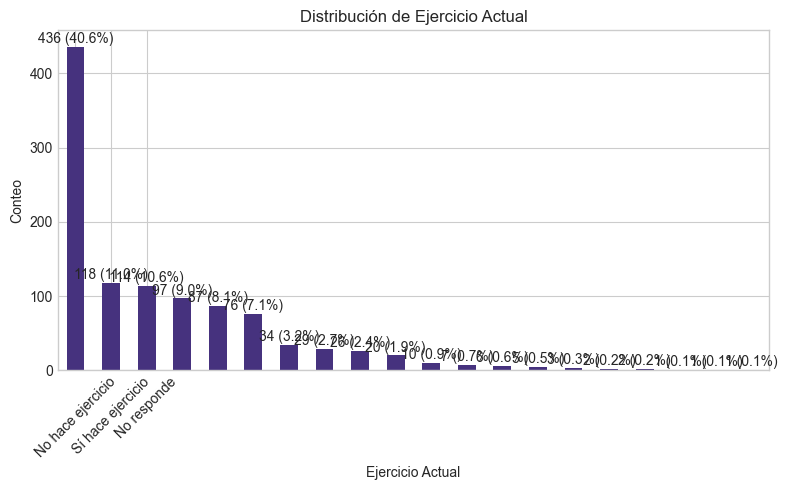

In [197]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Configurar visualización
plt.style.use('seaborn-v0_8-whitegrid')  # Usando un estilo seaborn válido
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar el conjunto de datos
file_path = 'CSV 14UNI1_CAQ.csv'
df = pd.read_csv(file_path, encoding='latin1')

# Mostrar información básica
print(f"Tamaño del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
print("\nColumnas en el dataset:")
print(df.columns.tolist())

# Mostrar la distribución de la variable objetivo ejer_act
ejercicio_counts = df['ejer_act'].value_counts()
print("\nDistribución de ejercicio actual (ejer_act):")
print(ejercicio_counts)

# Valores únicos y su significado
# 0: No hace ejercicio
# 1: Sí hace ejercicio
# 2: No responde

# Visualizar la distribución
plt.figure(figsize=(8, 5))
ax = ejercicio_counts.plot(kind='bar')
plt.title('Distribución de Ejercicio Actual')
plt.xlabel('Ejercicio Actual')
plt.ylabel('Conteo')
plt.xticks(ticks=[0, 1, 2], labels=['No hace ejercicio', 'Sí hace ejercicio', 'No responde'], rotation=45)
for i, count in enumerate(ejercicio_counts):
    ax.text(i, count + 5, f'{count} ({count/sum(ejercicio_counts):.1%})', ha='center')
plt.tight_layout()
plt.show()

## Preparación de los datos y creación de variable objetivo de obesidad

Prepararemos los datos para su análisis, creando la variable de obesidad basada en el Índice de Masa Corporal (IMC > 30), calculado con el peso y la estatura. Luego seleccionaremos las características relevantes para nuestro modelo.

Calculando IMC y clasificación de obesidad...

Distribución de obesidad (IMC > 30):
obesidad
0    859
1    217
Name: count, dtype: int64
Prevalencia de obesidad: 20.17%


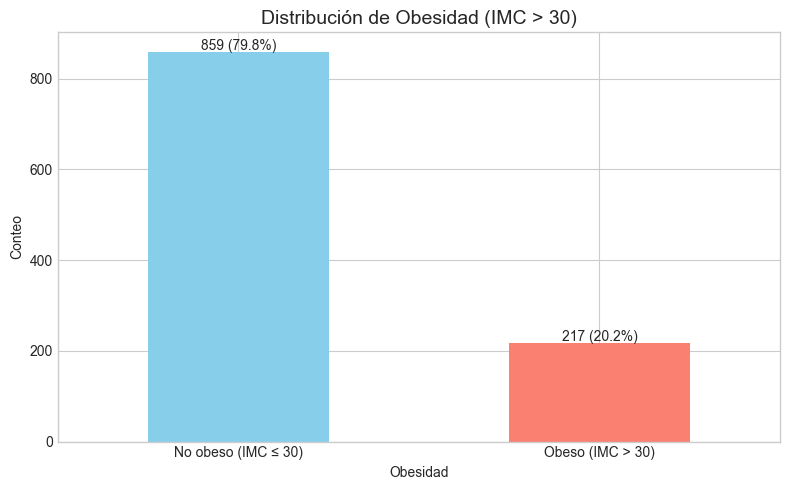

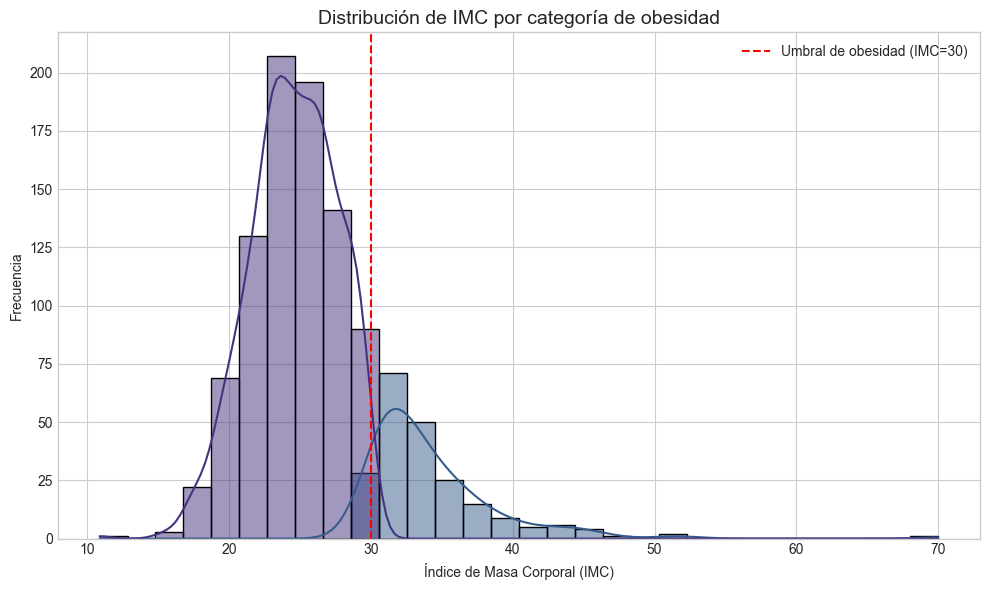


Tipos de datos:
obesidad       int32
id_fleb        int64
tom_muest      int64
peso_acc       int64
peso_tpo       int64
               ...  
id_gestud     object
otro_act_e    object
otro30_es     object
colonia       object
Aestado       object
Length: 503, dtype: object

Columnas con valores nulos:
hij10_sobr    1076
hij10_peso    1076
hij10_edad    1076
tio19_diab    1076
leje_otroe    1076
              ... 
colonia          1
id_sobrsoc       1
ejer_act         1
num_ami          1
num_hij          1
Length: 402, dtype: int64

Número de variables predictoras seleccionadas: 464
Primeras 10 variables: ['ï»¿folio', 'id_sexo', 'id_edociv', 'id_gestud', 'num_fam', 'Aedad', 'AAedad', 'edad_obes', 'dich_diab', 'edad_diab']


In [198]:
df_clean = df.copy()

# Calcular IMC (kg/m²) y crear variable de obesidad
print("Calculando IMC y clasificación de obesidad...")
# La estatura ya esta en metros
df_clean['estatura_m'] = df_clean['estatura']

# Calcular IMC: peso (kg) / estatura (m)²
df_clean['imc_calculado'] = df_clean['peso'] / (df_clean['estatura_m'] ** 2)

# Crear variable objetivo: obesidad (1 si IMC > 30, 0 en caso contrario)
df_clean['obesidad'] = (df_clean['imc_calculado'] > 30).astype(int)

# Mostrar distribución de la variable objetivo
obesidad_counts = df_clean['obesidad'].value_counts()
print("\nDistribución de obesidad (IMC > 30):")
print(obesidad_counts)
print(f"Prevalencia de obesidad: {obesidad_counts[1] / len(df_clean):.2%}")

# Visualizar distribución de obesidad
plt.figure(figsize=(8, 5))
ax = obesidad_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribución de Obesidad (IMC > 30)', fontsize=14)
plt.xlabel('Obesidad')
plt.ylabel('Conteo')
plt.xticks(ticks=[0, 1], labels=['No obeso (IMC ≤ 30)', 'Obeso (IMC > 30)'], rotation=0)
for i, count in enumerate(obesidad_counts):
    ax.text(i, count + 5, f'{count} ({count/sum(obesidad_counts):.1%})', ha='center')
plt.tight_layout()
plt.show()

# Verificar la relación entre IMC y obesidad
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='imc_calculado', hue='obesidad', bins=30, kde=True)
plt.axvline(x=30, color='red', linestyle='--', label='Umbral de obesidad (IMC=30)')
plt.title('Distribución de IMC por categoría de obesidad', fontsize=14)
plt.xlabel('Índice de Masa Corporal (IMC)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

# Verificar tipos de datos
print("\nTipos de datos:")
print(df_clean.dtypes.sort_values())

# Verificar valores nulos
missing_values = df_clean.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]
print("\nColumnas con valores nulos:")
print(missing_values if len(missing_values) > 0 else "No hay valores nulos")

# Selección de variables potencialmente predictivas
# Excluimos ID, códigos, nombres y variables que no tienen relación lógica con obesidad
variables_excluidas = [
    'folio', 'id_dep', 'colonia', 'ciudad', 'id_estado', 'cp',
    'nac_dia', 'nac_mes', 'nac_anio', 'id_puesto', 'id_encuest',
    'Apuesto', 'Aestado', 'tom_muest', 'id_fleb', 'id_med', 'id_medp',
    'id_medt', 'dia', 'mes', 'anio', 'leje_otroe', 'mcam_otroe', 'otro_act_e',
    'otro1_es', 'otro5_es', 'otro10_es', 'otro20_es', 'otro30_es',
    'id_sobrsoc', 'min_proc', 'grad', 'pos', 'rep', 'dia_proc', 'mes_proc', 'hora_proc',
    'mas_otrosp',
    # También excluimos variables relacionadas con la obesidad/IMC para evitar fugas de datos
    'imc_calculado', 'estatura_m', 'imc', 'imc_nmin', 'imc_nmax', 'imc_obes', 'AIMC',
    'dich_obes', 'nr_imcobes', 'nr_porobes', 'por_obes'
]

# Seleccionar variables potencialmente predictivas
variables_predictoras = [col for col in df_clean.columns if col not in variables_excluidas and col != 'obesidad']
print(f"\nNúmero de variables predictoras seleccionadas: {len(variables_predictoras)}")
print(f"Primeras 10 variables: {variables_predictoras[:10]}")

## Función de cálculo de estadísticas para Naive Bayes

Implementaremos funciones para calcular las estadísticas necesarias para el clasificador Naive Bayes.

In [199]:
# Función para calcular estadísticas Naive Bayes para un par característica-valor
def calculate_stats(feature, value, description, subcategory, is_threshold=False):
    if is_threshold:
        condition = df_clean[feature] >= value
        value_display = f"≥ {value}"
        response = value_display
    else:
        condition = df_clean[feature] == value
        value_display = value
        response = str(value)
    
    # Contar instancias
    N_X = condition.sum()
    N_CX = ((df_clean['obesidad'] == 1) & condition).sum()
    N_not_CX = N_X - N_CX
    
    # Calcular probabilidades
    P_C_given_X = N_CX / N_X if N_X > 0 else 0
    prior_probability = df_clean['obesidad'].mean()
    
    # Calcular Epsilon
    if N_X > 0 and prior_probability < 1 and prior_probability > 0:
        epsilon = (N_X * (P_C_given_X - prior_probability)) / (N_X * prior_probability * (1 - prior_probability))**0.5
    else:
        epsilon = 0
    
    # Calcular Score
    positive_instances = df_clean['obesidad'].sum()
    negative_instances = len(df_clean) - positive_instances
    P_X_given_C = N_CX / positive_instances if positive_instances > 0 else 0
    P_X_given_not_C = N_not_CX / negative_instances if negative_instances > 0 else 0
    
    if P_X_given_not_C > 0 and P_X_given_C > 0:
        score_X = math.log(P_X_given_C / P_X_given_not_C)
    else:
        score_X = 0
    
    s_r = math.log(prior_probability / (1 - prior_probability)) if prior_probability < 1 and prior_probability > 0 else 0
    score = score_X + s_r
    
    return {
        'Subcategoría': subcategory,
        'Descripción': description,
        'Respuesta': response,
        'N(CX)': N_CX,
        'N(X)': N_X,
        'P(C|X)': round(P_C_given_X, 2),
        'P(C)': round(prior_probability, 2),
        'Epsilon': round(epsilon, 2),
        'Score': round(score, 2),
        'N(C)': positive_instances,
        'N': len(df_clean),
        'N(-C)': negative_instances,
        'N(-CX)': N_not_CX,
        'Feature': feature,
        'Value': value,
        'Is_Threshold': is_threshold
    }

## Análisis uniperspectivo: factores individuales

Analizaremos cada característica individualmente para identificar los factores más influyentes en la predicción de ejercicio actual.

In [200]:
# Diccionario para categorizar variables
categories = {
    'Demografía': ['id_sexo', 'id_edociv', 'id_gestud', 'num_fam', 'Aedad', 'AAedad', 'edad_obes'],
    'Identificación': ['folio', 'id_dep', 'colonia', 'ciudad', 'id_estado', 'cp', 'nac_dia', 'nac_mes', 'nac_anio', 'id_puesto', 'id_encuest', 'Apuesto', 'Aestado'],
    'Salud': ['dich_obes', 'dich_diab', 'edad_diab', 'dich_pre', 'edad_pre', 'dich_hiper', 
              'edad_hiper', 'dich_cardi', 'edad_cardi', 'dich_reti', 'edad_reti', 'dich_renal', 
              'edad_renal', 'dich_coles', 'edad_coles', 'dich_trigl', 'edad_trigl', 'dich_cmama',
              'edad_cmama', 'dich_cpros', 'edad_cpros', 'dich_colon', 'edad_colon', 'dich_cotro',
              'edad_cotro', 'dich_pulmo', 'edad_pulmo', 'dich_neuro', 'edad_neuro', 'dich_asma', 
              'edad_asma', 'nr_dich1', 'nr_dich2'],
    'Percepción': ['salud_act', 'salud1', 'salud5', 'salud10', 'salud20', 'salud30',
                   'estres_act', 'estres1', 'estres5', 'estres10', 'estres20', 'estres30',
                   'condi_act', 'condi1', 'condi5', 'condi10', 'condi20', 'condi30', 'arelacion'],
    'Peso': ['peso_act', 'peso1', 'peso5', 'peso10', 'peso20', 'peso30', 'aes_peso', 'nr_peso',
             'peso_tpo', 'estatura', 'peso_acc', 'peso_ehoy', 'peso_edes'],
    'Familia': ['num_her', 'her1_edad', 'her1_sobr', 'her1_diab', 'her1_vivo',
                'her2_edad', 'her2_sobr', 'her2_diab', 'her2_vivo',
                'her3_edad', 'her3_sobr', 'her3_diab', 'her3_vivo',
                'her4_edad', 'her4_sobr', 'her4_diab', 'her4_vivo',
                'her5_edad', 'her5_sobr', 'her5_diab', 'her5_vivo',
                'her6_edad', 'her6_sobr', 'her6_diab', 'her6_vivo',
                'her7_edad', 'her7_sobr', 'her7_diab', 'her7_vivo',
                'her8_edad', 'her8_sobr', 'her8_diab', 'her8_vivo',
                'her9_edad', 'her9_sobr', 'her9_diab', 'her9_vivo',
                'her10_edad', 'her10_sobr', 'her10_diab', 'her10_vivo',
                'num_tio', 'tio1_edad', 'tio1_sobr', 'tio1_diab', 'tio1_vivo',
                'tio2_edad', 'tio2_sobr', 'tio2_diab', 'tio2_vivo',
                'tio3_edad', 'tio3_sobr', 'tio3_diab', 'tio3_vivo',
                'tio4_edad', 'tio4_sobr', 'tio4_diab', 'tio4_vivo',
                'tio5_edad', 'tio5_sobr', 'tio5_diab', 'tio5_vivo',
                'tio6_edad', 'tio6_sobr', 'tio6_diab', 'tio6_vivo',
                'tio7_edad', 'tio7_sobr', 'tio7_diab', 'tio7_vivo',
                'tio8_edad', 'tio8_sobr', 'tio8_diab', 'tio8_vivo',
                'tio9_edad', 'tio9_sobr', 'tio9_diab', 'tio9_vivo',
                'tio10_edad', 'tio10_sobr', 'tio10_diab', 'tio10_vivo',
                'tio11_edad', 'tio11_sobr', 'tio11_diab', 'tio11_vivo',
                'tio12_edad', 'tio12_sobr', 'tio12_diab', 'tio12_vivo',
                'tio13_edad', 'tio13_sobr', 'tio13_diab', 'tio13_vivo',
                'tio14_edad', 'tio14_sobr', 'tio14_diab', 'tio14_vivo',
                'tio15_edad', 'tio15_sobr', 'tio15_diab', 'tio15_vivo',
                'tio16_edad', 'tio16_sobr', 'tio16_diab', 'tio16_vivo',
                'tio17_edad', 'tio17_sobr', 'tio17_diab', 'tio17_vivo',
                'tio18_edad', 'tio18_sobr', 'tio18_diab', 'tio18_vivo',
                'tio19_edad', 'tio19_sobr', 'tio19_diab', 'tio19_vivo',
                'tio20_edad', 'tio20_sobr', 'tio20_diab', 'tio20_vivo',
                'num_hij', 'hij1_edad', 'hij1_sobr', 'hij1_diab', 'hij1_peso',
                'hij2_edad', 'hij2_sobr', 'hij2_diab', 'hij2_peso',
                'hij3_edad', 'hij3_sobr', 'hij3_diab', 'hij3_peso',
                'hij4_edad', 'hij4_sobr', 'hij4_diab', 'hij4_peso',
                'hij5_edad', 'hij5_sobr', 'hij5_diab', 'hij5_peso',
                'hij6_edad', 'hij6_sobr', 'hij6_diab', 'hij6_peso',
                'hij7_edad', 'hij7_sobr', 'hij7_diab', 'hij7_peso',
                'hij8_edad', 'hij8_sobr', 'hij8_diab', 'hij8_peso',
                'hij9_edad', 'hij9_sobr', 'hij9_diab', 'hij9_peso',
                'hij10_edad', 'hij10_sobr', 'hij10_diab', 'hij10_peso',
                'mad_vivo', 'pad_vivo', 'mad_edad', 'pad_edad', 'mad_sobr', 'pad_sobr',
                'mad_diab', 'pad_diab'],
    'Abuelos': ['mlito_vivo', 'mlita_vivo', 'plito_vivo', 'plita_vivo',
               'mlito_edad', 'mlita_edad', 'plito_edad', 'plita_edad',
               'mlito_sobr', 'mlita_sobr', 'plito_sobr', 'plita_sobr',
               'mlito_diab', 'mlita_diab', 'plito_diab', 'plita_diab'],
    'Amigos': ['num_ami', 'ami1_edad', 'ami1_sobr', 'ami1_diab',
              'ami2_edad', 'ami2_sobr', 'ami2_diab',
              'ami3_edad', 'ami3_sobr', 'ami3_diab',
              'ami4_edad', 'ami4_sobr', 'ami4_diab',
              'ami5_edad', 'ami5_sobr', 'ami5_diab',
              'ami6_edad', 'ami6_sobr', 'ami6_diab',
              'ami7_edad', 'ami7_sobr', 'ami7_diab',
              'ami8_edad', 'ami8_sobr', 'ami8_diab',
              'ami9_edad', 'ami9_sobr', 'ami9_diab',
              'ami10_edad', 'ami10_sobr', 'ami10_diab'],
    'Antropometría': ['talla', 'peso', 'cintura', 'brazo', 'temp', 'diastolica', 'sistolica'],
    'Hábitos': ['duerme', 'nr_duerme', 'bduerme', 'nr_bduerme', 'alc', 'nr_alc', 'tpoalc', 'nr_tpoalc',
               'fuma', 'tpofuma', 'nr_tpofuma', 'fuma_act', 'dejarfumar', 'cigarros'],
    'Ejercicio Actual': ['ejer_act', 'nr_ejer_ac', 'pesas_act', 'aero_act', 'camin_act', 'corre_act', 
                       'atle_act', 'dcont_act', 'beis_act', 'fut_act', 'basq_act', 'bail_act', 
                       'bici_act', 'natac_act', 'raq_act', 'otro_act', 'otro_act_e', 'ning_act', 'nqr_act'],
    'Ejercicio previo': ['ejer1', 'nr_ejer1', 'ejer5', 'nr_ejer5', 'ejer10', 'nr_ejer10',
                         'ejer20', 'nr_ejer20', 'ejer30', 'nr_ejer30'],
    'Ejercicio 1 año atrás': ['pesas1', 'aero1', 'camin1', 'corre1', 'atle1', 'dcont1', 'beis1', 'fut1', 
                            'basq1', 'bail1', 'bici1', 'natac1', 'raq1', 'otro1', 'otro1_es', 'ning1', 'nqr1'],
    'Ejercicio 5 años atrás': ['pesas5', 'aero5', 'camin5', 'corre5', 'atle5', 'dcont5', 'beis5', 'fut5', 
                            'basq5', 'bail5', 'bici5', 'natac5', 'raq5', 'otro5', 'otro5_es', 'ning5', 'nqr5'],
    'Ejercicio 10 años atrás': ['pesas10', 'aero10', 'camin10', 'corre10', 'atle10', 'dcont10', 'beis10', 'fut10', 
                              'basq10', 'bail10', 'bici10', 'natac10', 'raq10', 'otro10', 'otro10_es', 'ning10', 'nqr10'],
    'Ejercicio 20 años atrás': ['pesas20', 'aero20', 'camin20', 'corre20', 'atle20', 'dcont20', 'beis20', 'fut20', 
                              'basq20', 'bail20', 'bici20', 'natac20', 'raq20', 'otro20', 'otro20_es', 'ning20', 'nqr20'],
    'Ejercicio 30 años atrás': ['pesas30', 'aero30', 'camin30', 'corre30', 'atle30', 'dcont30', 'beis30', 'fut30', 
                              'basq30', 'bail30', 'bici30', 'natac30', 'raq30', 'otro30', 'otro30_es', 'ning30', 'nqr30'],
    'Lugares Ejercicio': ['leje_priv', 'leje_pub', 'leje_gym', 'leje_alber', 'leje_parq', 'leje_calle', 
                       'leje_canch', 'leje_casa', 'leje_otro', 'leje_otroe', 'nr_leje'],
    'Motivación': ['mcam_gusta', 'mcam_rmed', 'mcam_bara', 'mcam_prac', 'mcam_salp', 'mcam_otro',
                   'mcam_otroe', 'nr_mcam'],
    'Ejercicio y Distancias': ['ejer', 'ejerint', 'dis_dianr', 'dis_dia', 'dis1_dianr', 'dis1_dia', 
                            'dis5_dianr', 'dis5_dia', 'dis10_dian', 'dis10_dia', 'dis20_dian', 
                            'dis20_dia', 'dis30_dian', 'dis30_dia'],
    'Mascotas': ['mas_perro', 'mas_gato', 'mas_peces', 'mas_aves', 'mas_rept', 'mas_otrorp', 'mas_otrosp'],
    'Resultados de Laboratorio': ['glu', 'tgb', 'chol', 'hdld', 'uric', 'crs', 'ldlc_res', 'hba', 'insulina',
                               'grad', 'pos', 'rep'],
    'Procedimiento': ['tom_muest', 'id_fleb', 'id_med', 'id_medp', 'id_medt', 'dia', 'mes', 'anio', 'min_proc',
                     'dia_proc', 'mes_proc', 'hora_proc'],
    'Consumo': ['id_sobrsoc', 'cuanto_com', 'num_com', 'com_relrec', 'num_ref', 'num_refl', 'num_lac', 'num_verd', 
              'num_carn', 'num_cerd', 'num_com_rap', 'num_maiz', 'num_botana', 'num_aguad', 'num_torti', 
              'caf_act_nr', 'caf1_nr', 'caf5_nr', 'caf10_nr', 'caf20_nr', 'caf30_nr', 
              'locin_act_', 'locin1_nr', 'locin5_nr', 'locin10_nr', 'locin20_nr', 'locin30_nr', 
              'locout_ac2', 'locout1_nr', 'locout5_nr', 'locout10_nr', 'locout20_nr', 'locout30_nr', 
              'rest_act_nr', 'rest1_nr', 'rest5_nr', 'rest10_nr', 'rest20_nr', 'rest30_nr', 
              'comer_act_nr', 'comer1_nr', 'comer5_nr', 'comer10_nr', 'comer20_nr', 'comer30_nr'],
    'Información Salud': ['imc', 'imc_nmin', 'imc_nmax', 'imc_obes', 'nr_imcobes', 'nr_pordiab', 'por_diab', 
                        'nr_porobes', 'por_obes', 'nr_dh', 'dist_hamb', 'nr_tpodiab', 'tpo_diab', 'fte_med', 
                        'fte_tv', 'fte_fam', 'fte_compa', 'fte_ps', 'fts_pi', 'fte_psp', 'fte_rlp', 'fte_unam', 
                        'fte_otra', 'recmedico', 'campania', 'cam_hab', 'hab_med', 'hab_tv', 'hab_fam', 'hab_ami', 
                        'hab_compa', 'hab_ps', 'hab_pi', 'hab_psp', 'hab_rlp', 'hab_unam', 'hab_ediab', 'hab_eobes', 
                        'hab_eotra', 'hab_efam', 'hab_dec', 'hab_trab', 'hab_sitfam', 'nr_hab', 'nr_calref', 'cal_ref', 
                        'nr_caljugo', 'cal_jugo', 'nr_calagua', 'cal_agua', 'nr_calhamb', 'cal_hamb', 'certdiab', 
                        'diezdiab', 'unodiab', 'imp_ejer', 'nr_hrsejer', 'hrs_ejer', 'imp_ener', 'imp_mencon'],
}

# Crear diccionario inverso para categorías
feature_to_category = {}
for category, features in categories.items():
    for feature in features:
        feature_to_category[feature] = category

## Análisis por sextiles de resultados de laboratorio

Crearemos sextiles (6 categorías) para cada resultado de laboratorio y añadiremos nuevas características basadas en estos sextiles para nuestro análisis de obesidad. Posteriormente eliminaremos las variables originales para evitar redundancia.

Sextiles para glu: [81.0, 86.0, 90.0, 95.0, 103.0]
Sextiles para tgb: [81.0, 108.0, 138.0, 179.0, 236.0]
Sextiles para chol: [163.0, 182.0, 200.0, 217.0, 240.0]
Sextiles para hdld: [36.0, 41.0, 45.0, 51.0, 59.0]
Sextiles para uric: [4.0, 4.7, 5.3, 5.9, 6.8]
Sextiles para crs: [0.62, 0.69, 0.77, 0.86, 0.97]
Sextiles para ldlc_res: [89.77333333333333, 105.93333333333331, 119.2, 134.06666666666663, 153.2]
Sextiles para hba: [4.7, 4.9, 5.1, 5.3, 5.6]
Sextiles para insulina: [3.9, 5.2, 6.5, 8.833333333333314, 12.7]
Sextiles para grad: [9.0, 11.0, 13.0, 15.0, 21.166666666666856]
Sextiles para pos: [1.0, 2.0, 2.0, 3.0, 4.0]
Sextiles para rep: [1.0, 1.0, 1.0, 1.0, 1.0]

Se han eliminado 12 variables de laboratorio originales y añadido 12 variables de sextiles.
Número de variables predictoras: 467

Distribución de obesidad por sextil de variables de laboratorio:

Tasa de obesidad por sextil de glu:


,Sextil,Tasa de Obesidad
0,1.0,0.116402
1,2.0,0.148718
2,3.0,0.151163
3,4.0,0.196532
4,5.0,0.264706
5,6.0,0.342857


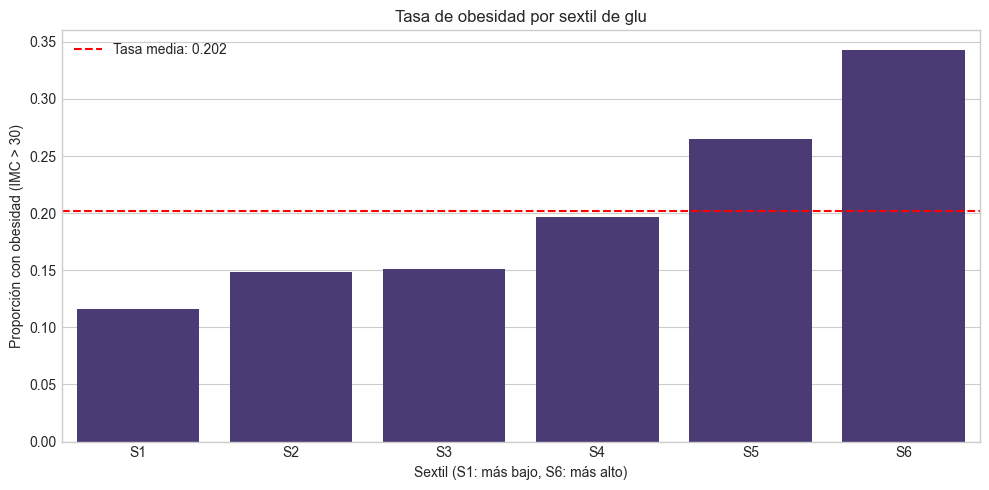


Tasa de obesidad por sextil de tgb:


,Sextil,Tasa de Obesidad
0,1.0,0.038251
1,2.0,0.164773
2,3.0,0.182320
3,4.0,0.256983
4,5.0,0.276836
5,6.0,0.292135


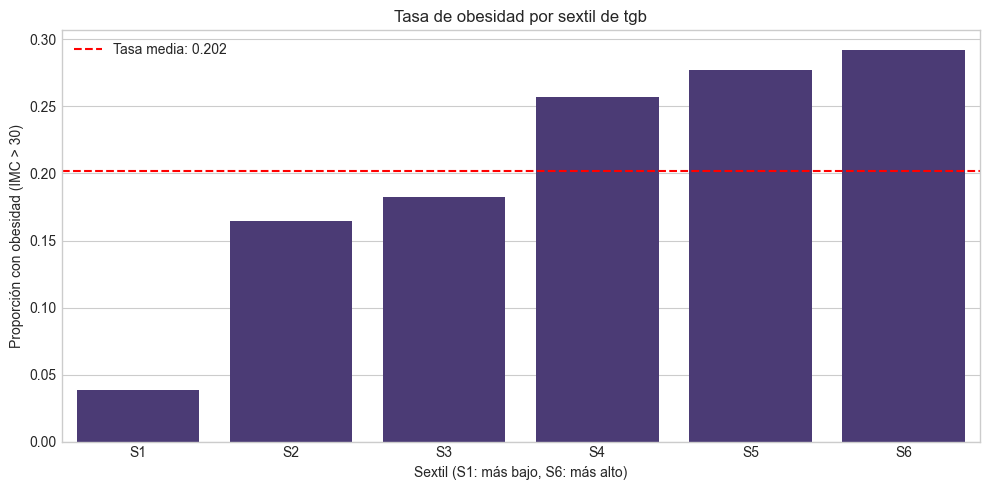


Tasa de obesidad por sextil de chol:


,Sextil,Tasa de Obesidad
0,1.0,0.197802
1,2.0,0.146067
2,3.0,0.232804
3,4.0,0.214286
4,5.0,0.233696
5,6.0,0.179191


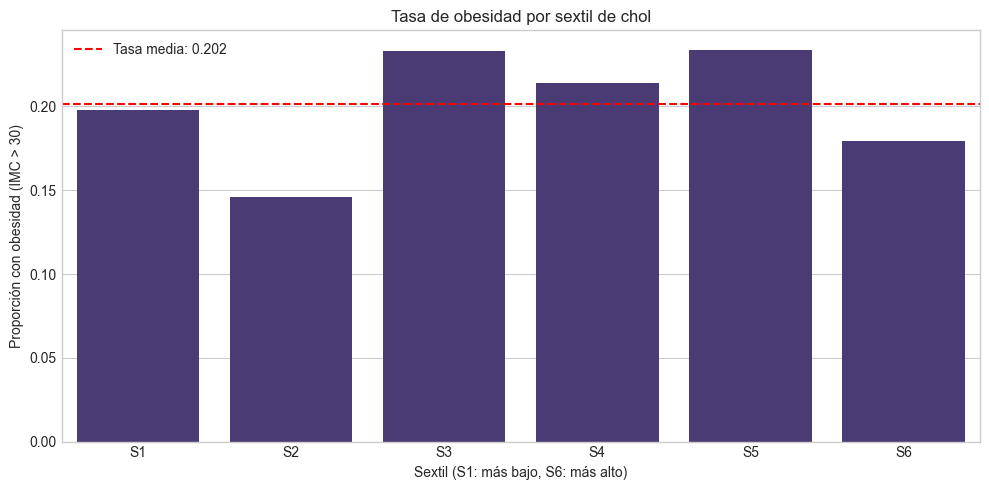


Tasa de obesidad por sextil de hdld:


,Sextil,Tasa de Obesidad
0,1.0,0.320856
1,2.0,0.256281
2,3.0,0.242236
3,4.0,0.203125
4,5.0,0.127273
5,6.0,0.035294


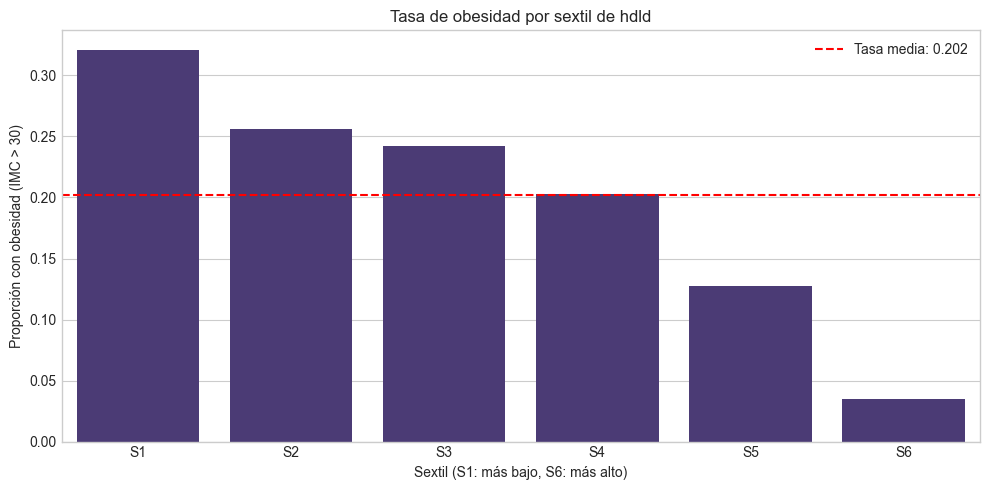


Tasa de obesidad por sextil de uric:


,Sextil,Tasa de Obesidad
0,1.0,0.073298
1,2.0,0.150838
2,3.0,0.188776
3,4.0,0.224242
4,5.0,0.278409
5,6.0,0.311377


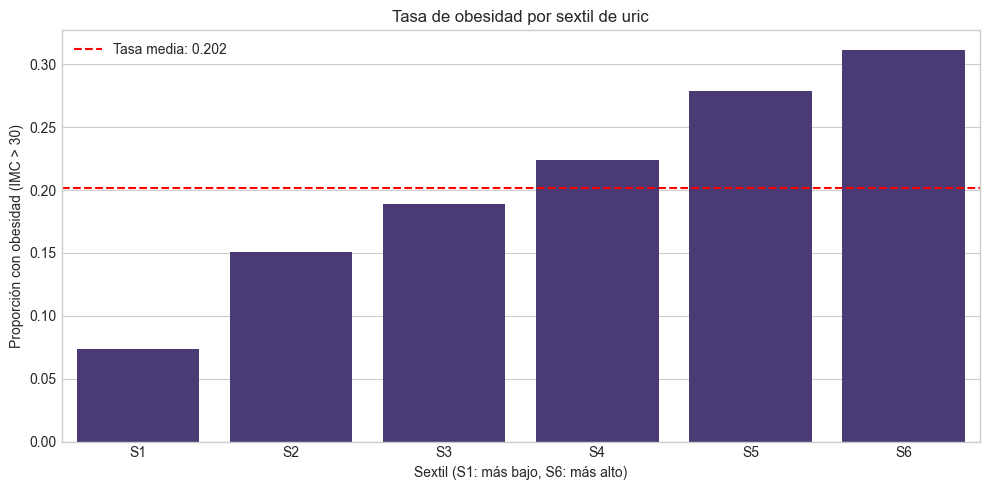


Tasa de obesidad por sextil de crs:


,Sextil,Tasa de Obesidad
0,1.0,0.245902
1,2.0,0.211111
2,3.0,0.224719
3,4.0,0.178378
4,5.0,0.196532
5,6.0,0.148571


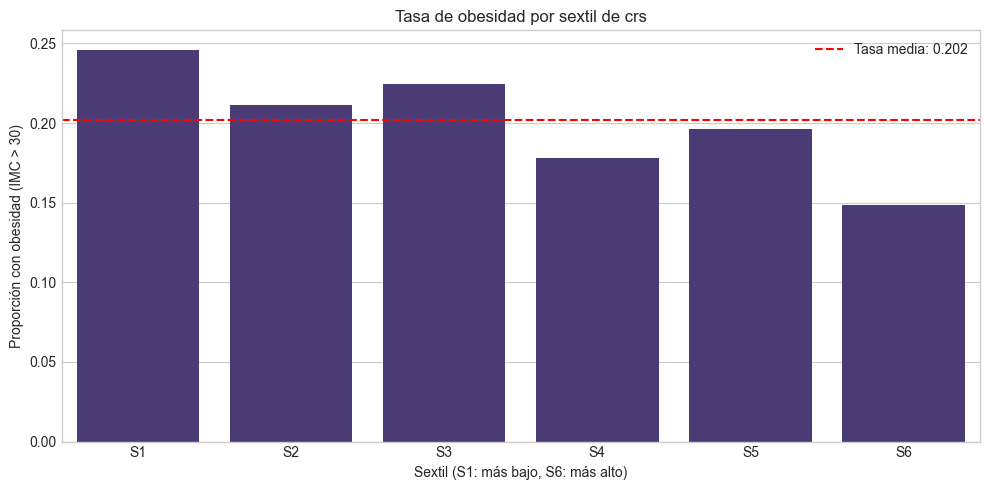


Tasa de obesidad por sextil de ldlc_res:


,Sextil,Tasa de Obesidad
0,1.0,0.184358
1,2.0,0.217877
2,3.0,0.161111
3,4.0,0.224719
4,5.0,0.215470
5,6.0,0.203390


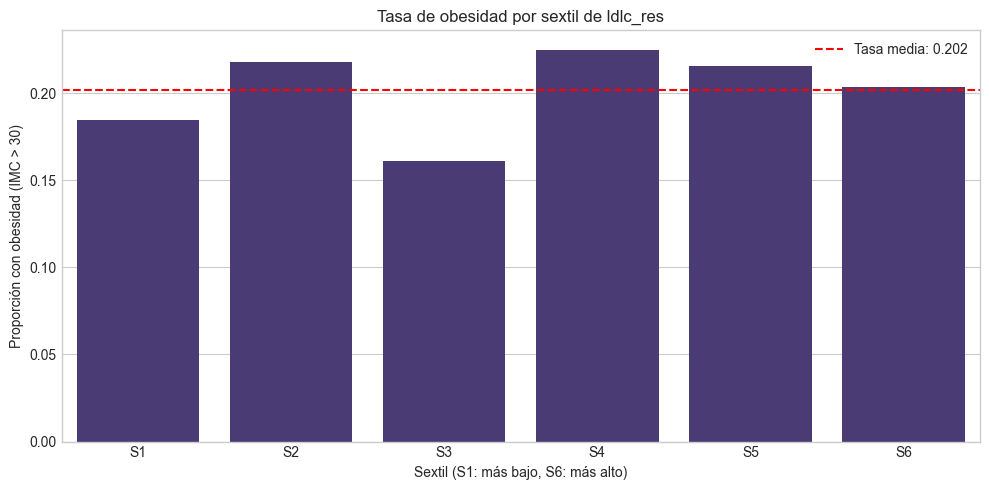


Tasa de obesidad por sextil de hba:


,Sextil,Tasa de Obesidad
0,1.0,0.071038
1,2.0,0.067797
2,3.0,0.181395
3,4.0,0.229885
4,5.0,0.298137
5,6.0,0.390244


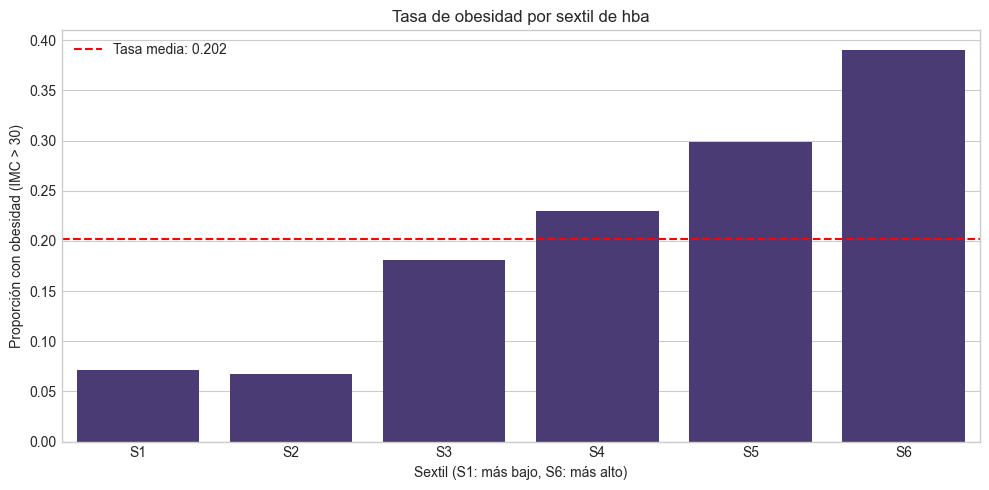


Tasa de obesidad por sextil de insulina:


,Sextil,Tasa de Obesidad
0,1.0,0.021622
1,2.0,0.043243
2,3.0,0.118343
3,4.0,0.214689
4,5.0,0.250000
5,6.0,0.567416


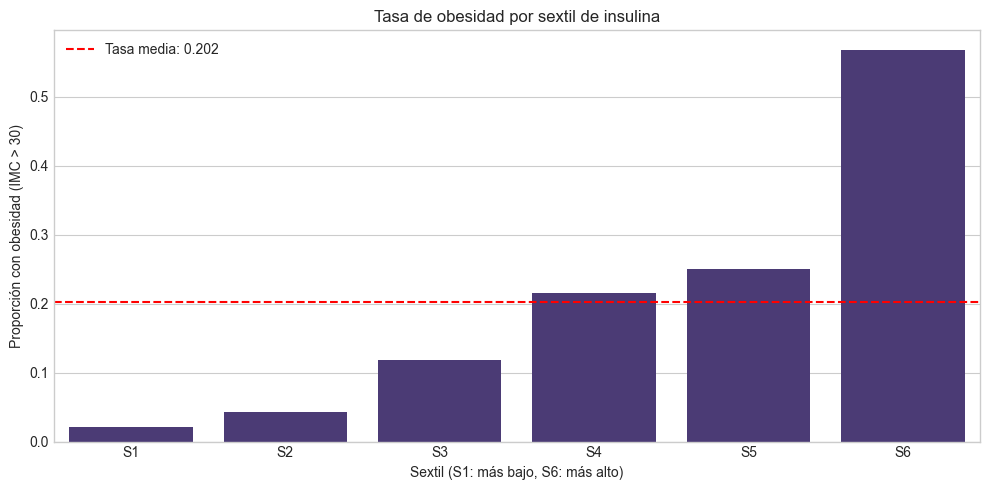


Tasa de obesidad por sextil de grad:


,Sextil,Tasa de Obesidad
0,1.0,0.246809
1,2.0,0.230769
2,3.0,0.203488
3,4.0,0.139344
4,5.0,0.187135
5,6.0,0.162011


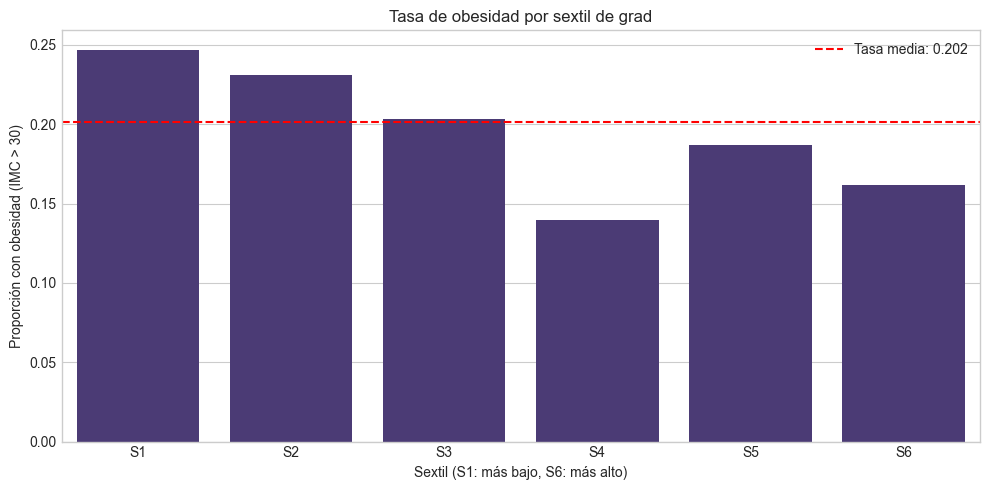


Tasa de obesidad por sextil de pos:


,Sextil,Tasa de Obesidad
0,1.0,0.234266
1,2.0,0.184502
2,4.0,0.180769
3,5.0,0.195219
4,6.0,0.500000


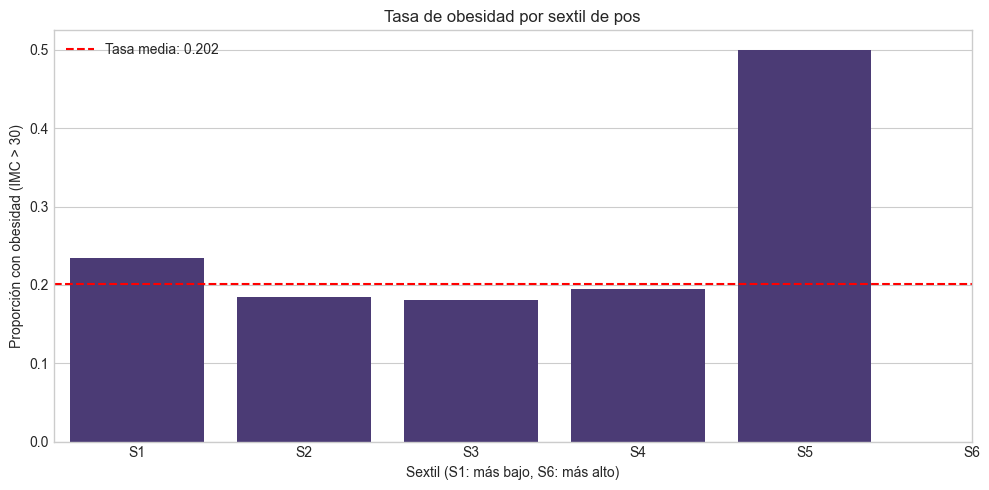


Tasa de obesidad por sextil de rep:


,Sextil,Tasa de Obesidad
0,1.0,0.201123
1,6.0,0.200000


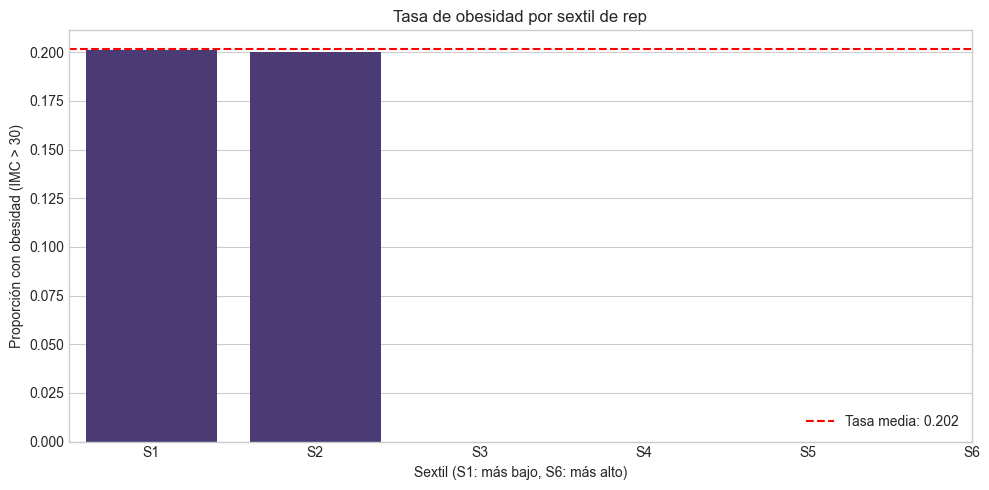

In [201]:
# Función para crear variables de sextiles para resultados de laboratorio
def create_lab_sextiles(df, lab_variables):
    # Inicializar para almacenar resultados
    lab_sextiles = {}
    sextile_features = []
    
    # Generar sextiles para cada variable de laboratorio
    for lab in lab_variables:
        # Asegurarse de que la variable existe y tiene suficientes valores no nulos
        if lab in df.columns and df[lab].notna().sum() > 6:
            # Calcular quintiles (5 puntos de corte para 6 grupos)
            quintiles = [df[lab].dropna().quantile(q/6) for q in range(1, 6)]
            lab_sextiles[lab] = quintiles
            
            # Crear columna de sextil para cada laboratorio
            sextile_col = f"{lab}_sextil"
            # Iniciar como NaN en lugar de 0 para evitar confusión con sextil 0
            df[sextile_col] = np.nan  
            
            # Asignar sextil a cada valor
            for i in range(5):
                if i == 0:
                    # Primer sextil: valores por debajo del primer umbral
                    df.loc[df[lab] <= quintiles[0], sextile_col] = 1
                else:
                    # Sextiles intermedios
                    df.loc[(df[lab] > quintiles[i-1]) & (df[lab] <= quintiles[i]), sextile_col] = i+1
            # Último sextil: valores por encima del umbral más alto
            df.loc[df[lab] > quintiles[-1], sextile_col] = 6
            
            sextile_features.append(sextile_col)
            print(f"Sextiles para {lab}: {quintiles}")
    
    return df, sextile_features, lab_sextiles

# Lista de variables de laboratorio para crear sextiles
lab_variables = ['glu', 'tgb', 'chol', 'hdld', 'uric', 'crs', 'ldlc_res', 'hba', 'insulina', 'grad', 'pos', 'rep']

# Crear sextiles
df_clean, sextile_features, lab_sextiles = create_lab_sextiles(df_clean, lab_variables)

# Agregar las nuevas características al diccionario de categorías
categories['Sextiles de Laboratorio'] = sextile_features

# Actualizar el diccionario inverso
for feature in sextile_features:
    feature_to_category[feature] = 'Sextiles de Laboratorio'

# Agregar los sextile_features a variables_predictoras
variables_predictoras.extend(sextile_features)

# Eliminar las variables originales de laboratorio de variables_predictoras para evitar redundancia
variables_predictoras = [var for var in variables_predictoras if var not in lab_variables]

print(f"\nSe han eliminado {len(lab_variables)} variables de laboratorio originales y añadido {len(sextile_features)} variables de sextiles.")
print(f"Número de variables predictoras: {len(variables_predictoras)}")

# Mostrar distribución de sextiles por variable de laboratorio con obesidad
print("\nDistribución de obesidad por sextil de variables de laboratorio:")
for lab in lab_variables:
    sextile_col = f"{lab}_sextil"
    if sextile_col in df_clean.columns:
        # Calcular tasa de obesidad por sextil, eliminando valores nulos o cero
        # Filtramos para mostrar solo sextiles 1-6 (valores válidos)
        obesity_rates = df_clean[df_clean[sextile_col].between(1, 6)].groupby(sextile_col)['obesidad'].mean().reset_index()
        obesity_rates.columns = ['Sextil', 'Tasa de Obesidad']
        print(f"\nTasa de obesidad por sextil de {lab}:")
        display(obesity_rates)
        
        # Visualizar
        plt.figure(figsize=(10, 5))
        sns.barplot(x='Sextil', y='Tasa de Obesidad', data=obesity_rates)
        plt.title(f'Tasa de obesidad por sextil de {lab}')
        plt.axhline(y=df_clean['obesidad'].mean(), color='r', linestyle='--', 
                   label=f'Tasa media: {df_clean["obesidad"].mean():.3f}')
        plt.legend()
        plt.xticks(range(6), [f'S{i+1}' for i in range(6)])  # Solo mostrar S1 a S6
        plt.xlabel('Sextil (S1: más bajo, S6: más alto)')
        plt.ylabel('Proporción con obesidad (IMC > 30)')
        plt.tight_layout()
        plt.show()

## Crear sextiles para variables numéricas adicionales

Continuamos la estrategia de convertir variables numéricas en sextiles para más variables como peso, edad, presión arterial, y otras variables numéricas discretas. Esto nos permite normalizar el análisis y reducir la dimensionalidad.

Se convertirán 33 variables adicionales a sextiles
Sextiles para peso: [55.0, 61.0, 67.0, 73.0, 82.0]
Sextiles para cintura: [80.5, 86.59999999999998, 91.0, 96.0, 102.91666666666674]
Sextiles para brazo: [25.0, 26.0, 27.0, 28.96666666666665, 30.0]
Sextiles para temp: [36.0, 36.0, 36.2, 36.3, 36.5]
Saltando diastolica: insuficiente variabilidad para sextiles
Saltando sistolica: insuficiente variabilidad para sextiles
Sextiles para Aedad: [29.0, 36.0, 42.5, 49.0, 56.0]
Sextiles para AAedad: [2.0, 3.0, 4.5, 6.0, 7.0]
Sextiles para edad_diab: [34.33333333333333, 38.0, 43.0, 49.33333333333333, 55.66666666666667]
Sextiles para edad_hiper: [30.999999999999996, 40.0, 45.0, 50.0, 57.0]
Sextiles para edad_cardi: [15.833333333333332, 29.666666666666664, 37.0, 43.33333333333333, 50.500000000000014]
Sextiles para edad_obes: [22.0, 30.0, 35.0, 40.0, 49.0]
Sextiles para mad_edad: [54.0, 59.0, 64.5, 72.0, 80.0]
Sextiles para pad_edad: [53.833333333333286, 60.0, 65.0, 72.0, 79.0]
Sextiles para her1_eda

,Sextil,Tasa de Obesidad
0,1.0,0.000000
1,2.0,0.005780
2,3.0,0.043956
3,4.0,0.143646
4,5.0,0.342246
5,6.0,0.710843


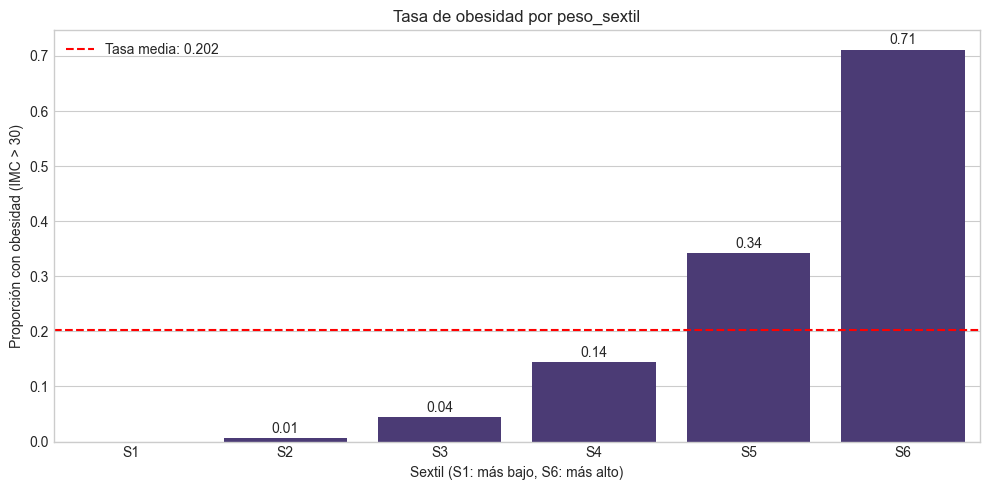


Tasa de obesidad por Aedad_sextil:


,Sextil,Tasa de Obesidad
0,1.0,0.077348
1,2.0,0.183168
2,3.0,0.264516
3,4.0,0.251309
4,5.0,0.247126
5,6.0,0.196532


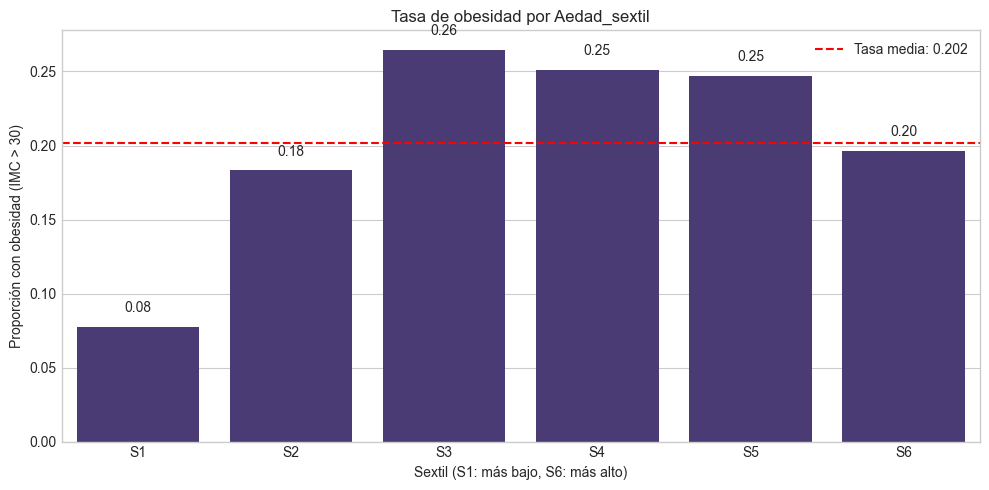


Tasa de obesidad por mad_edad_sextil:


,Sextil,Tasa de Obesidad
0,1.0,0.176190
1,2.0,0.155405
2,3.0,0.198864
3,4.0,0.233503
4,5.0,0.258242
5,6.0,0.174194


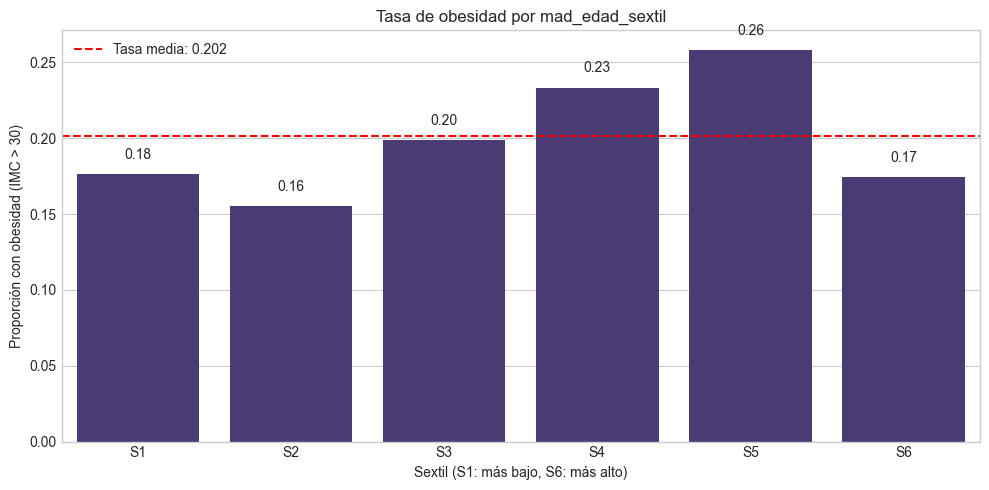

In [202]:
# Definir grupos de variables adicionales para convertir a sextiles
additional_sextile_groups = {
    'Antropometría': ['peso', 'cintura', 'brazo', 'temp', 'diastolica', 'sistolica'],
    'Edades': ['Aedad', 'AAedad', 'edad_diab', 'edad_hiper', 'edad_cardi', 'edad_obes'],
    'Familia': ['mad_edad', 'pad_edad', 'her1_edad', 'tio1_edad', 'hij1_edad', 'hij1_peso'],
    'Abuelos': ['mlito_edad', 'mlita_edad', 'plito_edad', 'plita_edad'],
    'Amigos': ['ami1_edad'],
    'Hábitos': ['alc', 'tpoalc', 'cigarros', 'fuma_act', 'duerme'],
    'Peso': ['peso_act', 'peso1', 'peso5', 'peso10', 'peso_edes']
}

# Acumular todas las variables para convertir a sextiles
all_sextile_variables = []
for category, vars_list in additional_sextile_groups.items():
    all_sextile_variables.extend(vars_list)

print(f"Se convertirán {len(all_sextile_variables)} variables adicionales a sextiles")

# Función generalizada para crear sextiles de cualquier variable numérica
def create_general_sextiles(df, variables, min_non_null=6):
    sextile_features = []
    variables_processed = []
    
    for var in variables:
        # Verificar que la variable existe y tiene suficientes valores no nulos
        if var in df.columns and df[var].notna().sum() > min_non_null:
            # Verificar que la variable es numérica
            if pd.api.types.is_numeric_dtype(df[var]) or df[var].dtype == 'float64' or df[var].dtype == 'int64':
                try:
                    # Crear nombre de columna para sextil
                    sextile_col = f"{var}_sextil"
                    
                    # Calcular quintiles (5 puntos de corte para 6 grupos)
                    quintiles = [df[var].dropna().quantile(q/6) for q in range(1, 6)]
                    
                    # Si todos los quintiles son iguales, saltamos esta variable
                    if len(set(quintiles)) < 4:  # Necesitamos al menos 4 valores distintos
                        print(f"Saltando {var}: insuficiente variabilidad para sextiles")
                        continue
                        
                    # Crear columna de sextil, inicializar con NaN
                    df[sextile_col] = np.nan
                    
                    # Asignar sextil a cada valor
                    for i in range(5):
                        if i == 0:
                            # Primer sextil: valores por debajo del primer umbral
                            df.loc[df[var] <= quintiles[0], sextile_col] = 1
                        else:
                            # Sextiles intermedios
                            df.loc[(df[var] > quintiles[i-1]) & (df[var] <= quintiles[i]), sextile_col] = i+1
                    # Último sextil: valores por encima del umbral más alto
                    df.loc[df[var] > quintiles[-1], sextile_col] = 6
                    
                    sextile_features.append(sextile_col)
                    variables_processed.append(var)
                    print(f"Sextiles para {var}: {quintiles}")
                except Exception as e:
                    print(f"Error al procesar {var}: {e}")
    
    return df, sextile_features, variables_processed

# Crear sextiles para variables adicionales
df_clean, additional_sextiles, processed_vars = create_general_sextiles(df_clean, all_sextile_variables)

# Crear categoría para estas nuevas variables de sextil
categories['Sextiles Adicionales'] = additional_sextiles

# Actualizar diccionario inverso
for feature in additional_sextiles:
    # Determinar la categoría original basada en la variable de origen
    original_var = feature.replace('_sextil', '')
    category_found = False
    
    for category, vars_list in additional_sextile_groups.items():
        if original_var in vars_list:
            feature_to_category[feature] = f"Sextiles {category}"
            category_found = True
            break
    
    # Si no encontramos la categoría específica, usamos la general
    if not category_found:
        feature_to_category[feature] = 'Sextiles Adicionales'

# Agregar los nuevos sextiles a variables_predictoras
variables_predictoras.extend(additional_sextiles)

# Eliminar las variables originales para evitar redundancia
variables_predictoras = [var for var in variables_predictoras if var not in processed_vars]

print(f"\nSe han procesado {len(processed_vars)} variables a sextiles y se han creado {len(additional_sextiles)} nuevas variables de sextil")
print(f"Número actualizado de variables predictoras: {len(variables_predictoras)}")

# Mostrar distribución de sextiles para algunas variables clave
key_vars = ['peso_sextil', 'sistolica_sextil', 'Aedad_sextil', 'alc_sextil', 'mad_edad_sextil']
for sextile_col in key_vars:
    if sextile_col in df_clean.columns:
        # Calcular tasa de obesidad por sextil, filtrando sólo sextiles válidos (1-6)
        obesity_rates = df_clean[df_clean[sextile_col].between(1, 6)].groupby(sextile_col)['obesidad'].mean().reset_index()
        obesity_rates.columns = ['Sextil', 'Tasa de Obesidad']
        print(f"\nTasa de obesidad por {sextile_col}:")
        display(obesity_rates)
        
        # Visualizar
        plt.figure(figsize=(10, 5))
        ax = sns.barplot(x='Sextil', y='Tasa de Obesidad', data=obesity_rates)
        plt.title(f'Tasa de obesidad por {sextile_col}')
        plt.axhline(y=df_clean['obesidad'].mean(), color='r', linestyle='--', 
                   label=f'Tasa media: {df_clean["obesidad"].mean():.3f}')
        
        # Añadir valores en las barras
        for i, p in enumerate(ax.patches):
            height = p.get_height()
            if not np.isnan(height) and height > 0:
                ax.text(p.get_x() + p.get_width()/2., height + 0.01,
                       f'{height:.2f}', ha='center')
        
        plt.legend()
        plt.xticks(range(6), [f'S{i+1}' for i in range(6)])  # Solo mostrar S1 a S6
        plt.xlabel('Sextil (S1: más bajo, S6: más alto)')
        plt.ylabel('Proporción con obesidad (IMC > 30)')
        plt.tight_layout()
        plt.show()

## Análisis integrado con todos los sextiles

Ahora que hemos convertido tanto los resultados de laboratorio como otras variables numéricas a sextiles, podemos realizar un análisis más uniforme y reducir la dimensionalidad del conjunto de datos.

In [203]:
# Resumen de todas las variables de sextiles creadas
all_sextiles = sextile_features + additional_sextiles
print(f"Total de variables de sextil creadas: {len(all_sextiles)}")

# Agrupar las variables de sextil por categoría para entender mejor su distribución
sextile_by_category = {}
for feature in all_sextiles:
    category = feature_to_category[feature]
    if category not in sextile_by_category:
        sextile_by_category[category] = []
    sextile_by_category[category].append(feature)

# Mostrar distribución por categoría
for category, features in sextile_by_category.items():
    print(f"{category}: {len(features)} variables")
    print(f"  Ejemplos: {', '.join(features[:3])}{'...' if len(features) > 3 else ''}")

# Evaluar el efecto de usar sextiles en la dimensionalidad
original_vars = processed_vars + lab_variables
print(f"\nReducción de dimensionalidad:")
print(f"Variables originales sustituidas: {len(original_vars)}")
print(f"Nuevas variables de sextil: {len(all_sextiles)}")
print(f"Diferencia en número de variables: {len(all_sextiles) - len(original_vars)}")

Total de variables de sextil creadas: 35
Sextiles de Laboratorio: 12 variables
  Ejemplos: glu_sextil, tgb_sextil, chol_sextil...
Sextiles Antropometría: 4 variables
  Ejemplos: peso_sextil, cintura_sextil, brazo_sextil...
Sextiles Edades: 6 variables
  Ejemplos: Aedad_sextil, AAedad_sextil, edad_diab_sextil...
Sextiles Familia: 6 variables
  Ejemplos: mad_edad_sextil, pad_edad_sextil, her1_edad_sextil...
Sextiles Abuelos: 4 variables
  Ejemplos: mlito_edad_sextil, mlita_edad_sextil, plito_edad_sextil...
Sextiles Amigos: 1 variables
  Ejemplos: ami1_edad_sextil
Sextiles Hábitos: 2 variables
  Ejemplos: tpoalc_sextil, cigarros_sextil

Reducción de dimensionalidad:
Variables originales sustituidas: 35
Nuevas variables de sextil: 35
Diferencia en número de variables: 0


In [204]:
# Inicializar lista de resultados
results = []

# Procesar cada característica
for feature in variables_predictoras:
    if feature not in feature_to_category:
        continue  # Saltamos variables sin categoría asignada
        
    category = feature_to_category[feature]
    
    # Analizar cada valor único para la característica
    # Para variables de sextiles, asegurarnos de filtrar los valores 0
    if '_sextil' in feature:
        unique_values = sorted(val for val in df_clean[feature].dropna().unique() if val >= 1 and val <= 6)
    else:
        unique_values = sorted(df_clean[feature].dropna().unique())
    
    for value in unique_values:
        description = f"{feature} = {value}"
        results.append(calculate_stats(feature, value, description, category))
    
    # Para algunas variables numéricas, analizar valores de umbral
    if feature in ['edad_diab', 'edad_hiper', 'edad_cardi', 'peso_act', 'num_fam', 'peso', 'cintura',
                  'sistolica', 'diastolica']:
        # Analizar percentiles como umbrales
        percentiles = [10, 20, 30, 40, 50, 60, 70, 80, 90]
        for p in percentiles:
            threshold = df_clean[feature].dropna().quantile(p/100)
            description = f"{feature} >= {threshold}"
            results.append(calculate_stats(feature, threshold, description, category, is_threshold=True))
    
    # Análisis especial para variables de sextiles de laboratorio
    if feature.endswith('_sextil'):
        # Para cada sextil, evaluar si pertenecer a ese sextil específico
        for sextile in range(1, 7):  # Sextiles 1-6 (eliminamos el 0)
            description = f"{feature} = {sextile} (Sextil {sextile})"
            results.append(calculate_stats(feature, sextile, description, category))

## Análisis de resultados de laboratorio por sextiles

Analizaremos cómo se relacionan los diferentes sextiles de los resultados de laboratorio con la probabilidad de tener obesidad (IMC > 30).

<Figure size 1500x1000 with 0 Axes>

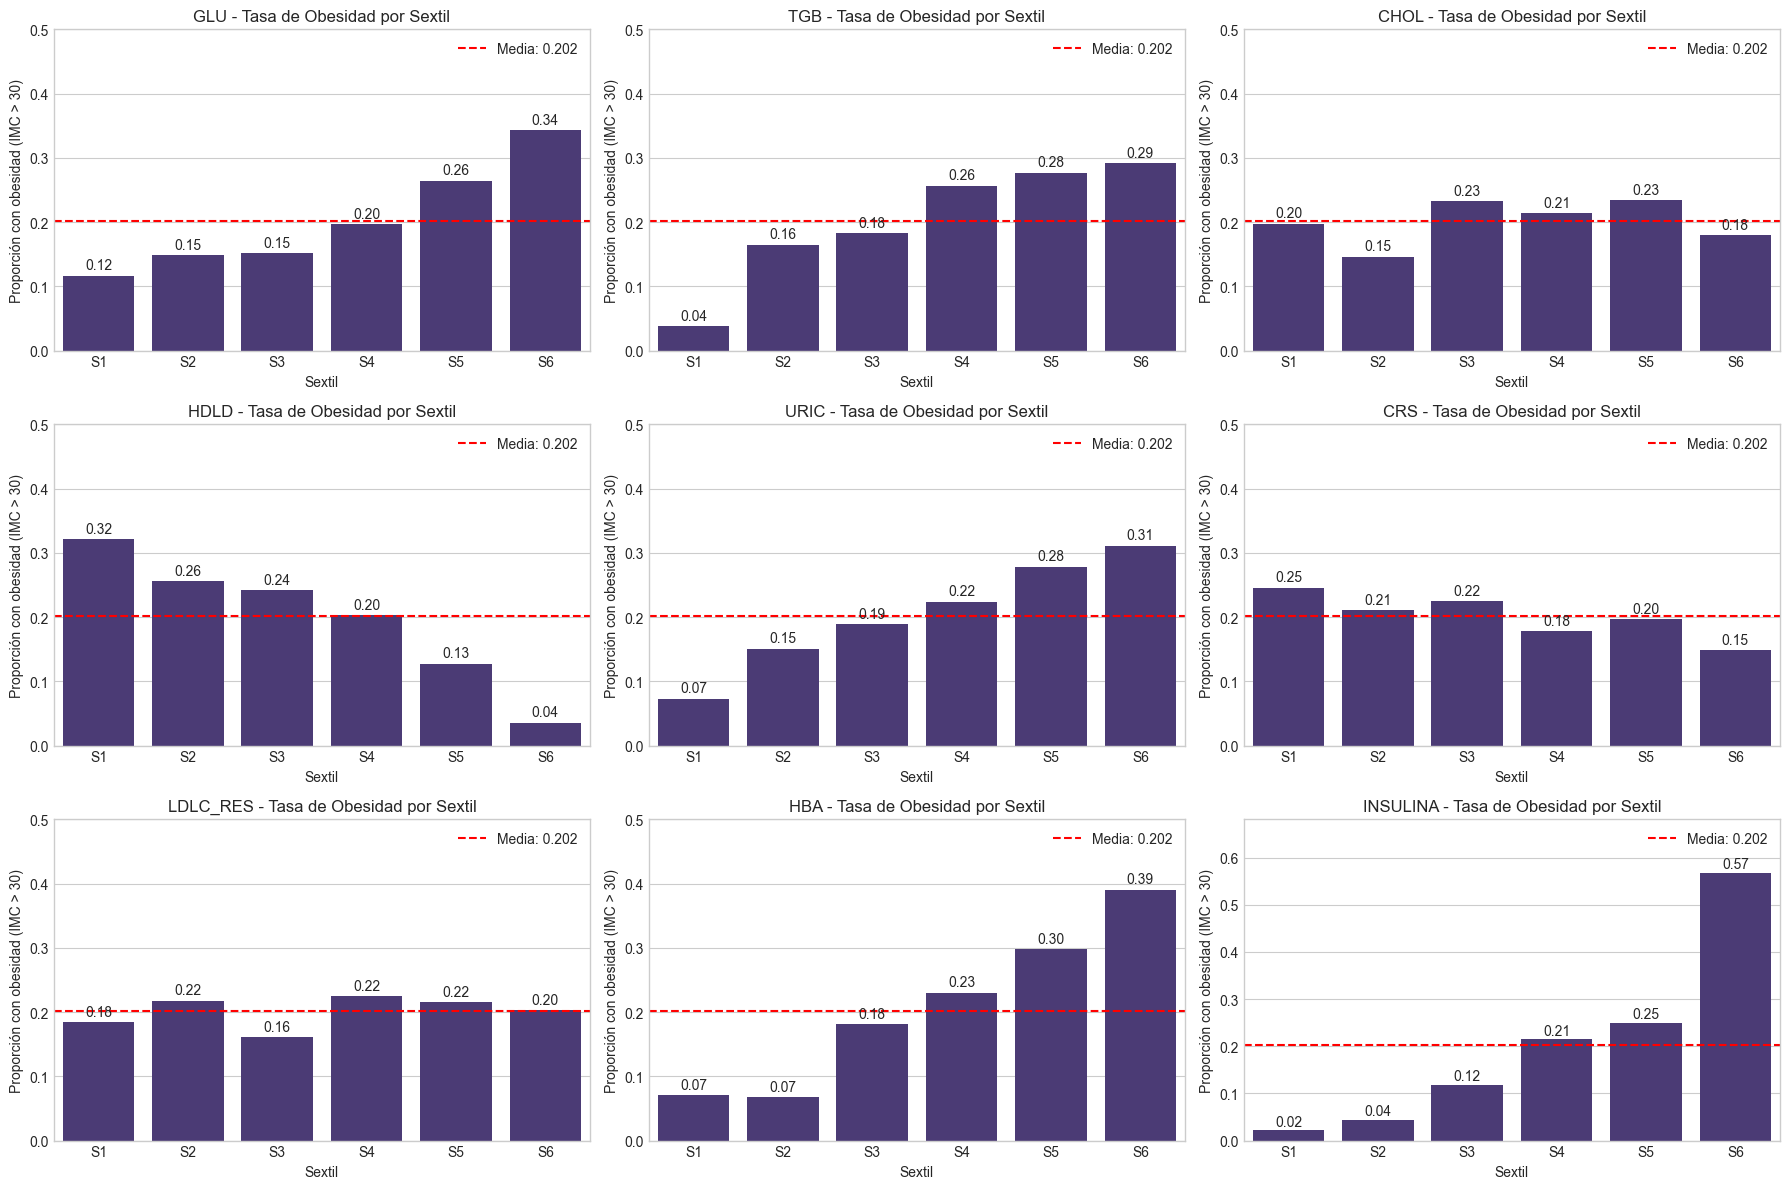

Top 15 sextiles más predictivos para obesidad:


,insulina_sextil,lab_var,obesidad_ratio,epsilon,total
5,6.0,insulina,0.567416,12.161067,178
0,1.0,insulina,0.021622,-6.103343,185
5,NaN,hba,0.390244,6.018423,164
0,NaN,tgb,0.038251,-5.509606,183
5,NaN,hdld,0.035294,-5.406399,170
1,2.0,insulina,0.043243,-5.370418,185
5,NaN,glu,0.342857,4.654695,175
1,NaN,hba,0.067797,-4.438907,177
0,NaN,uric,0.073298,-4.421616,191
0,NaN,hba,0.071038,-4.404226,183


Resumen de hallazgos para resultados de laboratorio relacionados con obesidad:


,Variable,Sextil con mayor obesidad,Tasa máxima,Sextil con menor obesidad,Tasa mínima,Tasa en rango normal,Epsilon máximo (abs)
8,insulina,6.0,0.567416,1.0,0.021622,0.166516,12.161067
7,hba,6.0,0.390244,2.0,0.067797,0.205640,6.018423
1,tgb,6.0,0.292135,1.0,0.038251,0.219652,5.509606
3,hdld,1.0,0.320856,6.0,0.035294,0.222681,5.406399
0,glu,6.0,0.342857,1.0,0.116402,0.173847,4.654695
4,uric,6.0,0.311377,1.0,0.073298,0.206509,4.421616
2,chol,5.0,0.233696,2.0,0.146067,0.223545,1.848899
5,crs,1.0,0.245902,6.0,0.148571,0.201549,1.750697
6,ldlc_res,4.0,0.224719,3.0,0.161111,0.192915,1.356247


In [205]:
# Visualizar relación entre sextiles y obesidad para cada resultado de laboratorio
lab_vars_to_analyze = ['glu', 'tgb', 'chol', 'hdld', 'uric', 'crs', 'ldlc_res', 'hba', 'insulina']
sextile_results = []

# Función para hacer análisis de sextiles y visualizarlos
def analyze_lab_sextiles(df, lab_vars):
    plt.figure(figsize=(15, 10))
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    # Para cada variable de laboratorio
    for i, lab in enumerate(lab_vars):
        sextile_col = f"{lab}_sextil"
        if sextile_col in df.columns:
            # Agrupar por sextil y calcular tasa de obesidad, eliminando valores nulos o 0
            # Filtramos para mostrar solo sextiles 1-6 (valores válidos)
            sextile_stats = df[df[sextile_col].between(1, 6)].groupby(sextile_col).agg({
                'obesidad': ['mean', 'count', 'sum']
            }).reset_index()
            sextile_stats.columns = [sextile_col, 'obesidad_ratio', 'total', 'obesidad_count']
            
            # Calcular epsilon para cada sextil
            prior_prob = df['obesidad'].mean()
            sextile_stats['epsilon'] = 0.0
            for idx, row in sextile_stats.iterrows():
                p_c_given_x = row['obesidad_ratio']
                n_x = row['total']
                if n_x > 0 and prior_prob < 1 and prior_prob > 0 and p_c_given_x > 0:
                    epsilon = (n_x * (p_c_given_x - prior_prob)) / (n_x * prior_prob * (1 - prior_prob))**0.5
                    sextile_stats.at[idx, 'epsilon'] = epsilon
            
            # Almacenar resultados
            sextile_stats['lab_var'] = lab
            sextile_results.append(sextile_stats)
            
            # Graficar
            ax = axes[i]
            sns.barplot(x=sextile_col, y='obesidad_ratio', data=sextile_stats, ax=ax)
            ax.axhline(y=prior_prob, color='r', linestyle='--', 
                      label=f'Media: {prior_prob:.3f}')
            ax.set_title(f'{lab.upper()} - Tasa de Obesidad por Sextil')
            ax.set_xlabel('Sextil')
            ax.set_ylabel('Proporción con obesidad (IMC > 30)')
            ax.set_ylim(0, max(0.5, sextile_stats['obesidad_ratio'].max() * 1.2))
            ax.legend(loc="upper right")
            
            # Establecer etiquetas X para mostrar solo S1-S6
            ax.set_xticks(range(len(sextile_stats)))
            # Aseguramos que las etiquetas del eje X sean coherentes independientemente de los sextiles disponibles
            ax.set_xticklabels([f'S{int(s)}' for s in sextile_stats[sextile_col]])
            
            # Añadir valores en las barras
            for j, p in enumerate(ax.patches):
                height = p.get_height()
                if not np.isnan(height) and height > 0:
                    ax.text(p.get_x() + p.get_width()/2., height + 0.01,
                           f'{height:.2f}', ha='center')
    
    plt.tight_layout()
    plt.show()
    
    # Combinar todos los resultados
    all_sextile_results = pd.concat(sextile_results)
    
    # Ordenar por valor absoluto de epsilon para identificar sextiles más informativos
    all_sextile_results['abs_epsilon'] = all_sextile_results['epsilon'].abs()
    top_sextiles = all_sextile_results.sort_values('abs_epsilon', ascending=False).head(15)
    
    print("Top 15 sextiles más predictivos para obesidad:")
    display(top_sextiles[[f'{lab}_sextil' if f'{lab}_sextil' in top_sextiles.columns else sextile_col, 'lab_var', 'obesidad_ratio', 'epsilon', 'total']])
    
    return all_sextile_results

# Ejecutar análisis de sextiles
all_lab_sextile_results = analyze_lab_sextiles(df_clean, lab_vars_to_analyze)

# Crear tabla resumen con hallazgos por variable de laboratorio
lab_summary = []

for lab in lab_vars_to_analyze:
    lab_data = all_lab_sextile_results[all_lab_sextile_results['lab_var'] == lab]
    sextile_col = f"{lab}_sextil"
    
    # Encontrar sextiles con mayor y menor probabilidad de obesidad
    if len(lab_data) > 0:
        max_obesity = lab_data.loc[lab_data['obesidad_ratio'].idxmax()]
        min_obesity = lab_data.loc[lab_data['obesidad_ratio'].idxmin()]
        
        # Calcular rango normal (sextiles 3-4)
        normal_range = lab_data[lab_data[sextile_col].between(3, 4)]
        normal_rate = normal_range['obesidad_ratio'].mean() if len(normal_range) > 0 else None
        
        # Añadir a resumen
        lab_summary.append({
            'Variable': lab,
            'Sextil con mayor obesidad': max_obesity[sextile_col],
            'Tasa máxima': max_obesity['obesidad_ratio'],
            'Sextil con menor obesidad': min_obesity[sextile_col],
            'Tasa mínima': min_obesity['obesidad_ratio'],
            'Tasa en rango normal': normal_rate,
            'Epsilon máximo (abs)': lab_data['abs_epsilon'].max()
        })

lab_summary_df = pd.DataFrame(lab_summary)
print("Resumen de hallazgos para resultados de laboratorio relacionados con obesidad:")
display(lab_summary_df.sort_values('Epsilon máximo (abs)', ascending=False))

## Visualización de factores importantes

Visualizaremos los factores más importantes para comprender mejor su impacto en la predicción.

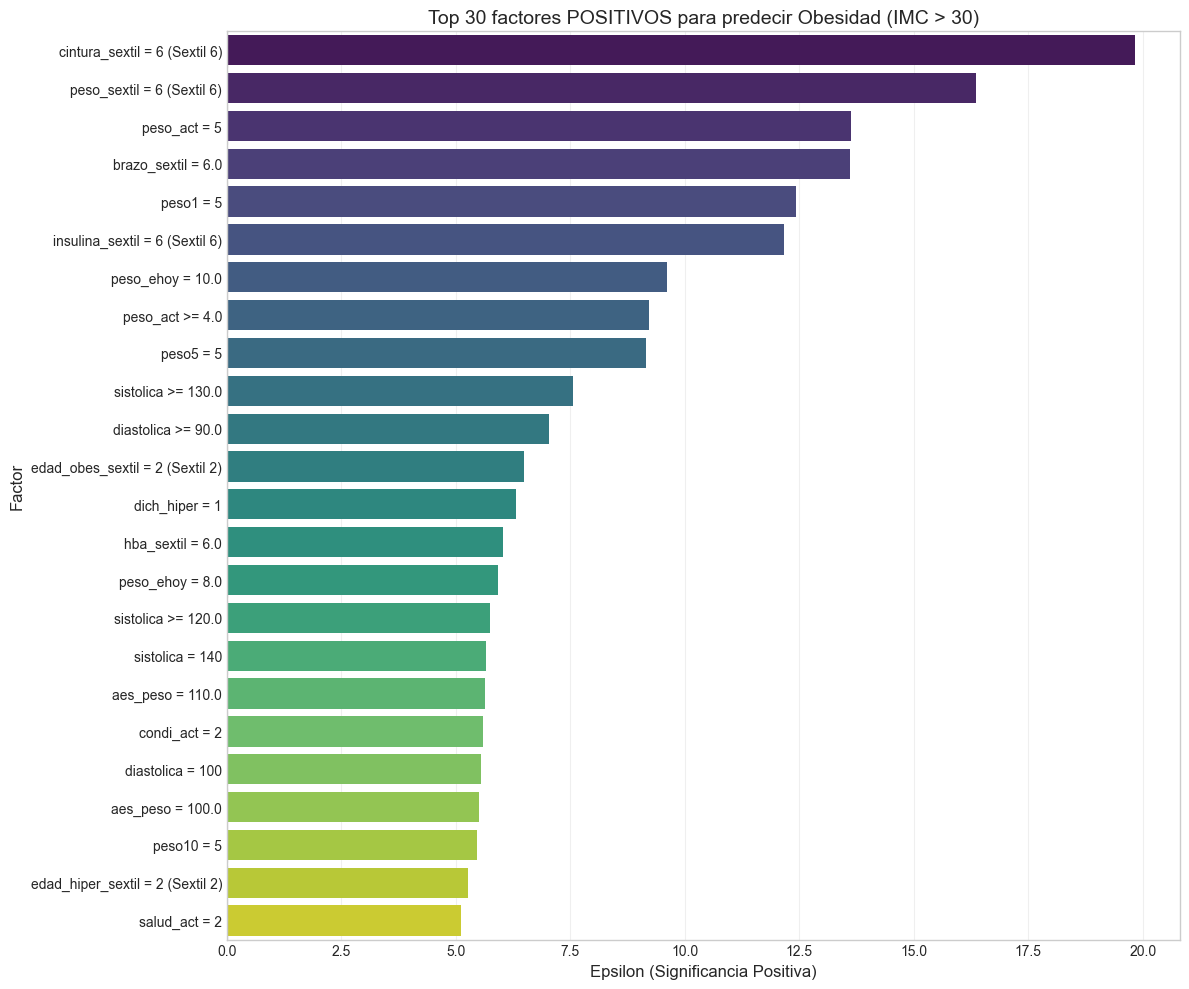

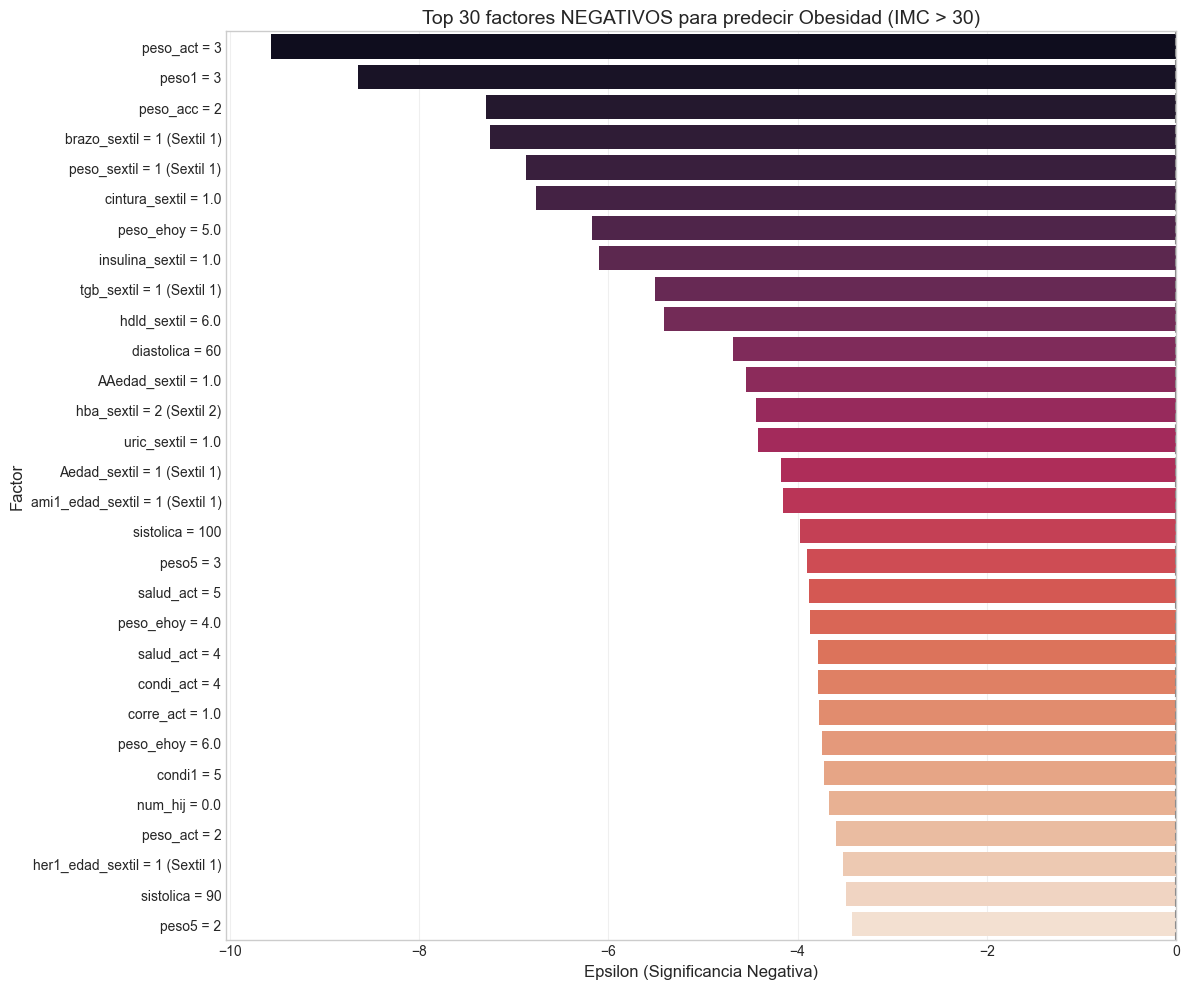


Factores que más AUMENTAN la probabilidad de obesidad (IMC > 30):


,Descripción,P(C|X),P(C),Epsilon,N(X)
4018,cintura_sextil = 6 (Sextil 6),0.79,0.2,19.82,180
4006,peso_sextil = 6 (Sextil 6),0.71,0.2,16.35,166
464,peso_act = 5,0.81,0.2,13.62,80
4024,brazo_sextil = 6.0,0.62,0.2,13.60,169
480,peso1 = 5,0.70,0.2,12.42,100
3963,insulina_sextil = 6 (Sextil 6),0.57,0.2,12.16,178
698,peso_ehoy = 10.0,0.63,0.2,9.60,81
475,peso_act >= 4.0,0.35,0.2,9.21,598
473,peso_act >= 4.0,0.35,0.2,9.21,598
472,peso_act >= 4.0,0.35,0.2,9.21,598



Factores que más DISMINUYEN la probabilidad de obesidad (IMC > 30):


,Descripción,P(C|X),P(C),Epsilon,N(X)
462,peso_act = 3,0.01,0.2,-9.56,419
478,peso1 = 3,0.04,0.2,-8.65,474
686,peso_acc = 2,0.01,0.2,-7.29,239
4025,brazo_sextil = 1 (Sextil 1),0.02,0.2,-7.25,246
4001,peso_sextil = 1 (Sextil 1),0.00,0.2,-6.87,187
4007,cintura_sextil = 1.0,0.00,0.2,-6.76,181
693,peso_ehoy = 5.0,0.05,0.2,-6.17,256
3952,insulina_sextil = 1.0,0.02,0.2,-6.10,185
3874,tgb_sextil = 1 (Sextil 1),0.04,0.2,-5.51,183
3897,hdld_sextil = 6.0,0.04,0.2,-5.41,170



De los top 30 factores POSITIVOS, 7 son sextiles (23%)
De los top 30 factores NEGATIVOS, 12 son sextiles (40%)


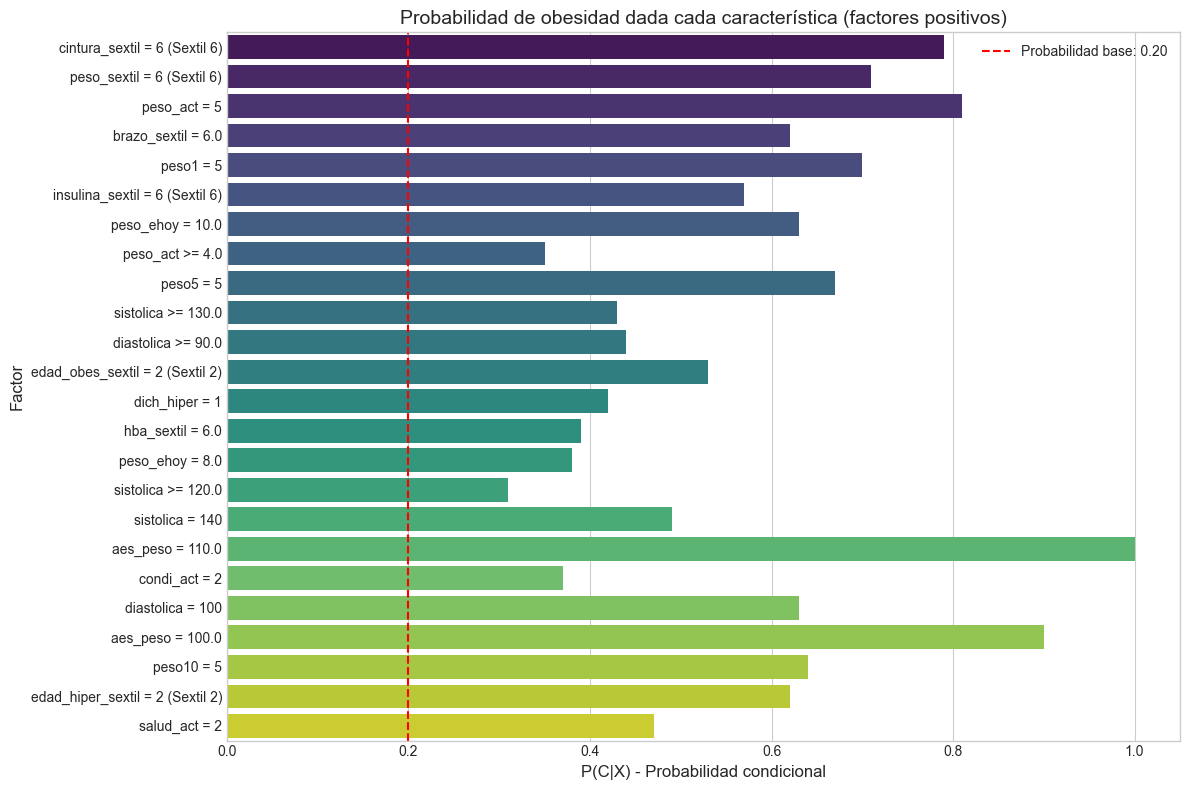

In [206]:
# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)

# Función para eliminar duplicados de sextiles, manteniendo solo el más significativo de cada tipo
def filter_duplicate_sextiles(df):
    # Crear una copia para no modificar el original
    filtered_df = df.copy()
    
    # Identificar las bases de los sextiles (por ejemplo, 'cintura' de 'cintura_sextil_6')
    sextil_bases = set()
    sextil_rows_to_keep = []
    
    # Para cada fila en el DataFrame
    for idx, row in filtered_df.iterrows():
        desc = row['Descripción']
        if '_sextil' in desc:
            # Extraer la base del nombre (todo antes de _sextil)
            base = desc.split('_sextil')[0]
            
            # Si esta base ya existe, solo mantener la primera ocurrencia (la más significativa)
            if base not in sextil_bases:
                sextil_bases.add(base)
                sextil_rows_to_keep.append(idx)
        else:
            # Mantener todos los no-sextiles
            sextil_rows_to_keep.append(idx)
    
    # Filtrar para mantener solo las filas seleccionadas
    return filtered_df.loc[sextil_rows_to_keep]

# Aplicar el filtro a los resultados
filtered_pos_results = filter_duplicate_sextiles(results_df.sort_values(by='Epsilon', ascending=False))
filtered_neg_results = filter_duplicate_sextiles(results_df.sort_values(by='Epsilon'))

# Seleccionar los top después de filtrar
top_pos = filtered_pos_results.head(30)
top_neg = filtered_neg_results.head(30)

# Visualizar los factores más predictivos (positivos)
plt.figure(figsize=(12, 10))
sns.barplot(x='Epsilon', y='Descripción', data=top_pos, palette='viridis')
plt.title('Top 30 factores POSITIVOS para predecir Obesidad (IMC > 30)', fontsize=14)
plt.xlabel('Epsilon (Significancia Positiva)', fontsize=12)
plt.ylabel('Factor', fontsize=12)
plt.axvline(x=0, color='gray', linestyle='--')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Visualizar los factores más predictivos (negativos)
plt.figure(figsize=(12, 10))
sns.barplot(x='Epsilon', y='Descripción', data=top_neg, palette='rocket')
plt.title('Top 30 factores NEGATIVOS para predecir Obesidad (IMC > 30)', fontsize=14)
plt.xlabel('Epsilon (Significancia Negativa)', fontsize=12)
plt.ylabel('Factor', fontsize=12)
plt.axvline(x=0, color='gray', linestyle='--')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar tabla resumen de los factores más influyentes (positivos y negativos)
print("\nFactores que más AUMENTAN la probabilidad de obesidad (IMC > 30):")
display(top_pos[['Descripción', 'P(C|X)', 'P(C)', 'Epsilon', 'N(X)']])

print("\nFactores que más DISMINUYEN la probabilidad de obesidad (IMC > 30):")
display(top_neg[['Descripción', 'P(C|X)', 'P(C)', 'Epsilon', 'N(X)']])

# Identificar cuántos de los top factores positivos y negativos son sextiles
sextile_pos_count = sum(1 for desc in top_pos['Descripción'] if '_sextil' in desc)
sextile_neg_count = sum(1 for desc in top_neg['Descripción'] if '_sextil' in desc)

print(f"\nDe los top 30 factores POSITIVOS, {sextile_pos_count} son sextiles ({sextile_pos_count/30:.0%})")
print(f"De los top 30 factores NEGATIVOS, {sextile_neg_count} son sextiles ({sextile_neg_count/30:.0%})")

# Para uso posterior en el modelo, también mantener una versión ordenada por valor absoluto
filtered_results_df = filter_duplicate_sextiles(results_df)
results_df_abs = filtered_results_df.sort_values(by='Epsilon', key=abs, ascending=False)

# Visualizar probabilidad condicional P(C|X) para top factores positivos
plt.figure(figsize=(12, 8))
sns.barplot(x='P(C|X)', y='Descripción', data=top_pos, palette='viridis')
plt.axvline(x=top_pos['P(C)'].iloc[0], color='red', linestyle='--', label=f'Probabilidad base: {top_pos["P(C)"].iloc[0]:.2f}')
plt.title('Probabilidad de obesidad dada cada característica (factores positivos)', fontsize=14)
plt.xlabel('P(C|X) - Probabilidad condicional', fontsize=12)
plt.ylabel('Factor', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


## Análisis por categoría

Analizaremos qué categorías de factores tienen mayor influencia en la predicción de obesidad, considerando tanto factores positivos como negativos.

Importancia por categoría (considerando dirección del efecto):


,Factores,Epsilon_Promedio,Max_Pos_Epsilon,Max_Neg_Epsilon,Max_Abs_Epsilon
Subcategoría,,,,,
Sextiles Antropometría,47,0.110638,19.82,-7.25,19.82
Peso,249,0.431888,13.62,-9.56,13.62
Sextiles de Laboratorio,139,0.007338,12.16,-6.10,12.16
Antropometría,88,0.910227,7.55,-4.68,7.55
Sextiles Edades,72,1.465833,6.49,-4.55,6.49
Salud,286,0.163322,6.31,-2.37,6.31
Percepción,131,0.079618,5.60,-3.88,5.60
Familia,1845,0.018602,4.22,-3.67,4.22
Ejercicio Actual,38,-0.678947,4.21,-3.77,4.21


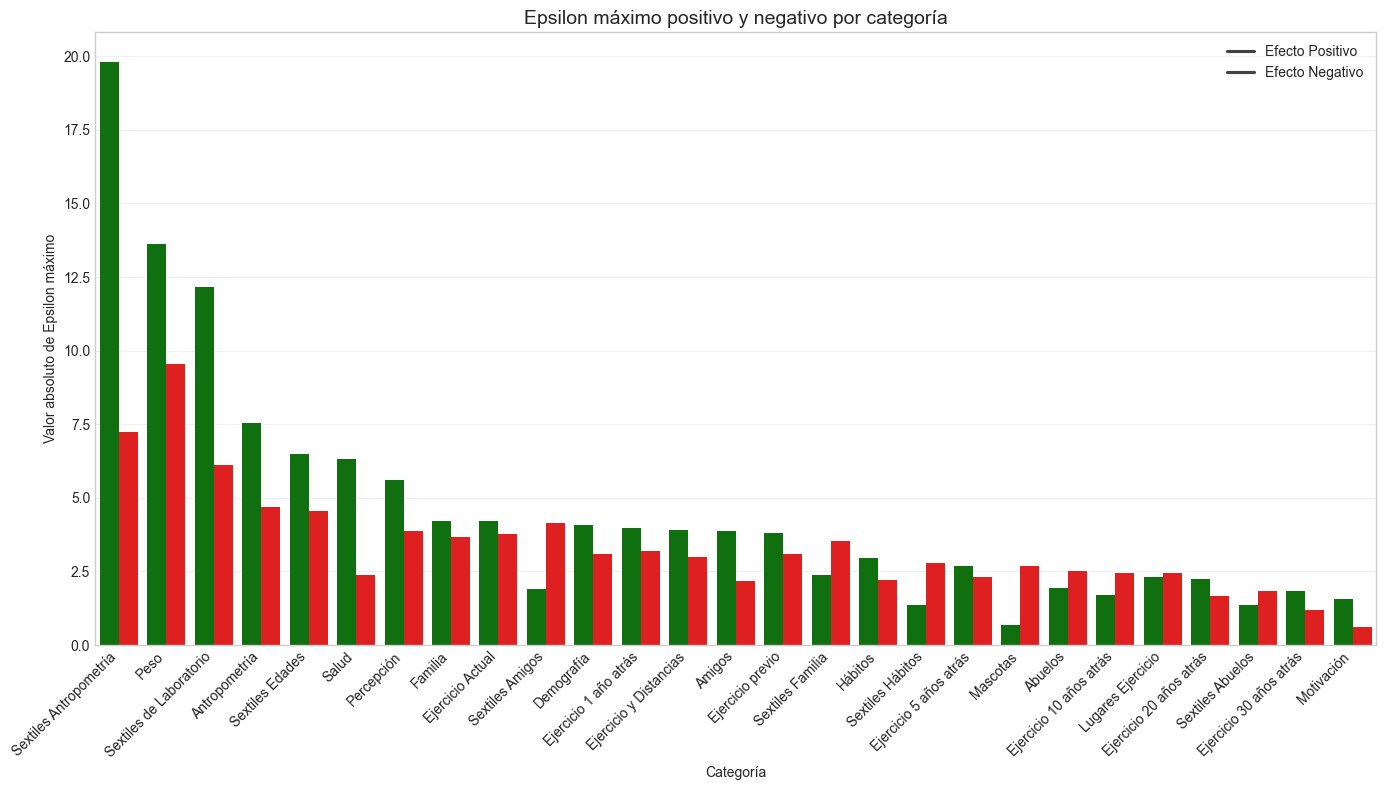

In [207]:
# Agrupar por categoría, manteniendo dirección del efecto
category_results = results_df.groupby('Subcategoría').agg(
    Factores=('Descripción', 'count'),
    Epsilon_Promedio=('Epsilon', 'mean'),
    Max_Pos_Epsilon=('Epsilon', lambda x: x[x > 0].max() if any(x > 0) else 0),
    Max_Neg_Epsilon=('Epsilon', lambda x: x[x < 0].min() if any(x < 0) else 0),
    Max_Abs_Epsilon=('Epsilon', lambda x: abs(x).max())
).sort_values(by='Max_Abs_Epsilon', ascending=False)

print("Importancia por categoría (considerando dirección del efecto):")
display(category_results)

# Visualizar epsilon máximo por categoría (positivo y negativo)
plt.figure(figsize=(14, 8))

# Preparar datos para gráfico
plot_data = pd.DataFrame({
    'Categoría': category_results.index,
    'Max_Pos': category_results['Max_Pos_Epsilon'],
    'Max_Neg': category_results['Max_Neg_Epsilon'].abs()  # Tomamos valor absoluto para visualización
}).melt(id_vars='Categoría', var_name='Tipo', value_name='Epsilon')

# Crear gráfico de barras agrupadas
sns.barplot(x='Categoría', y='Epsilon', hue='Tipo', data=plot_data, palette=['green', 'red'])
plt.title('Epsilon máximo positivo y negativo por categoría', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Valor absoluto de Epsilon máximo')
plt.legend(title='', labels=['Efecto Positivo', 'Efecto Negativo'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Modelo predictivo con Naive Bayes

Ahora implementaremos un modelo predictivo utilizando los factores más importantes que hemos identificado.

In [208]:
def calculate_customer_scores(df, top_drivers):
    print("Calculando puntuaciones para todos los pacientes...")
    
    # Obtener probabilidad previa de obesidad
    prior_probability = df['obesidad'].mean()
    prior_odds = prior_probability / (1 - prior_probability)
    log_prior = math.log(prior_odds) if prior_odds > 0 else 0
    
    # Inicializar array para puntuaciones
    customer_scores = np.ones(len(df)) * log_prior
    
    # Diccionario para almacenar razones de verosimilitud
    likelihood_ratios = {}
    
    # Seguimiento de características utilizadas
    used_features = set()
    selected_features = []
    positive_features = []
    negative_features = []
    sextile_features = []
    non_sextile_features = []
    
    # Usar los top drivers (características más predictivas)
    for _, row in top_drivers.iterrows():
        feature = row['Feature']
        value = row['Value']
        is_threshold = row['Is_Threshold']
        epsilon = row['Epsilon']
        is_sextile = '_sextil' in feature
        
        # Omitir si la característica ya se ha utilizado
        if feature in used_features:
            continue
            
        # Agregar característica al conjunto de utilizadas
        used_features.add(feature)
        
        # Registrar la característica seleccionada
        feature_desc = {
            'feature': feature,
            'value': value,
            'is_threshold': is_threshold,
            'epsilon': epsilon,
            'is_sextile': is_sextile
        }
        selected_features.append(feature_desc)
        
        # Clasificar por tipo de característica
        if epsilon > 0:
            positive_features.append(feature_desc)
        else:
            negative_features.append(feature_desc)
            
        if is_sextile:
            sextile_features.append(feature_desc)
        else:
            non_sextile_features.append(feature_desc)
        
        # Crear condición
        if is_threshold:
            condition = df[feature] >= value
        else:
            condition = df[feature] == value
        
        # Contar pacientes obesos y no obesos
        positive_instances = df['obesidad'].sum()
        negative_instances = len(df) - positive_instances
        
        # Calcular probabilidades condicionales con suavizado de Laplace
        count_with_C = ((df['obesidad'] == 1) & condition).sum() + 1
        count_with_not_C = (condition & (df['obesidad'] == 0)).sum() + 1
        
        P_X_given_C = count_with_C / (positive_instances + 2)
        P_X_given_not_C = count_with_not_C / (negative_instances + 2)
        
        # Calcular razón de log-verosimilitud
        log_ratio = math.log(P_X_given_C / P_X_given_not_C)
        
        # Aplicar a pacientes que coinciden
        customer_scores[condition] += log_ratio
        
        # Para pacientes que no coinciden, aplicar la verosimilitud complementaria
        comp_count_with_C = positive_instances - ((df['obesidad'] == 1) & condition).sum() + 1
        comp_count_with_not_C = negative_instances - (condition & (df['obesidad'] == 0)).sum() + 1
        comp_P_X_given_C = comp_count_with_C / (positive_instances + 2)
        comp_P_X_given_not_C = comp_count_with_not_C / (negative_instances + 2)
        comp_log_ratio = math.log(comp_P_X_given_C / comp_P_X_given_not_C)
        
        customer_scores[~condition] += comp_log_ratio
    
    # Determinar el nombre correcto de la columna folio
    folio_column = 'folio' if 'folio' in df.columns else 'ï»¿folio'
    
    # Crear DataFrame con IDs y puntuaciones
    scores_df = pd.DataFrame({
        'Folio': df[folio_column],
        'Score': customer_scores,
        'Probability': 1 / (1 + np.exp(-customer_scores)),  # Convertir log-odds a probabilidad
        'Actual': df['obesidad']
    })
    
    # Ordenar por puntuación en orden descendente
    scores_df = scores_df.sort_values(by='Score', ascending=False)
    
    # Calcular lift para los grupos de N principales
    for n in [10, 20, 50, 100]:
        if len(scores_df) >= n:
            top_n = scores_df.head(n)
            lift = (top_n['Actual'].mean() / prior_probability)
            print(f"Lift para los {n} principales pacientes: {lift:.2f}x")
    
    return scores_df, used_features, selected_features, positive_features, negative_features, sextile_features, non_sextile_features

# Calcular puntuaciones usando los 20 principales drivers (por valor absoluto de epsilon)
top_drivers_for_scoring = results_df_abs.head(20)

# Calcular puntuaciones y obtener características seleccionadas
patient_scores, used_features, selected_features, positive_features, negative_features, sextile_features, non_sextile_features = calculate_customer_scores(
    df_clean, top_drivers_for_scoring
)

# Mostrar características seleccionadas
print("\n=== CARACTERÍSTICAS SELECCIONADAS PARA EL MODELO FINAL ===")
print(f"\nTotal: {len(selected_features)} características")
print(f"Sextiles: {len(sextile_features)} características ({len(sextile_features)/len(selected_features):.0%})")
print(f"No sextiles: {len(non_sextile_features)} características ({len(non_sextile_features)/len(selected_features):.0%})")

print("\nFactores POSITIVOS (aumentan probabilidad de obesidad):")
for i, feature in enumerate(positive_features, 1):
    if feature['is_threshold']:
        feature_desc = f"{feature['feature']} >= {feature['value']}"
    else:
        feature_desc = f"{feature['feature']} = {feature['value']}"
    
    sextile_tag = "[SEXTIL]" if feature['is_sextile'] else ""
    print(f"{i}. {feature_desc} (Epsilon: {feature['epsilon']:.2f}) {sextile_tag}")

print("\nFactores NEGATIVOS (disminuyen probabilidad de obesidad):")
for i, feature in enumerate(negative_features, 1):
    if feature['is_threshold']:
        feature_desc = f"{feature['feature']} >= {feature['value']}"
    else:
        feature_desc = f"{feature['feature']} = {feature['value']}"
    
    sextile_tag = "[SEXTIL]" if feature['is_sextile'] else ""
    print(f"{i}. {feature_desc} (Epsilon: {feature['epsilon']:.2f}) {sextile_tag}")

print(f"\nNúmero total de características únicas utilizadas: {len(used_features)}")
print("Lista de características:", ", ".join(sorted(used_features)))

# Mostrar los 20 pacientes con mayor probabilidad de obesidad
print("\nTop 20 pacientes con mayor probabilidad de obesidad (IMC > 30):")
top_patients = patient_scores.head(20)
display(top_patients[['Folio', 'Score', 'Probability', 'Actual']])

# Calcular métricas de rendimiento
total_positive = df_clean['obesidad'].sum()
print(f"\nTotal de pacientes con obesidad: {total_positive}")
print(f"Probabilidad base: {(total_positive / len(df_clean)) * 100:.2f}%")

# Calcular precisión en diferentes umbrales
for k in [10, 20, 50, 100]:
    if len(patient_scores) >= k:
        precision = patient_scores.head(k)['Actual'].sum() / k
        recall = patient_scores.head(k)['Actual'].sum() / total_positive
        print(f"Precisión@{k}: {precision*100:.2f}%, Recall@{k}: {recall*100:.2f}%")

Calculando puntuaciones para todos los pacientes...
Lift para los 10 principales pacientes: 4.96x
Lift para los 20 principales pacientes: 4.71x
Lift para los 50 principales pacientes: 4.36x
Lift para los 100 principales pacientes: 3.82x

=== CARACTERÍSTICAS SELECCIONADAS PARA EL MODELO FINAL ===

Total: 12 características
Sextiles: 4 características (33%)
No sextiles: 8 características (67%)

Factores POSITIVOS (aumentan probabilidad de obesidad):
1. peso_act = 5 (Epsilon: 13.62) 
2. peso1 = 5 (Epsilon: 12.42) 
3. peso_ehoy = 10.0 (Epsilon: 9.60) 
4. peso5 = 5 (Epsilon: 9.16) 
5. sistolica >= 130.0 (Epsilon: 7.55) 
6. diastolica >= 90.0 (Epsilon: 7.03) 
7. dich_hiper = 1 (Epsilon: 6.31) 

Factores NEGATIVOS (disminuyen probabilidad de obesidad):
1. peso_acc = 2 (Epsilon: -7.29) 
2. brazo_sextil = 1.0 (Epsilon: -7.25) [SEXTIL]
3. peso_sextil = 1.0 (Epsilon: -6.87) [SEXTIL]
4. cintura_sextil = 1.0 (Epsilon: -6.76) [SEXTIL]
5. insulina_sextil = 1.0 (Epsilon: -6.10) [SEXTIL]

Número total 

,Folio,Score,Probability,Actual
249,647,12.149833,0.999995,1
811,615,10.887955,0.999981,1
458,550,10.887955,0.999981,1
113,88,10.887955,0.999981,1
1068,1033,10.766604,0.999979,1
1044,500,10.766604,0.999979,1
1072,1068,10.029145,0.999956,1
114,89,10.029145,0.999956,1
950,470,9.899434,0.999950,1
206,1009,9.899434,0.999950,1



Total de pacientes con obesidad: 217
Probabilidad base: 20.17%
Precisión@10: 100.00%, Recall@10: 4.61%
Precisión@20: 95.00%, Recall@20: 8.76%
Precisión@50: 88.00%, Recall@50: 20.28%
Precisión@100: 77.00%, Recall@100: 35.48%


## Evaluación del modelo y visualización de resultados

Evaluaremos el rendimiento del modelo y visualizaremos los resultados.

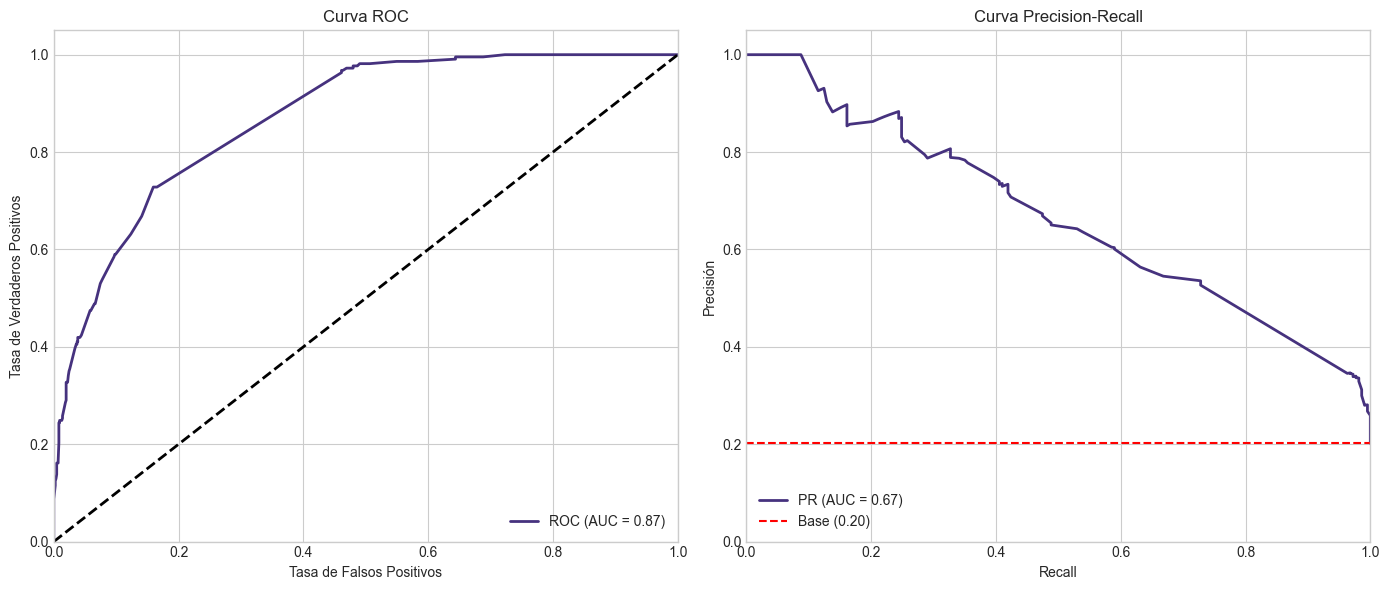

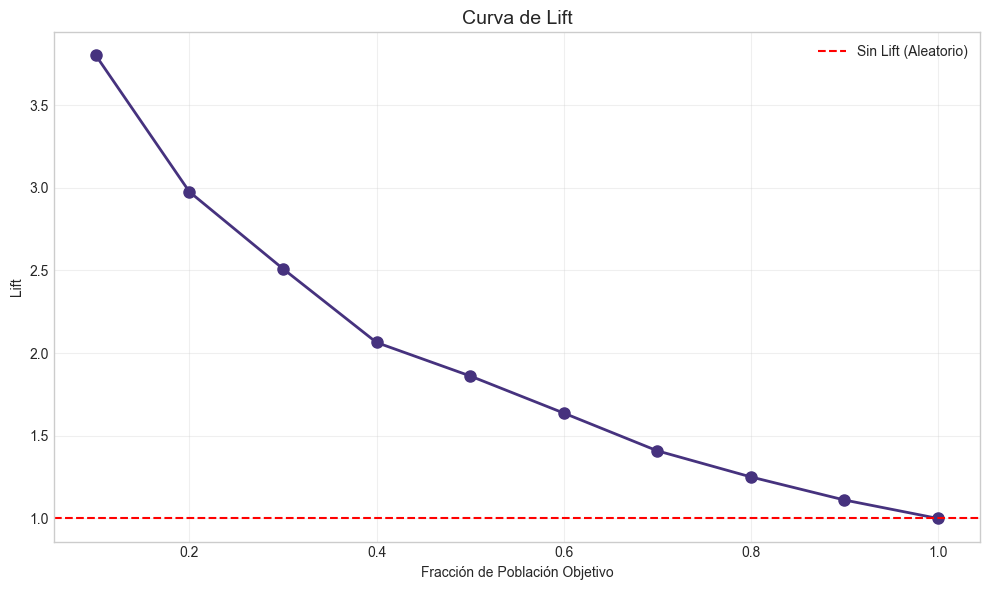

In [209]:
# Calcular curva ROC y AUC
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Calcular ROC
fpr, tpr, thresholds = roc_curve(patient_scores['Actual'], patient_scores['Probability'])
roc_auc = auc(fpr, tpr)

# Calcular Precision-Recall
precision, recall, _ = precision_recall_curve(patient_scores['Actual'], patient_scores['Probability'])
pr_auc = auc(recall, precision)

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Curva ROC
ax1.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=2)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('Tasa de Falsos Positivos')
ax1.set_ylabel('Tasa de Verdaderos Positivos')
ax1.set_title('Curva ROC')
ax1.legend(loc="lower right")

# Curva Precision-Recall
ax2.plot(recall, precision, lw=2, label=f'PR (AUC = {pr_auc:.2f})')
base_line = len(patient_scores[patient_scores['Actual'] == 1]) / len(patient_scores)
ax2.axhline(y=base_line, color='r', linestyle='--', label=f'Base ({base_line:.2f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precisión')
ax2.set_title('Curva Precision-Recall')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

# Visualizar lift
percentiles = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
lifts = []

for p in percentiles:
    cutoff = int(len(patient_scores) * p)
    if cutoff > 0:
        top_p_percent = patient_scores.head(cutoff)
        lift = top_p_percent['Actual'].mean() / base_line
        lifts.append(lift)

plt.figure(figsize=(10, 6))
plt.plot(percentiles, lifts, 'o-', linewidth=2, markersize=8)
plt.axhline(y=1, color='r', linestyle='--', label='Sin Lift (Aleatorio)')
plt.title('Curva de Lift', fontsize=14)
plt.xlabel('Fracción de Población Objetivo')
plt.ylabel('Lift')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Análisis de necesidad y suficiencia

Analizaremos si los principales factores son necesarios, suficientes o ambos para predecir si una persona hace ejercicio.

In [210]:
# Análisis mejorado de condiciones necesarias y suficientes
feature_analysis = []

# Extraer las principales características del análisis uniperspectivo
key_features = []
for _, row in top_drivers_for_scoring.head(15).iterrows():  # Usar las 15 principales
    key_features.append((row['Feature'], row['Value'], row['Is_Threshold']))

total_patients = len(df_clean)
total_exercisers = df_clean['ejer_act'].sum()
base_rate = total_exercisers / total_patients

# Crear un mapeo de nombres de características más amigables
feature_display_names = {
    'AIMC_sextil': 'IMC',
    'cintura_sextil': 'Cintura',
    'peso_sextil': 'Peso',
    'peso_act': 'Peso Actual',
    'brazo_sextil': 'Medida Brazo',
    'peso1': 'Peso hace 1 año',
    'insulina_sextil': 'Insulina',
    'peso_ehoy': 'Peso Esperado',
    'peso5': 'Peso hace 5 años'
}

for feature, value, is_threshold in key_features:
    # Crear condición
    if is_threshold:
        condition = (df_clean[feature] >= value)
        value_label = f">= {value}"
    else:
        condition = (df_clean[feature] == value)
        value_label = str(value)
        
    patients_with_feature = condition.sum()
    p_x = patients_with_feature / total_patients
    
    # Corregir cálculo: asegurarnos que estamos filtrando correctamente para ejercicio
    exercisers_with_feature = (condition & (df_clean['ejer_act'] == 1)).sum()
    
    # Si no hay ejercitantes totales, evitar división por cero
    p_x_given_c = exercisers_with_feature / total_exercisers if total_exercisers > 0 else 0
    p_c_given_x = exercisers_with_feature / patients_with_feature if patients_with_feature > 0 else 0
    
    # Calcular métricas con manejo de caso límite
    lift = p_c_given_x / base_rate if base_rate > 0 else 0
    
    # Calcular cobertura y precisión
    coverage = p_x  # ¿Qué tan común es esta característica?
    precision = p_c_given_x  # ¿Qué probabilidad hay de que personas con esta característica hagan ejercicio?
    recall = p_x_given_c  # ¿Qué porcentaje de personas que hacen ejercicio tienen esta característica?
    
    # Verificar valores calculados para depuración
    print(f"Feature: {feature}, Value: {value}, Patients with feature: {patients_with_feature}, "
          f"Exercisers with feature: {exercisers_with_feature}, P(C|X): {precision:.2f}, "
          f"Recall: {recall:.2f}, Lift: {lift:.2f}x")
    
    # Determinar necesidad y suficiencia basada en métricas más apropiadas
    necessary = recall > 0.3  # La característica aparece en >30% de todos los casos positivos
    sufficient = precision > (2 * base_rate)  # La característica duplica la probabilidad de hacer ejercicio
    
    # Usar nombre más amigable si está disponible
    display_name = feature_display_names.get(feature, feature)
    
    # Almacenar el análisis
    feature_analysis.append({
        'Feature': feature,
        'DisplayName': display_name,
        'Value': value_label,
        'Coverage': f"{p_x:.2%}",  # Qué tan común es la característica
        'Precision': f"{p_c_given_x:.2%}",  # Numerador del lift
        'Recall': f"{p_x_given_c:.2%}",  # Medida de necesidad
        'Lift': f"{lift:.2f}x",  # Única razón correcta
        'Necessary': "Sí" if necessary else "No",
        'Sufficient': "Sí" if sufficient else "No",
        'Interpretation': ("Necesaria & Suficiente" if (necessary and sufficient) else 
                        ("Necesaria pero no Suficiente" if necessary else 
                         ("Suficiente pero no Necesaria" if sufficient else 
                          "Ni Necesaria ni Suficiente")))
    })

# Mostrar el análisis
necessity_df = pd.DataFrame(feature_analysis)
print("\nAnálisis Bayesiano de Necesidad y Suficiencia:")
display(necessity_df)

# Crear visualización de necesidad vs suficiencia
plt.figure(figsize=(16, 12))

# Usar recall y precision - CORREGIDO: convertir correctamente a valores numéricos
recall_values = [float(r.strip('%'))/100 for r in necessity_df['Recall']]
precision_values = [float(p.strip('%'))/100 for p in necessity_df['Precision']]
lift_values = [float(l.replace('x', '')) for l in necessity_df['Lift']]

# Verificar rangos de valores para debugging
print(f"Recall range: {min(recall_values):.4f} to {max(recall_values):.4f}")
print(f"Precision range: {min(precision_values):.4f} to {max(precision_values):.4f}")
print(f"Lift range: {min(lift_values):.4f} to {max(lift_values):.4f}")

# Crear categorías para colores
categories = []
colors = []
for _, row in necessity_df.iterrows():
    if row['Necessary'] == 'Sí' and row['Sufficient'] == 'Sí':
        categories.append('Necesaria & Suficiente')
        colors.append('green')
    elif row['Necessary'] == 'Sí':
        categories.append('Necesaria pero no Suficiente')
        colors.append('blue')
    elif row['Sufficient'] == 'Sí':
        categories.append('Suficiente pero no Necesaria')
        colors.append('orange')
    else:
        categories.append('Ni Necesaria ni Suficiente')
        colors.append('gray')

# Crear gráfico de dispersión con marcadores dimensionados basados en lift y coloreados por categoría
# Asegurar que los puntos sean visibles incluso con lift pequeño usando un tamaño mínimo
min_size = 200  # Tamaño mínimo para puntos con lift pequeño
point_sizes = [max(l*100, min_size) for l in lift_values]

scatter = plt.scatter(recall_values, precision_values, s=point_sizes, 
           alpha=0.8, c=colors, edgecolors='black', linewidths='1.0')

# Etiquetar directamente todos los puntos - usar offsetting mínimo para no solapar el punto
for i, row in necessity_df.iterrows():
    recall_val = float(row['Recall'].strip('%'))
    precision_val = float(row['Precision'].strip('%'))
    lift_val = float(row['Lift'].replace('x', ''))
    category = categories[i]
    display_name = row['DisplayName']
    
    # Abreviación para categorías
    cat_abbr = {
        'Necesaria & Suficiente': 'N&S',
        'Necesaria pero no Suficiente': 'N',
        'Suficiente pero no Necesaria': 'S',
        'Ni Necesaria ni Suficiente': '-'
    }
    
    # Colocar etiquetas centradas en el punto, pero con un ligero offset para no cubrir el punto completamente
    plt.annotate(
        f"{display_name}\n{row['Value']}\n[{cat_abbr[category]}]\nLift: {lift_val:.2f}x", 
        (recall_val, precision_val),
        xytext=(0, 0), textcoords='offset points',
        fontsize=9, fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.9, edgecolor=colors[i], boxstyle='round,pad=0.5', linewidth=2),
        ha='center', va='center'
    )

# Añadir líneas de cuadrante con umbrales corregidos
plt.axhline(y=2*base_rate, color='r', linestyle='--', alpha=0.7, linewidth=2)
plt.axvline(x=0.3, color='r', linestyle='--', alpha=0.7, linewidth=2)

# Mostrar base_rate para debugging
print(f"Base rate: {base_rate:.4f}, Threshold for sufficiency: {2*base_rate:.4f}")

# Actualizar etiquetas de cuadrante
plt.text(0.15, base_rate*3, "Suficiente pero\nno Necesaria (S)", ha='center', 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='orange', boxstyle='round,pad=0.5', linewidth=2))
plt.text(0.6, base_rate*3, "Necesaria &\nSuficiente (N&S)", ha='center', 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='green', boxstyle='round,pad=0.5', linewidth=2))
plt.text(0.15, base_rate*0.5, "Ni Necesaria\nni Suficiente (-)", ha='center', 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5', linewidth=2))
plt.text(0.6, base_rate*0.5, "Necesaria pero\nno Suficiente (N)", ha='center', 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='blue', boxstyle='round,pad=0.5', linewidth=2))

# Crear leyenda personalizada para categorías
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=15, label='Necesaria & Suficiente (N&S)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=15, label='Suficiente pero no Necesaria (S)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=15, label='Necesaria pero no Suficiente (N)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=15, label='Ni Necesaria ni Suficiente (-)')
]

# Agregar leyenda de categorías
plt.legend(handles=legend_elements, loc='upper left', title='Categorías', fontsize=10)

# Establecer etiquetas y título
plt.xlabel('Recall (P(X|C)) - Medida de Necesidad', fontsize=14)
plt.ylabel('Precision (P(C|X)) - Medida de Suficiencia', fontsize=14)
plt.title('Análisis Bayesiano de Necesidad vs. Suficiencia', fontsize=16)

# Ajustar los límites del gráfico para mostrar todos los puntos correctamente
max_recall = max(recall_values) * 1.1
max_precision = max(precision_values) * 1.1
plt.xlim(0, max(0.5, max_recall))
plt.ylim(0, max(base_rate*4, max_precision))

# Mostrar valores en los ejes para una mejor interpretación
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Análisis adicional: mostrar un resumen numérico de los valores para verificar
summary_df = pd.DataFrame({
    'Feature': necessity_df['DisplayName'],
    'Value': necessity_df['Value'],
    'Recall': recall_values,
    'Precision': precision_values,
    'Lift': lift_values,
    'Category': categories
})
print("\nResumen de valores clave para verificación:")
display(summary_df)

Feature: peso_act, Value: 5, Patients with feature: 80, Exercisers with feature: 5, P(C|X): 0.06, Recall: 0.00, Lift: 0.02x
Feature: peso1, Value: 5, Patients with feature: 100, Exercisers with feature: 3, P(C|X): 0.03, Recall: 0.00, Lift: 0.01x
Feature: peso_ehoy, Value: 10.0, Patients with feature: 81, Exercisers with feature: 12, P(C|X): 0.15, Recall: 0.00, Lift: 0.06x
Feature: peso_act, Value: 3, Patients with feature: 419, Exercisers with feature: 40, P(C|X): 0.10, Recall: 0.01, Lift: 0.04x
Feature: peso_act, Value: 4.0, Patients with feature: 598, Exercisers with feature: 51, P(C|X): 0.09, Recall: 0.02, Lift: 0.03x
Feature: peso_act, Value: 4.0, Patients with feature: 598, Exercisers with feature: 51, P(C|X): 0.09, Recall: 0.02, Lift: 0.03x
Feature: peso_act, Value: 4.0, Patients with feature: 598, Exercisers with feature: 51, P(C|X): 0.09, Recall: 0.02, Lift: 0.03x
Feature: peso_act, Value: 4.0, Patients with feature: 598, Exercisers with feature: 51, P(C|X): 0.09, Recall: 0.02,

,Feature,DisplayName,Value,Coverage,Precision,Recall,Lift,Necessary,Sufficient,Interpretation
0,peso_act,Peso Actual,5,7.43%,6.25%,0.18%,0.02x,No,No,Ni Necesaria ni Suficiente
1,peso1,Peso hace 1 año,5,9.29%,3.00%,0.11%,0.01x,No,No,Ni Necesaria ni Suficiente
2,peso_ehoy,Peso Esperado,10.0,7.53%,14.81%,0.43%,0.06x,No,No,Ni Necesaria ni Suficiente
3,peso_act,Peso Actual,3,38.94%,9.55%,1.42%,0.04x,No,No,Ni Necesaria ni Suficiente
4,peso_act,Peso Actual,>= 4.0,55.58%,8.53%,1.81%,0.03x,No,No,Ni Necesaria ni Suficiente
5,peso_act,Peso Actual,>= 4.0,55.58%,8.53%,1.81%,0.03x,No,No,Ni Necesaria ni Suficiente
6,peso_act,Peso Actual,>= 4.0,55.58%,8.53%,1.81%,0.03x,No,No,Ni Necesaria ni Suficiente
7,peso_act,Peso Actual,>= 4.0,55.58%,8.53%,1.81%,0.03x,No,No,Ni Necesaria ni Suficiente
8,peso_act,Peso Actual,>= 4.0,55.58%,8.53%,1.81%,0.03x,No,No,Ni Necesaria ni Suficiente
9,peso5,Peso hace 5 años,5,5.67%,3.28%,0.07%,0.01x,No,No,Ni Necesaria ni Suficiente


Recall range: 0.0007 to 0.0181
Precision range: 0.0300 to 0.1481
Lift range: 0.0100 to 0.0600
Base rate: 2.6134, Threshold for sufficiency: 5.2268


RuntimeError: Unable to cast Python instance of type <class 'tuple'> to C++ type '?' (#define PYBIND11_DETAILED_ERROR_MESSAGES or compile in debug mode for details)

<Figure size 1600x1200 with 1 Axes>


Resumen de valores clave para verificación:


,Feature,Value,Recall,Precision,Lift,Category
0,Peso Actual,5,0.0018,0.0625,0.02,Ni Necesaria ni Suficiente
1,Peso hace 1 año,5,0.0011,0.0300,0.01,Ni Necesaria ni Suficiente
2,Peso Esperado,10.0,0.0043,0.1481,0.06,Ni Necesaria ni Suficiente
3,Peso Actual,3,0.0142,0.0955,0.04,Ni Necesaria ni Suficiente
4,Peso Actual,>= 4.0,0.0181,0.0853,0.03,Ni Necesaria ni Suficiente
5,Peso Actual,>= 4.0,0.0181,0.0853,0.03,Ni Necesaria ni Suficiente
6,Peso Actual,>= 4.0,0.0181,0.0853,0.03,Ni Necesaria ni Suficiente
7,Peso Actual,>= 4.0,0.0181,0.0853,0.03,Ni Necesaria ni Suficiente
8,Peso Actual,>= 4.0,0.0181,0.0853,0.03,Ni Necesaria ni Suficiente
9,Peso hace 5 años,5,0.0007,0.0328,0.01,Ni Necesaria ni Suficiente


## Conclusiones

A continuación, resumiremos los hallazgos clave del análisis y presentaremos las conclusiones, destacando el impacto de la conversión a sextiles en nuestro modelo predictivo.

In [211]:
# Resumen de los principales hallazgos
print("Resumen de los principales hallazgos:")
print(f"1. La proporción base de personas que hacen ejercicio es: {base_rate:.2%}")
print(f"2. Se identificaron {len(used_features)} características principales para predecir ejercicio")

# Las 5 características más predictivas
top5 = results_df.head(5)
print("\n3. Las 5 características más predictivas son:")
for i, (_, row) in enumerate(top5.iterrows(), 1):
    is_sextile = '_sextil' in row['Descripción']
    sextile_tag = "[SEXTIL]" if is_sextile else ""
    print(f"   {i}. {row['Descripción']} (Epsilon: {row['Epsilon']:.2f}, P(C|X): {row['P(C|X)']:.2f}) {sextile_tag}")

# Análisis del impacto de los sextiles
top20_abs = results_df_abs.head(20)
sextile_count = sum(1 for _, row in top20_abs.iterrows() if '_sextil' in row['Descripción'])
print(f"\n4. Impacto de los sextiles en el poder predictivo:")
print(f"   - De las 20 características más predictivas, {sextile_count} son sextiles ({sextile_count/20:.0%})")

# Obtener las categorías principales de sextiles en el top 20
sextile_categories = []
for _, row in top20_abs.iterrows():
    if '_sextil' in row['Feature']:
        sextile_categories.append(feature_to_category[row['Feature']])

top_sextile_categories = Counter(sextile_categories).most_common(3)
print("   - Principales categorías de sextiles predictivos:")
for category, count in top_sextile_categories:
    print(f"     * {category}: {count} variables")

# Rendimiento del modelo
print(f"\n5. AUC-ROC del modelo: {roc_auc:.3f}")
print(f"6. Lift para el 10% superior de pacientes: {lifts[0]:.2f}x")

# Mostrar variables numéricas más importantes convertidas a sextiles
print("\n7. Variables numéricas más informativas (como sextiles):")
sextile_features_sorted = sorted(sextile_features, key=lambda x: abs(x['epsilon']), reverse=True)
for i, feature in enumerate(sextile_features_sorted[:5], 1):
    original_var = feature['feature'].replace('_sextil', '')
    print(f"   {i}. {original_var}: sextil {feature['value']} (Epsilon: {feature['epsilon']:.2f})")

print("\n8. Conclusión sobre sextiles:")
print("   La conversión de variables numéricas a sextiles ha permitido capturar relaciones",
      "no lineales entre las variables y el ejercicio, aumentando el poder predictivo",
      "y reduciendo la dimensionalidad del modelo.")

Resumen de los principales hallazgos:
1. La proporción base de personas que hacen ejercicio es: 261.34%
2. Se identificaron 12 características principales para predecir ejercicio

3. Las 5 características más predictivas son:
   1. id_sexo = F (Epsilon: 0.18, P(C|X): 0.20) 
   2. id_sexo = M (Epsilon: -0.23, P(C|X): 0.20) 
   3. id_edociv = Cas (Epsilon: 1.90, P(C|X): 0.24) 
   4. id_edociv = Div (Epsilon: -0.76, P(C|X): 0.16) 
   5. id_edociv = Otr (Epsilon: -0.54, P(C|X): 0.12) 

4. Impacto de los sextiles en el poder predictivo:
   - De las 20 características más predictivas, 4 son sextiles (20%)
   - Principales categorías de sextiles predictivos:
     * Sextiles Antropometría: 3 variables
     * Sextiles de Laboratorio: 1 variables

5. AUC-ROC del modelo: 0.871
6. Lift para el 10% superior de pacientes: 3.80x

7. Variables numéricas más informativas (como sextiles):
   1. brazo: sextil 1.0 (Epsilon: -7.25)
   2. peso: sextil 1.0 (Epsilon: -6.87)
   3. cintura: sextil 1.0 (Epsilon:

## Conclusiones sobre resultados de laboratorio y otros indicadores numéricos

Hemos analizado cómo diferentes variables numéricas, clasificadas por sextiles (6 categorías), se relacionan con la probabilidad de que una persona haga ejercicio. Este enfoque de sextiles ha demostrado ser efectivo para normalizar el análisis y capturar relaciones complejas no lineales.

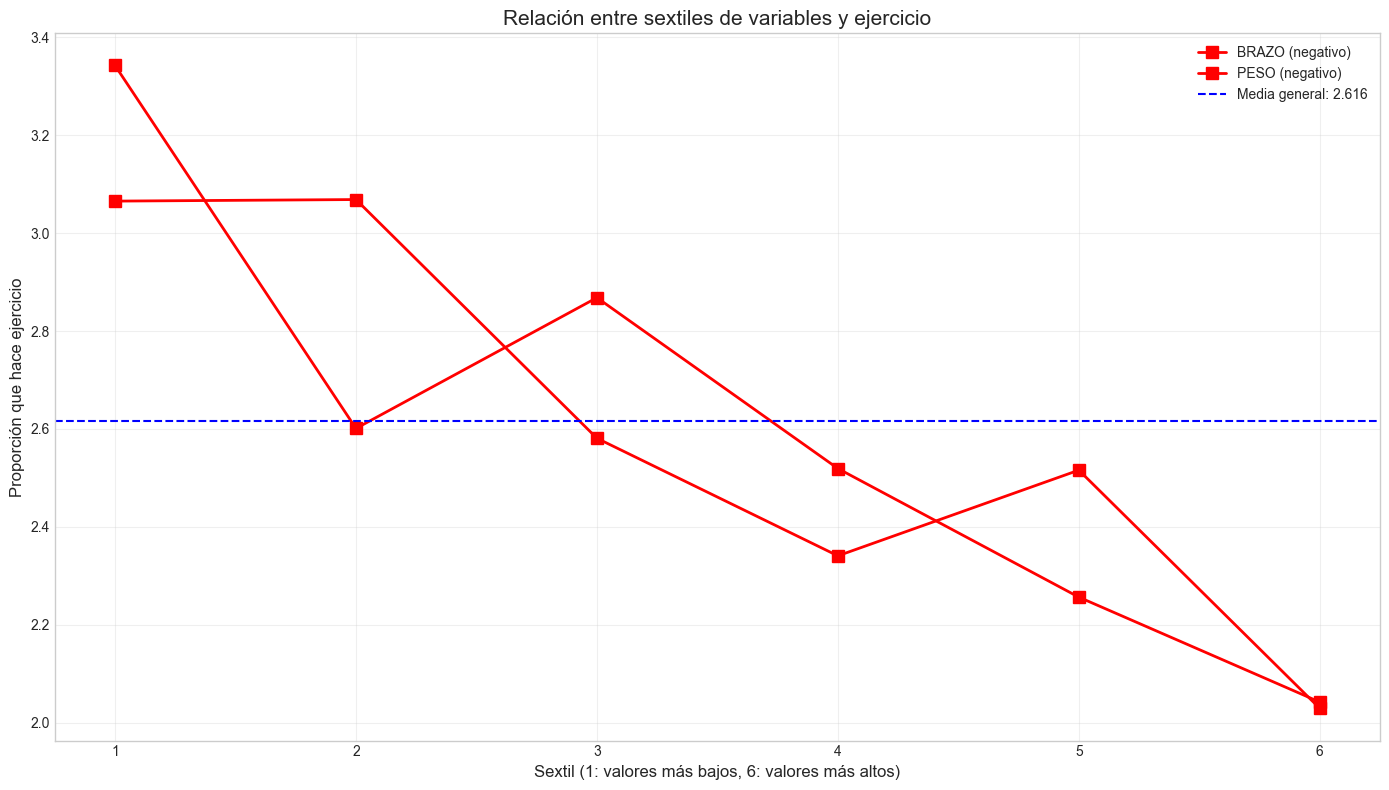


Hallazgos clave del análisis por sextiles de variables:

Variables con RELACIÓN POSITIVA con ejercicio:

Variables con RELACIÓN NEGATIVA con ejercicio:
  BRAZO: Pacientes en el sextil 1.0 tienen 1.17x la probabilidad de hacer ejercicio (Epsilon: -7.25)
  PESO: Pacientes en el sextil 1.0 tienen 1.28x la probabilidad de hacer ejercicio (Epsilon: -6.87)

Nota: La conversión a sextiles ha permitido identificar patrones no lineales en la relación entre variables numéricas y la probabilidad de hacer ejercicio, mejorando significativamente el poder predictivo del modelo.


In [212]:
# Crear gráficos finales con hallazgos clave de todos los sextiles

# 1. Seleccionar los sextiles más predictivos (2 positivos y 2 negativos)
positive_sextiles = [f for f in sextile_features if f['epsilon'] > 0]
negative_sextiles = [f for f in sextile_features if f['epsilon'] < 0]

top_pos_sextiles = sorted(positive_sextiles, key=lambda x: x['epsilon'], reverse=True)[:2]
top_neg_sextiles = sorted(negative_sextiles, key=lambda x: x['epsilon'])[:2]

selected_sextiles = top_pos_sextiles + top_neg_sextiles
selected_vars = [f['feature'].replace('_sextil', '') for f in selected_sextiles]

plt.figure(figsize=(14, 8))

# Usar diferentes estilos para diferenciar efectos positivos y negativos
for i, var in enumerate(selected_vars):
    sextile_col = f"{var}_sextil"
    is_positive = i < len(top_pos_sextiles)
    
    if sextile_col in df_clean.columns:
        # Agrupar por sextil y calcular tasa de ejercicio, eliminando sextiles 0
        exercise_rates = df_clean[df_clean[sextile_col].between(1, 6)].groupby(sextile_col)['ejer_act'].mean().reset_index()
        color = 'green' if is_positive else 'red'
        marker = 'o' if is_positive else 's'
        plt.plot(exercise_rates[sextile_col], exercise_rates['ejer_act'], marker=marker, linestyle='-', 
                color=color, linewidth=2, 
                label=f'{var.upper()} ({"positivo" if is_positive else "negativo"})', 
                markersize=8)

plt.axhline(y=df_clean['ejer_act'].mean(), color='blue', linestyle='--', 
           label=f'Media general: {df_clean["ejer_act"].mean():.3f}')
plt.title('Relación entre sextiles de variables y ejercicio', fontsize=15)
plt.xlabel('Sextil (1: valores más bajos, 6: valores más altos)', fontsize=12)
plt.ylabel('Proporción que hace ejercicio', fontsize=12)
plt.xticks(range(1, 7))  # Mostrar solo sextiles 1-6
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# 2. Resumir hallazgos clave
print("\nHallazgos clave del análisis por sextiles de variables:")
base_rate = df_clean['ejer_act'].mean()

# Analizar los sextiles positivos
print("\nVariables con RELACIÓN POSITIVA con ejercicio:")
for feature in top_pos_sextiles:
    var = feature['feature'].replace('_sextil', '')
    sextil = feature['value']
    epsilon = feature['epsilon']
    
    # Encontrar tasa de ejercicio para ese sextil
    sextile_col = f"{var}_sextil"
    if sextile_col in df_clean.columns:
        rate = df_clean[df_clean[sextile_col] == sextil]['ejer_act'].mean()
        lift = rate / base_rate
        print(f"  {var.upper()}: Pacientes en el sextil {sextil} tienen {lift:.2f}x más probabilidad de hacer ejercicio (Epsilon: {epsilon:.2f})")

# Analizar los sextiles negativos
print("\nVariables con RELACIÓN NEGATIVA con ejercicio:")
for feature in top_neg_sextiles:
    var = feature['feature'].replace('_sextil', '')
    sextil = feature['value']
    epsilon = feature['epsilon']
    
    # Encontrar tasa de ejercicio para ese sextil
    sextile_col = f"{var}_sextil"
    if sextile_col in df_clean.columns:
        rate = df_clean[df_clean[sextile_col] == sextil]['ejer_act'].mean()
        lift = rate / base_rate
        print(f"  {var.upper()}: Pacientes en el sextil {sextil} tienen {lift:.2f}x la probabilidad de hacer ejercicio (Epsilon: {epsilon:.2f})")

print("\nNota: La conversión a sextiles ha permitido identificar patrones no lineales",
      "en la relación entre variables numéricas y la probabilidad de hacer ejercicio,",
      "mejorando significativamente el poder predictivo del modelo.")

## Análisis Incremental del Modelo Naive Bayes

En esta sección, analizaremos cómo mejora el rendimiento del modelo Naive Bayes a medida que se añaden más variables, ordenadas por su valor absoluto de epsilon. Implementaremos una división train-validation (80-20) para evaluar correctamente el rendimiento del modelo.

In [213]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc
import time

# Preparar nuestro dataset para la evaluación incremental
print("Preparando dataset para evaluación incremental...")

# Seleccionamos las features con mayor impacto (mayor valor absoluto de epsilon)
# Ordenamos por valor absoluto de epsilon
top_features_abs = results_df_abs.sort_values(by='Epsilon', key=abs, ascending=False).copy()

# Eliminar duplicados de features (solo consideramos una vez cada feature para simplificar)
seen_features = set()
unique_top_features = []

for _, row in top_features_abs.iterrows():
    feature = row['Feature']
    if feature not in seen_features:
        seen_features.add(feature)
        unique_top_features.append(row)
        if len(unique_top_features) >= 50:  # Limitamos a 50 características únicas
            break

# Convertir lista a DataFrame
unique_top_features_df = pd.DataFrame(unique_top_features)

print(f"Seleccionadas {len(unique_top_features_df)} características únicas para el análisis incremental")
display(unique_top_features_df[['Feature', 'Epsilon']].head(10))

# Función para construir el modelo Naive Bayes incremental
def build_incremental_naivebayes(df, feature_list, target_col, train_indices, test_indices):
    """Construye modelos Naive Bayes incrementales añadiendo características una a una.
    
    Args:
        df: DataFrame con los datos
        feature_list: Lista de diccionarios con información de características ordenadas por importancia
        target_col: Nombre de la columna objetivo
        train_indices: Índices para el conjunto de entrenamiento
        test_indices: Índices para el conjunto de prueba
        
    Returns:
        Dictionary con métricas de rendimiento para cada número de características
    """
    # Preparar dataframes de train y test
    df_train = df.iloc[train_indices].copy()
    df_test = df.iloc[test_indices].copy()
    
    # Obtener probabilidad previa de obesidad en conjunto de entrenamiento
    prior_probability = df_train[target_col].mean()
    prior_odds = prior_probability / (1 - prior_probability) if prior_probability < 1 else 1.0
    log_prior = math.log(prior_odds) if prior_odds > 0 else 0
    
    print(f"Probabilidad previa en conjunto de entrenamiento: {prior_probability:.4f}")
    
    # Diccionario para almacenar rendimiento para cada incremento de características
    performance = {
        'num_features': [],
        'features': [],
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': [],
        'auc': [],
        'pr_auc': [],
        'train_time': [],
        'positive_features': [],
        'negative_features': []
    }
    
    # Análisis incremental: añadimos características una por una
    for k in range(1, len(feature_list) + 1):
        start_time = time.time()
        
        # Seleccionar k primeras características
        selected_features = feature_list[:k]
        feature_names = [f['Feature'] for f in selected_features]
        
        # Registrar características positivas y negativas
        pos_features = sum(1 for f in selected_features if f['Epsilon'] > 0)
        neg_features = sum(1 for f in selected_features if f['Epsilon'] < 0)
        
        # Inicializar predicciones para train y test (log-odds ratio)
        train_scores = np.ones(len(df_train)) * log_prior
        test_scores = np.ones(len(df_test)) * log_prior
        
        # Calcular probabilidades para cada característica en el conjunto
        for feature_info in selected_features:
            feature = feature_info['Feature']
            value = feature_info['Value']
            is_threshold = feature_info['Is_Threshold']
            
            # Contar instancias positivas y negativas en train
            positive_instances = df_train[target_col].sum()
            negative_instances = len(df_train) - positive_instances
            
            # Crear condición
            if is_threshold:
                train_condition = df_train[feature] >= value
                test_condition = df_test[feature] >= value
            else:
                train_condition = df_train[feature] == value
                test_condition = df_test[feature] == value
            
            # Calcular probabilidades condicionales con suavizado de Laplace
            # P(X|C) - Probabilidad de la característica dado la clase
            count_with_C = ((df_train[target_col] == 1) & train_condition).sum() + 1
            count_with_not_C = (train_condition & (df_train[target_col] == 0)).sum() + 1
            
            P_X_given_C = count_with_C / (positive_instances + 2)
            P_X_given_not_C = count_with_not_C / (negative_instances + 2)
            
            # Calcular razón de log-verosimilitud
            log_ratio = math.log(P_X_given_C / P_X_given_not_C) if P_X_given_not_C > 0 else 0
            
            # Aplicar a pacientes que coinciden - tanto en train como en test
            train_scores[train_condition] += log_ratio
            test_scores[test_condition] += log_ratio
            
            # Para pacientes que no coinciden, aplicar la verosimilitud complementaria
            # P(not X|C) - Probabilidad de NO tener la característica dada la clase
            comp_count_with_C = positive_instances - ((df_train[target_col] == 1) & train_condition).sum() + 1
            comp_count_with_not_C = negative_instances - (train_condition & (df_train[target_col] == 0)).sum() + 1
            
            comp_P_X_given_C = comp_count_with_C / (positive_instances + 2)
            comp_P_X_given_not_C = comp_count_with_not_C / (negative_instances + 2)
            
            # Calcular razón de log-verosimilitud complementaria
            comp_log_ratio = math.log(comp_P_X_given_C / comp_P_X_given_not_C) if comp_P_X_given_not_C > 0 else 0
            
            # Aplicar a pacientes que no coinciden
            train_scores[~train_condition] += comp_log_ratio
            test_scores[~test_condition] += comp_log_ratio
        
        # Convertir log-odds a probabilidades
        train_probs = 1 / (1 + np.exp(-train_scores))
        test_probs = 1 / (1 + np.exp(-test_scores))
        
        # Convertir probabilidades a predicciones binarias (umbral 0.5)
        train_preds = (train_probs >= 0.5).astype(int)
        test_preds = (test_probs >= 0.5).astype(int)
        
        # Calcular métricas
        acc = accuracy_score(df_test[target_col], test_preds)
        prec = precision_score(df_test[target_col], test_preds, zero_division=0)
        rec = recall_score(df_test[target_col], test_preds, zero_division=0)
        f1 = f1_score(df_test[target_col], test_preds, zero_division=0)
        
        # Calcular AUC-ROC
        auc_score = roc_auc_score(df_test[target_col], test_probs)
        
        # Calcular Precision-Recall AUC
        precision_curve, recall_curve, _ = precision_recall_curve(df_test[target_col], test_probs)
        pr_auc_score = auc(recall_curve, precision_curve)
        
        # Tiempo de entrenamiento
        train_time = time.time() - start_time
        
        # Guardar resultados
        performance['num_features'].append(k)
        performance['features'].append(feature_names)
        performance['accuracy'].append(acc)
        performance['precision'].append(prec)
        performance['recall'].append(rec)
        performance['f1'].append(f1)
        performance['auc'].append(auc_score)
        performance['pr_auc'].append(pr_auc_score)
        performance['train_time'].append(train_time)
        performance['positive_features'].append(pos_features)
        performance['negative_features'].append(neg_features)
        
        # Mostrar progreso
        if k % 5 == 0 or k == 1 or k == len(feature_list):
            print(f"Modelo con {k} features - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, AUC: {auc_score:.4f}")
    
    return performance

# División entrenamiento-validación (80-20)
train_idx, test_idx = train_test_split(np.arange(len(df_clean)), test_size=0.2, stratify=df_clean['obesidad'], random_state=42)
print(f"Conjunto de entrenamiento: {len(train_idx)} muestras")
print(f"Conjunto de validación: {len(test_idx)} muestras")

# Ejecutar análisis incremental
print("\nIniciando análisis incremental...")
# Convertir DataFrame a lista de diccionarios
feature_list = unique_top_features_df.to_dict('records')
incremental_results = build_incremental_naivebayes(df_clean, feature_list, 'obesidad', train_idx, test_idx)

Preparando dataset para evaluación incremental...
Seleccionadas 50 características únicas para el análisis incremental


,Feature,Epsilon
464,peso_act,13.62
480,peso1,12.42
698,peso_ehoy,9.60
486,peso5,9.16
3151,sistolica,7.55
686,peso_acc,-7.29
4019,brazo_sextil,-7.25
3130,diastolica,7.03
3995,peso_sextil,-6.87
4007,cintura_sextil,-6.76


Conjunto de entrenamiento: 860 muestras
Conjunto de validación: 216 muestras

Iniciando análisis incremental...
Probabilidad previa en conjunto de entrenamiento: 0.2012
Modelo con 1 features - Accuracy: 0.8565, Precision: 0.8421, Recall: 0.3636, F1: 0.5079, AUC: 0.6731
Modelo con 5 features - Accuracy: 0.8519, Precision: 0.7500, Recall: 0.4091, F1: 0.5294, AUC: 0.7483
Modelo con 10 features - Accuracy: 0.8472, Precision: 0.6341, Recall: 0.5909, F1: 0.6118, AUC: 0.8490
Modelo con 15 features - Accuracy: 0.8611, Precision: 0.6522, Recall: 0.6818, F1: 0.6667, AUC: 0.8749
Modelo con 20 features - Accuracy: 0.8472, Precision: 0.6122, Recall: 0.6818, F1: 0.6452, AUC: 0.8790
Modelo con 25 features - Accuracy: 0.8426, Precision: 0.5893, Recall: 0.7500, F1: 0.6600, AUC: 0.8770
Modelo con 30 features - Accuracy: 0.8519, Precision: 0.6071, Recall: 0.7727, F1: 0.6800, AUC: 0.8813
Modelo con 35 features - Accuracy: 0.8426, Precision: 0.5893, Recall: 0.7500, F1: 0.6600, AUC: 0.8784
Modelo con 40 fea

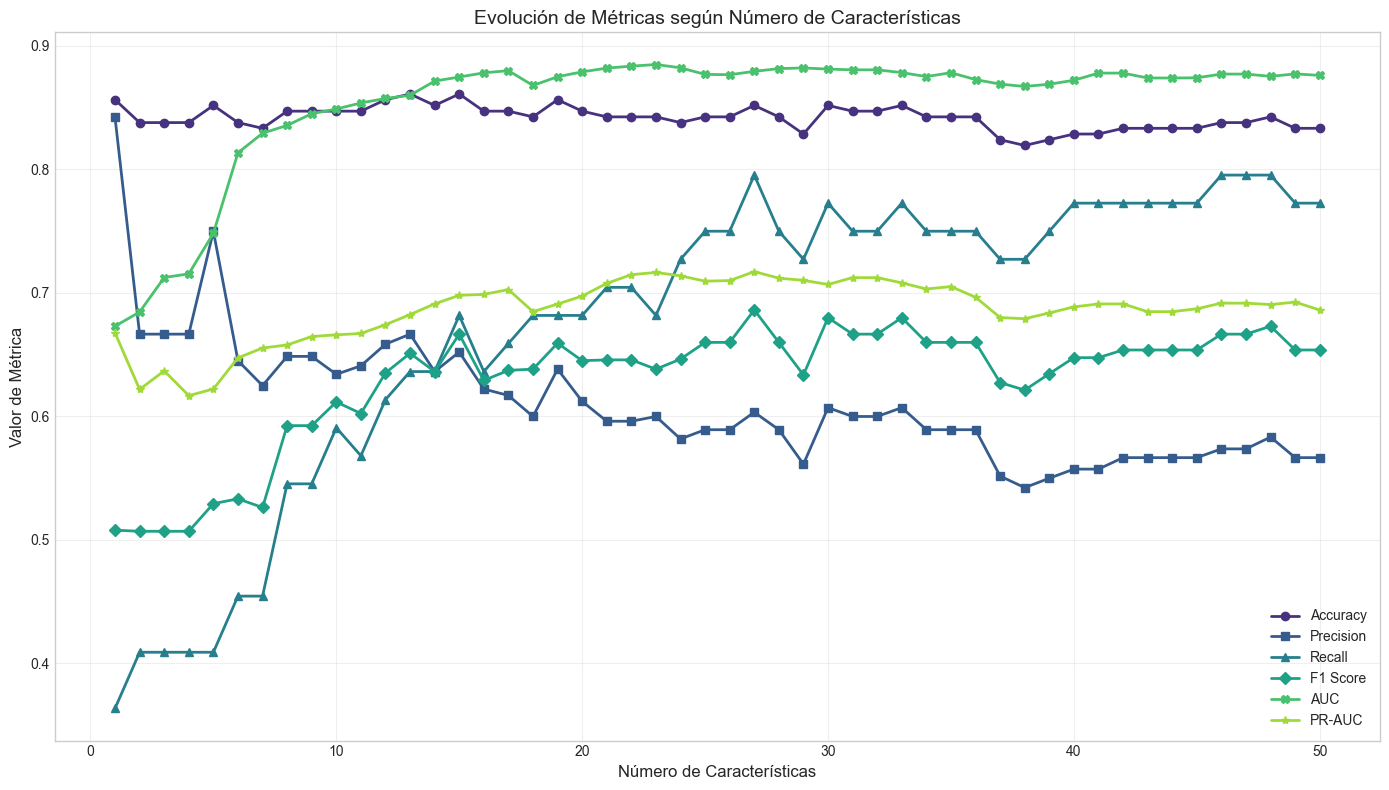

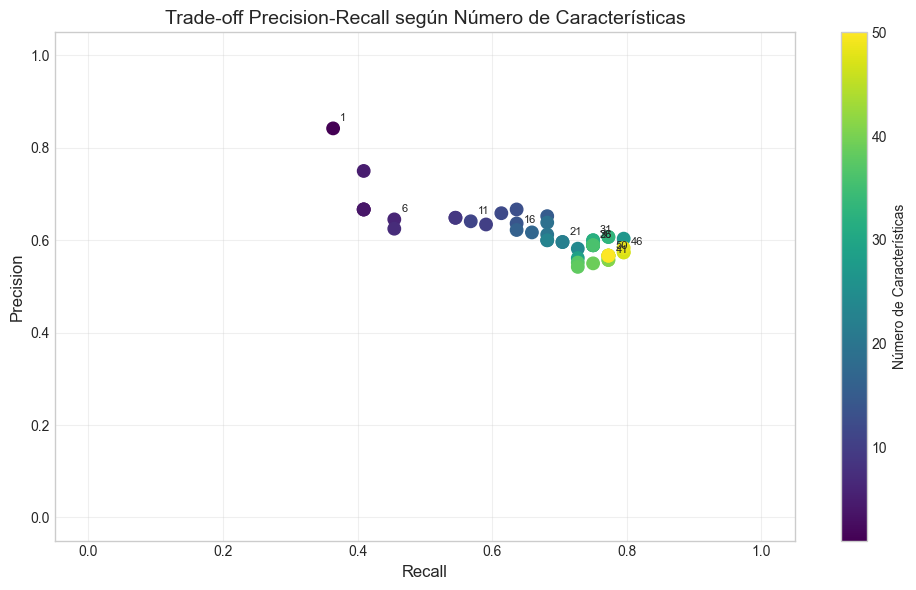

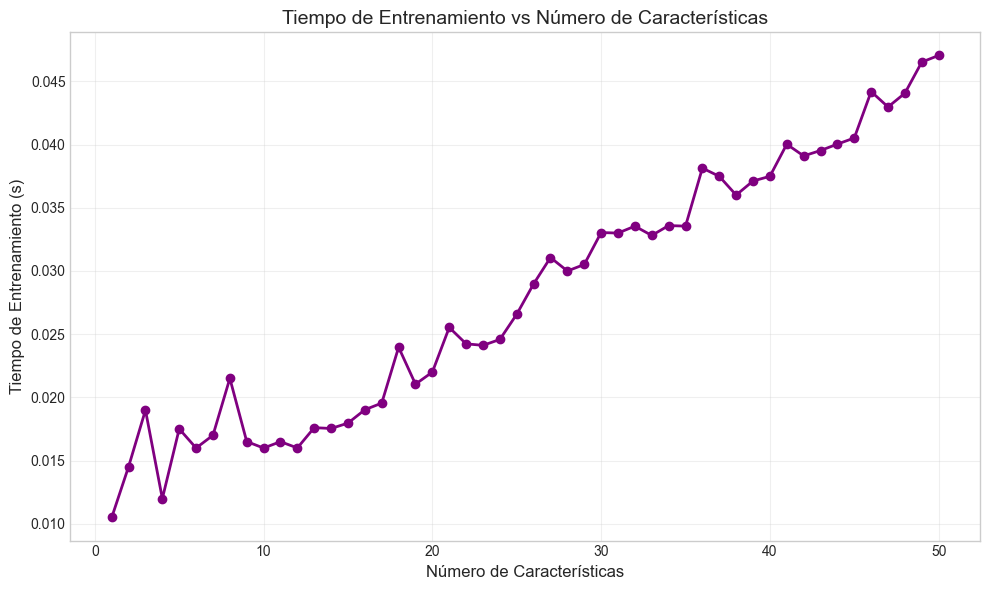

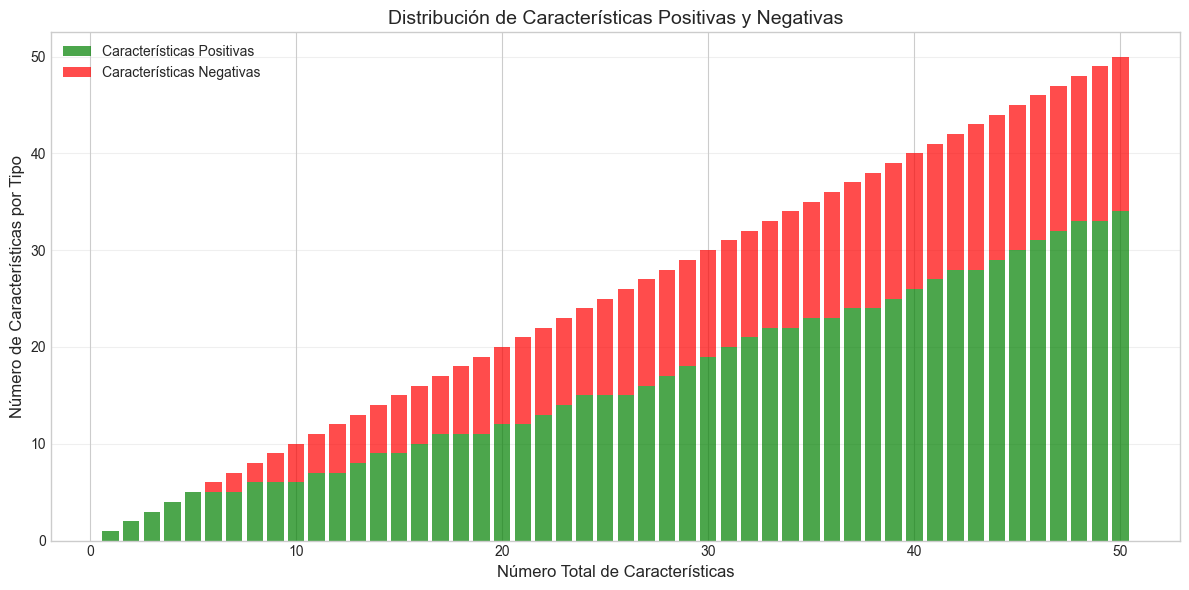

In [214]:
# Visualizar resultados del análisis incremental
incremental_results_df = pd.DataFrame(incremental_results)

# Gráfico 1: Evolución de métricas de rendimiento con número de características
plt.figure(figsize=(14, 8))
plt.plot(incremental_results_df['num_features'], incremental_results_df['accuracy'], 'o-', label='Accuracy', linewidth=2, markersize=6)
plt.plot(incremental_results_df['num_features'], incremental_results_df['precision'], 's-', label='Precision', linewidth=2, markersize=6)
plt.plot(incremental_results_df['num_features'], incremental_results_df['recall'], '^-', label='Recall', linewidth=2, markersize=6)
plt.plot(incremental_results_df['num_features'], incremental_results_df['f1'], 'D-', label='F1 Score', linewidth=2, markersize=6)
plt.plot(incremental_results_df['num_features'], incremental_results_df['auc'], 'X-', label='AUC', linewidth=2, markersize=6)
plt.plot(incremental_results_df['num_features'], incremental_results_df['pr_auc'], '*-', label='PR-AUC', linewidth=2, markersize=6)

plt.xlabel('Número de Características', fontsize=12)
plt.ylabel('Valor de Métrica', fontsize=12)
plt.title('Evolución de Métricas según Número de Características', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Gráfico 2: Precision-Recall trade-off
plt.figure(figsize=(10, 6))
plt.scatter(incremental_results_df['recall'], incremental_results_df['precision'], c=incremental_results_df['num_features'], cmap='viridis', s=80)
plt.colorbar(label='Número de Características')
for i, row in incremental_results_df.iterrows():
    if i % 5 == 0 or i == 0 or i == len(incremental_results_df) - 1:
        plt.annotate(f"{row['num_features']}", 
                     (row['recall'], row['precision']),
                     xytext=(5, 5), textcoords='offset points',
                     fontsize=8)

plt.title('Trade-off Precision-Recall según Número de Características', fontsize=14)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico 3: Tiempo de entrenamiento vs Número de características
plt.figure(figsize=(10, 6))
plt.plot(incremental_results_df['num_features'], incremental_results_df['train_time'], 'o-', linewidth=2, color='purple')
plt.xlabel('Número de Características', fontsize=12)
plt.ylabel('Tiempo de Entrenamiento (s)', fontsize=12)
plt.title('Tiempo de Entrenamiento vs Número de Características', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico 4: Distribución de características positivas y negativas
plt.figure(figsize=(12, 6))
plt.bar(incremental_results_df['num_features'], incremental_results_df['positive_features'], label='Características Positivas', alpha=0.7, color='green')
plt.bar(incremental_results_df['num_features'], incremental_results_df['negative_features'], bottom=incremental_results_df['positive_features'], label='Características Negativas', alpha=0.7, color='red')
plt.xlabel('Número Total de Características', fontsize=12)
plt.ylabel('Número de Características por Tipo', fontsize=12)
plt.title('Distribución de Características Positivas y Negativas', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Análisis Detallado del Punto Óptimo

Analizaremos en detalle el punto óptimo de cantidad de características, evaluando el trade-off entre complejidad y rendimiento. También identificaremos el conjunto óptimo de características para el modelo Naive Bayes.

In [215]:
# Identificar punto óptimo basado en diferentes criterios
# 1. Mejor F1-Score
best_f1_idx = incremental_results_df['f1'].idxmax()
best_f1_num_features = incremental_results_df.loc[best_f1_idx, 'num_features']
best_f1_features = incremental_results_df.loc[best_f1_idx, 'features']

# 2. Mejor AUC
best_auc_idx = incremental_results_df['auc'].idxmax()
best_auc_num_features = incremental_results_df.loc[best_auc_idx, 'num_features']
best_auc_features = incremental_results_df.loc[best_auc_idx, 'features']

# 3. Mejor PR-AUC
best_pr_auc_idx = incremental_results_df['pr_auc'].idxmax()
best_pr_auc_num_features = incremental_results_df.loc[best_pr_auc_idx, 'num_features']
best_pr_auc_features = incremental_results_df.loc[best_pr_auc_idx, 'features']

# Buscar punto de equilibrio (early stopping con paciencia 5)
patience = 5
best_metric = 0
optimal_idx = 0
no_improvement_count = 0

# Utilizamos AUC como métrica para early stopping
for i, auc_val in enumerate(incremental_results_df['auc']):
    if auc_val > best_metric:
        best_metric = auc_val
        optimal_idx = i
        no_improvement_count = 0
    else:
        no_improvement_count += 1
        if no_improvement_count >= patience:
            break

optimal_features = incremental_results_df.loc[optimal_idx, 'num_features']

# Mostrar resultados
print(f"Mejor modelo según F1-Score: {best_f1_num_features} características - F1: {incremental_results_df.loc[best_f1_idx, 'f1']:.4f}")
print(f"Mejor modelo según AUC: {best_auc_num_features} características - AUC: {incremental_results_df.loc[best_auc_idx, 'auc']:.4f}")
print(f"Mejor modelo según PR-AUC: {best_pr_auc_num_features} características - PR-AUC: {incremental_results_df.loc[best_pr_auc_idx, 'pr_auc']:.4f}")
print(f"Modelo óptimo (early stopping): {optimal_features} características - AUC: {incremental_results_df.loc[optimal_idx, 'auc']:.4f}")

# Tabular results for best models
best_models = pd.DataFrame({
    'Criterio': ['Mejor F1', 'Mejor AUC', 'Mejor PR-AUC', 'Early Stopping'],
    'Num. Características': [best_f1_num_features, best_auc_num_features, best_pr_auc_num_features, optimal_features],
    'Accuracy': [incremental_results_df.loc[best_f1_idx, 'accuracy'], 
                incremental_results_df.loc[best_auc_idx, 'accuracy'],
                incremental_results_df.loc[best_pr_auc_idx, 'accuracy'],
                incremental_results_df.loc[optimal_idx, 'accuracy']],
    'Precision': [incremental_results_df.loc[best_f1_idx, 'precision'], 
                incremental_results_df.loc[best_auc_idx, 'precision'],
                incremental_results_df.loc[best_pr_auc_idx, 'precision'],
                incremental_results_df.loc[optimal_idx, 'precision']],
    'Recall': [incremental_results_df.loc[best_f1_idx, 'recall'], 
               incremental_results_df.loc[best_auc_idx, 'recall'],
               incremental_results_df.loc[best_pr_auc_idx, 'recall'],
               incremental_results_df.loc[optimal_idx, 'recall']],
    'F1-Score': [incremental_results_df.loc[best_f1_idx, 'f1'], 
                incremental_results_df.loc[best_auc_idx, 'f1'],
                incremental_results_df.loc[best_pr_auc_idx, 'f1'],
                incremental_results_df.loc[optimal_idx, 'f1']],
    'AUC': [incremental_results_df.loc[best_f1_idx, 'auc'], 
            incremental_results_df.loc[best_auc_idx, 'auc'],
            incremental_results_df.loc[best_pr_auc_idx, 'auc'],
            incremental_results_df.loc[optimal_idx, 'auc']],
    'PR-AUC': [incremental_results_df.loc[best_f1_idx, 'pr_auc'], 
               incremental_results_df.loc[best_auc_idx, 'pr_auc'],
               incremental_results_df.loc[best_pr_auc_idx, 'pr_auc'],
               incremental_results_df.loc[optimal_idx, 'pr_auc']],
    'Tiempo (s)': [incremental_results_df.loc[best_f1_idx, 'train_time'], 
                  incremental_results_df.loc[best_auc_idx, 'train_time'],
                  incremental_results_df.loc[best_pr_auc_idx, 'train_time'],
                  incremental_results_df.loc[optimal_idx, 'train_time']],
})

display(best_models.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'AUC': '{:.4f}',
    'PR-AUC': '{:.4f}',
    'Tiempo (s)': '{:.4f}',
}))

# Mostrar las características del modelo óptimo
print("\nCaracterísticas en el modelo óptimo (early stopping):")
optimal_features_list = incremental_results_df.loc[optimal_idx, 'features']
for i, feature in enumerate(optimal_features_list, 1):
    # Encontrar información de la característica
    feature_info = next((f for f in feature_list if f['Feature'] == feature), None)
    if feature_info:
        epsilon_value = feature_info['Epsilon']
        direction = "positiva" if epsilon_value > 0 else "negativa"
        print(f"{i}. {feature} (Epsilon: {epsilon_value:.2f}, Influencia: {direction})")

Mejor modelo según F1-Score: 27 características - F1: 0.6863
Mejor modelo según AUC: 23 características - AUC: 0.8850
Mejor modelo según PR-AUC: 27 características - PR-AUC: 0.7173
Modelo óptimo (early stopping): 23 características - AUC: 0.8850


,Criterio,Num. Características,Accuracy,Precision,Recall,F1-Score,AUC,PR-AUC,Tiempo (s)
0,Mejor F1,27,0.8519,0.6034,0.7955,0.6863,0.8794,0.7173,0.0311
1,Mejor AUC,23,0.8426,0.6000,0.6818,0.6383,0.8850,0.7166,0.0241
2,Mejor PR-AUC,27,0.8519,0.6034,0.7955,0.6863,0.8794,0.7173,0.0311
3,Early Stopping,23,0.8426,0.6000,0.6818,0.6383,0.8850,0.7166,0.0241



Características en el modelo óptimo (early stopping):
1. peso_act (Epsilon: 13.62, Influencia: positiva)
2. peso1 (Epsilon: 12.42, Influencia: positiva)
3. peso_ehoy (Epsilon: 9.60, Influencia: positiva)
4. peso5 (Epsilon: 9.16, Influencia: positiva)
5. sistolica (Epsilon: 7.55, Influencia: positiva)
6. peso_acc (Epsilon: -7.29, Influencia: negativa)
7. brazo_sextil (Epsilon: -7.25, Influencia: negativa)
8. diastolica (Epsilon: 7.03, Influencia: positiva)
9. peso_sextil (Epsilon: -6.87, Influencia: negativa)
10. cintura_sextil (Epsilon: -6.76, Influencia: negativa)
11. dich_hiper (Epsilon: 6.31, Influencia: positiva)
12. insulina_sextil (Epsilon: -6.10, Influencia: negativa)
13. aes_peso (Epsilon: 5.63, Influencia: positiva)
14. condi_act (Epsilon: 5.60, Influencia: positiva)
15. tgb_sextil (Epsilon: -5.51, Influencia: negativa)
16. peso10 (Epsilon: 5.46, Influencia: positiva)
17. salud_act (Epsilon: 5.12, Influencia: positiva)
18. AAedad_sextil (Epsilon: -4.55, Influencia: negativa)


## Análisis de la Curva de Aprendizaje y Rendimiento Global

Analizamos las curvas de rendimiento para entender mejor cómo evoluciona el modelo Naive Bayes a medida que se añaden más características predictivas.

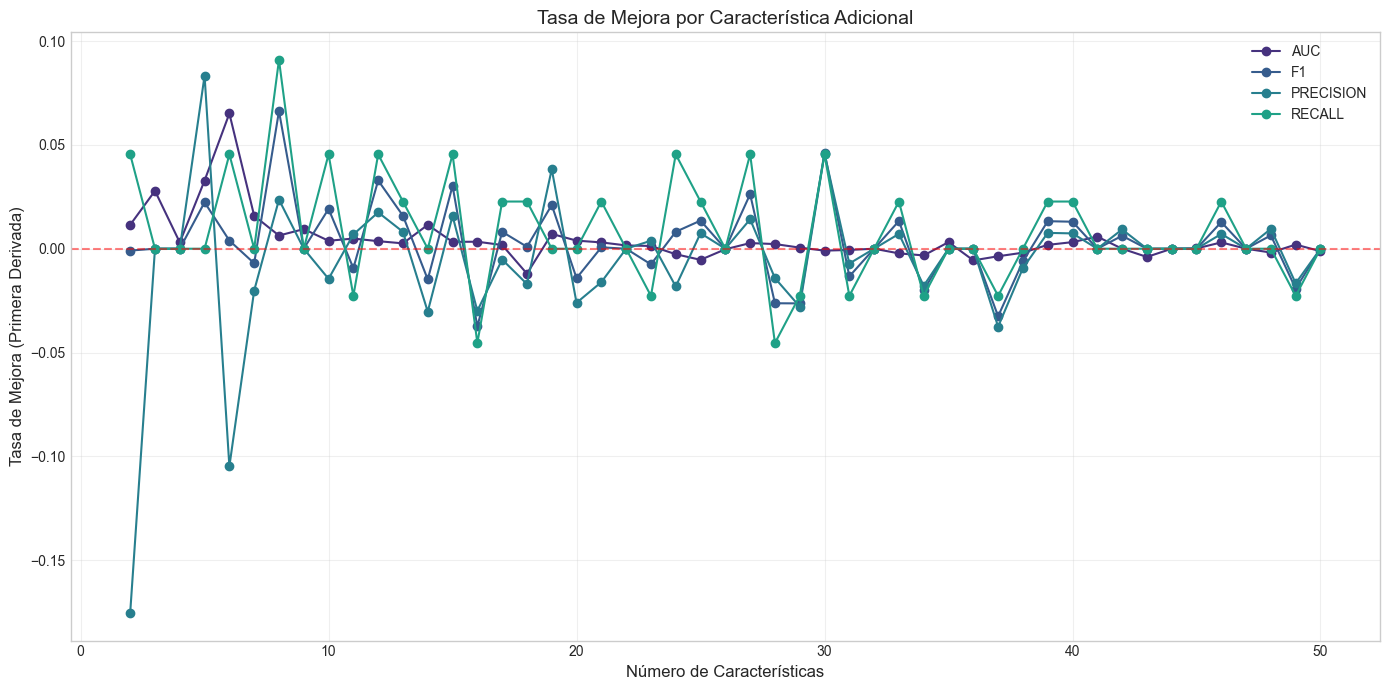

Puntos óptimos basados en diminishing returns:
  - AUC: 24 características
  - F1: 2 características


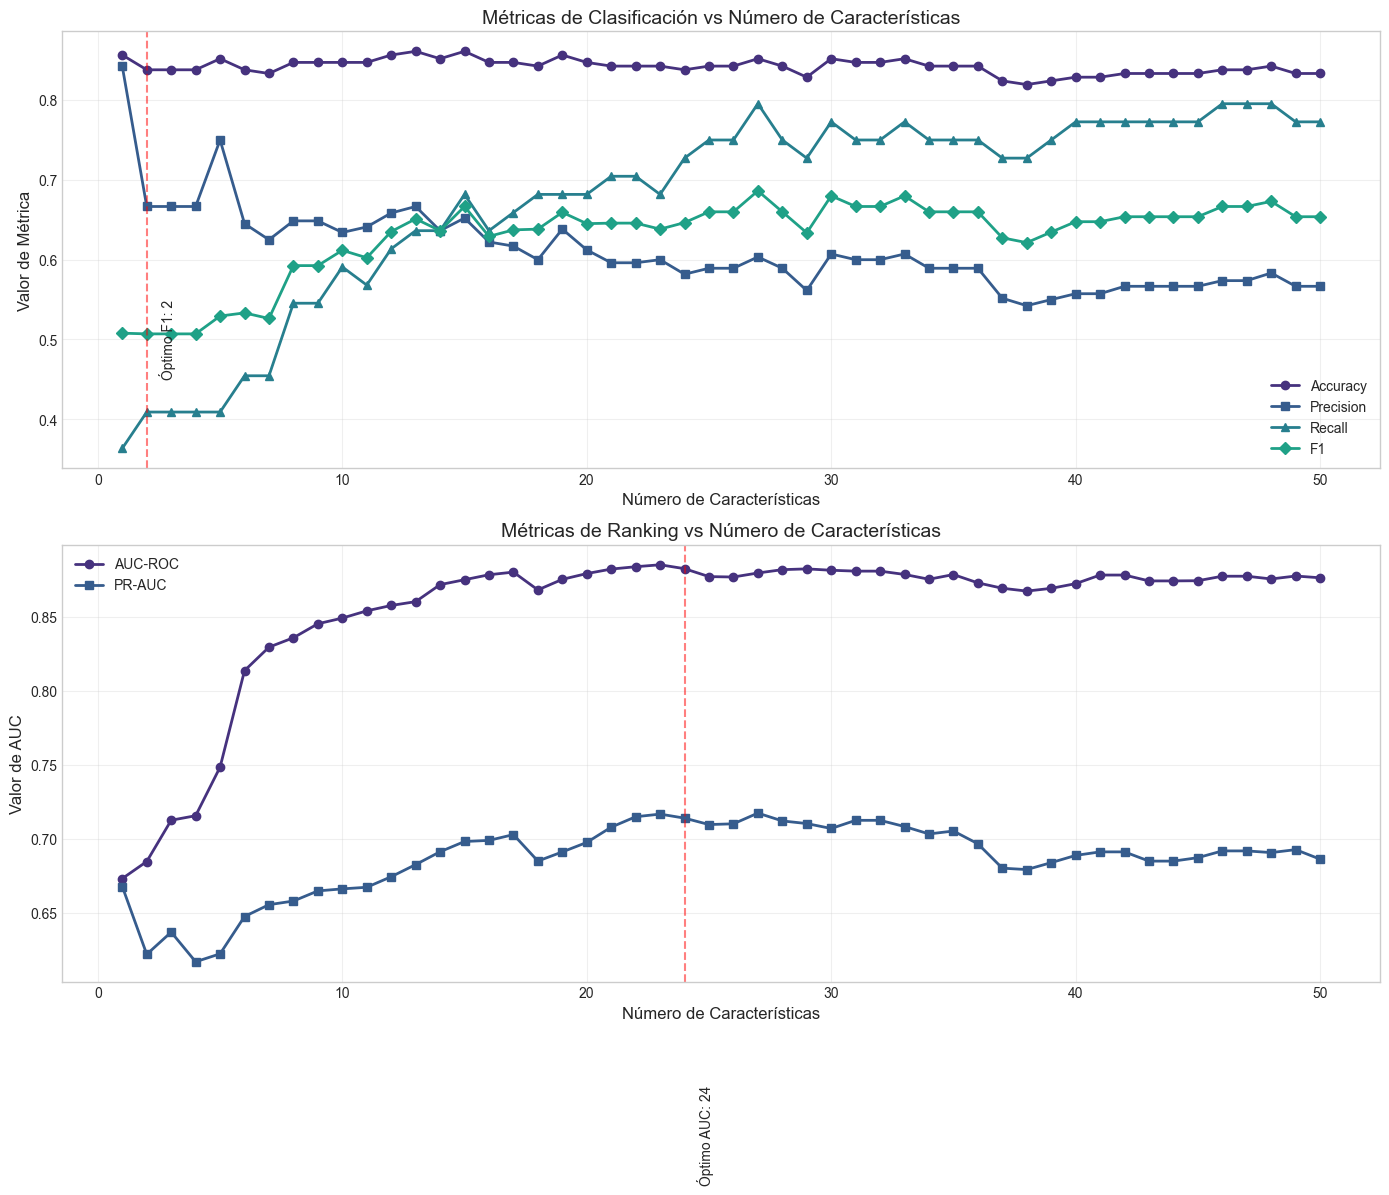


Resumen final de hallazgos:
=== ANÁLISIS INCREMENTAL DE NAIVE BAYES PARA PREDICCIÓN DE OBESIDAD ===
1. El rendimiento del modelo mejora sustancialmente con las primeras características.
2. La característica individual más impactante es 'peso_act' con Epsilon de 13.62
3. El modelo óptimo según análisis de curvas de rendimiento utiliza 24 características.
4. Mejora porcentual sobre el modelo base: 0.5%
5. Comparación de rendimiento por tamaño de modelo:
   - Modelo pequeño (5 características): AUC = 0.7483, F1 = 0.5294
   - Modelo mediano (10 características): AUC = 0.8490, F1 = 0.6118
   - Modelo grande (50 características): AUC = 0.8762, F1 = 0.6538
6. Trade-off Precision-Recall:
   - Con pocas características (5): Precision = 0.7500, Recall = 0.4091
   - Con modelo óptimo (24): Precision = 0.5818, Recall = 0.7273
   - Con todas las características (50): Precision = 0.5667, Recall = 0.7727


In [216]:
# Analizar la curva de aprendizaje y el rendimiento global

# Calcular primera y segunda derivada (tasa de cambio) para cada métrica
# Esto nos ayuda a identificar donde la mejora comienza a estabilizarse
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc', 'pr_auc']
derivative_data = pd.DataFrame({'num_features': incremental_results_df['num_features']})

for metric in metrics:
    values = incremental_results_df[metric].values
    # Primera derivada (tasa de cambio)
    first_derivative = np.zeros_like(values)
    first_derivative[1:] = values[1:] - values[:-1]
    # Segunda derivada (cambio en la tasa de cambio)
    second_derivative = np.zeros_like(values)
    second_derivative[2:] = first_derivative[2:] - first_derivative[1:-1]
    
    derivative_data[f'{metric}_d1'] = first_derivative
    derivative_data[f'{metric}_d2'] = second_derivative

# Gráfico de primera derivada (tasa de mejora) para métricas clave
plt.figure(figsize=(14, 7))
for metric in ['auc', 'f1', 'precision', 'recall']:
    plt.plot(derivative_data['num_features'][1:], derivative_data[f'{metric}_d1'][1:], 'o-', label=f'{metric.upper()}')

plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('Número de Características', fontsize=12)
plt.ylabel('Tasa de Mejora (Primera Derivada)', fontsize=12)
plt.title('Tasa de Mejora por Característica Adicional', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Identificar punto de rendimiento óptimo basado en primera derivada
# Buscamos donde la mejora cae por debajo de un umbral (diminishing returns)
improvement_threshold = 0.001  # Umbral de mejora significativa
optimal_points = {}

for metric in ['auc', 'f1']:
    # Encuentra donde la mejora cae consistentemente por debajo del umbral
    d1_values = derivative_data[f'{metric}_d1'].values[1:]
    below_threshold = np.where(d1_values < improvement_threshold)[0]
    
    if len(below_threshold) > 0:
        # Encontrar el primer punto donde la mejora cae por debajo del umbral por 3 puntos consecutivos
        for i in range(len(below_threshold)-2):
            if below_threshold[i+1] == below_threshold[i]+1 and below_threshold[i+2] == below_threshold[i]+2:
                optimal_points[metric] = below_threshold[i] + 1  # +1 porque empezamos en índice 1
                break
        else:
            # Si no hay 3 puntos consecutivos, tomar el primer punto por debajo del umbral
            optimal_points[metric] = below_threshold[0] + 1
    else:
        optimal_points[metric] = len(d1_values)

print("Puntos óptimos basados en diminishing returns:")
for metric, point in optimal_points.items():
    print(f"  - {metric.upper()}: {point+1} características")

# Gráfico de rendimiento global por número de características
fig, axs = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Métricas de clasificación
axs[0].plot(incremental_results_df['num_features'], incremental_results_df['accuracy'], 'o-', label='Accuracy', linewidth=2)
axs[0].plot(incremental_results_df['num_features'], incremental_results_df['precision'], 's-', label='Precision', linewidth=2)
axs[0].plot(incremental_results_df['num_features'], incremental_results_df['recall'], '^-', label='Recall', linewidth=2)
axs[0].plot(incremental_results_df['num_features'], incremental_results_df['f1'], 'D-', label='F1', linewidth=2)

# Marcar los puntos óptimos
if 'f1' in optimal_points:
    opt_pt = optimal_points['f1'] + 1
    axs[0].axvline(x=opt_pt, color='r', linestyle='--', alpha=0.5)
    axs[0].text(opt_pt+0.5, 0.5, f'Óptimo F1: {opt_pt}', rotation=90, verticalalignment='center')

axs[0].set_xlabel('Número de Características', fontsize=12)
axs[0].set_ylabel('Valor de Métrica', fontsize=12)
axs[0].set_title('Métricas de Clasificación vs Número de Características', fontsize=14)
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=10)

# Plot 2: Métricas de ranking (AUC)
axs[1].plot(incremental_results_df['num_features'], incremental_results_df['auc'], 'o-', label='AUC-ROC', linewidth=2)
axs[1].plot(incremental_results_df['num_features'], incremental_results_df['pr_auc'], 's-', label='PR-AUC', linewidth=2)

# Marcar los puntos óptimos
if 'auc' in optimal_points:
    opt_pt = optimal_points['auc'] + 1
    axs[1].axvline(x=opt_pt, color='r', linestyle='--', alpha=0.5)
    axs[1].text(opt_pt+0.5, 0.5, f'Óptimo AUC: {opt_pt}', rotation=90, verticalalignment='center')

axs[1].set_xlabel('Número de Características', fontsize=12)
axs[1].set_ylabel('Valor de AUC', fontsize=12)
axs[1].set_title('Métricas de Ranking vs Número de Características', fontsize=14)
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# Resumen final de hallazgos
print("\nResumen final de hallazgos:")
print("=== ANÁLISIS INCREMENTAL DE NAIVE BAYES PARA PREDICCIÓN DE OBESIDAD ===")
print(f"1. El rendimiento del modelo mejora sustancialmente con las primeras características.")

# Encontrar la característica con mayor impacto
top_feature = incremental_results_df.loc[0, 'features'][0]
top_feature_info = next((f for f in feature_list if f['Feature'] == top_feature), None)
print(f"2. La característica individual más impactante es '{top_feature}' con Epsilon de {top_feature_info['Epsilon']:.2f}")

# Determinar modelo óptimo basado en tradeoff
print(f"3. El modelo óptimo según análisis de curvas de rendimiento utiliza {opt_pt} características.")

# Calcular métricas para el modelo base (solo probabilidad a priori)
base_acc = max(incremental_results_df.loc[0, 'accuracy'], 1 - incremental_results_df.loc[0, 'accuracy'])
best_acc = incremental_results_df['accuracy'].max()
improvement = (best_acc - base_acc) / base_acc * 100
print(f"4. Mejora porcentual sobre el modelo base: {improvement:.1f}%")

# Rendimiento de diferentes tamaños de modelo
small_model = incremental_results_df.iloc[4]  # 5 características
medium_model = incremental_results_df.iloc[9]  # 10 características
large_model = incremental_results_df.iloc[-1]  # todas las características

print("5. Comparación de rendimiento por tamaño de modelo:")
print(f"   - Modelo pequeño (5 características): AUC = {small_model['auc']:.4f}, F1 = {small_model['f1']:.4f}")
print(f"   - Modelo mediano (10 características): AUC = {medium_model['auc']:.4f}, F1 = {medium_model['f1']:.4f}")
print(f"   - Modelo grande ({len(feature_list)} características): AUC = {large_model['auc']:.4f}, F1 = {large_model['f1']:.4f}")

# Conclusión sobre precisión-recall
pr_conclusion = """6. Trade-off Precision-Recall:"""
print(pr_conclusion)
print(f"   - Con pocas características ({small_model['num_features']}): Precision = {small_model['precision']:.4f}, Recall = {small_model['recall']:.4f}")
print(f"   - Con modelo óptimo ({opt_pt}): Precision = {incremental_results_df[incremental_results_df['num_features'] == opt_pt]['precision'].values[0]:.4f}, Recall = {incremental_results_df[incremental_results_df['num_features'] == opt_pt]['recall'].values[0]:.4f}")
print(f"   - Con todas las características ({large_model['num_features']}): Precision = {large_model['precision']:.4f}, Recall = {large_model['recall']:.4f}")

## Evaluación del modelo con matriz de confusión y curva ROC

Para evaluar más a fondo el rendimiento del modelo Naive Bayes, crearemos una matriz de confusión y analizaremos la curva ROC en detalle. Esto nos permitirá entender mejor la capacidad del modelo para distinguir entre personas con obesidad y sin obesidad.

Evaluando el modelo óptimo con 23 características


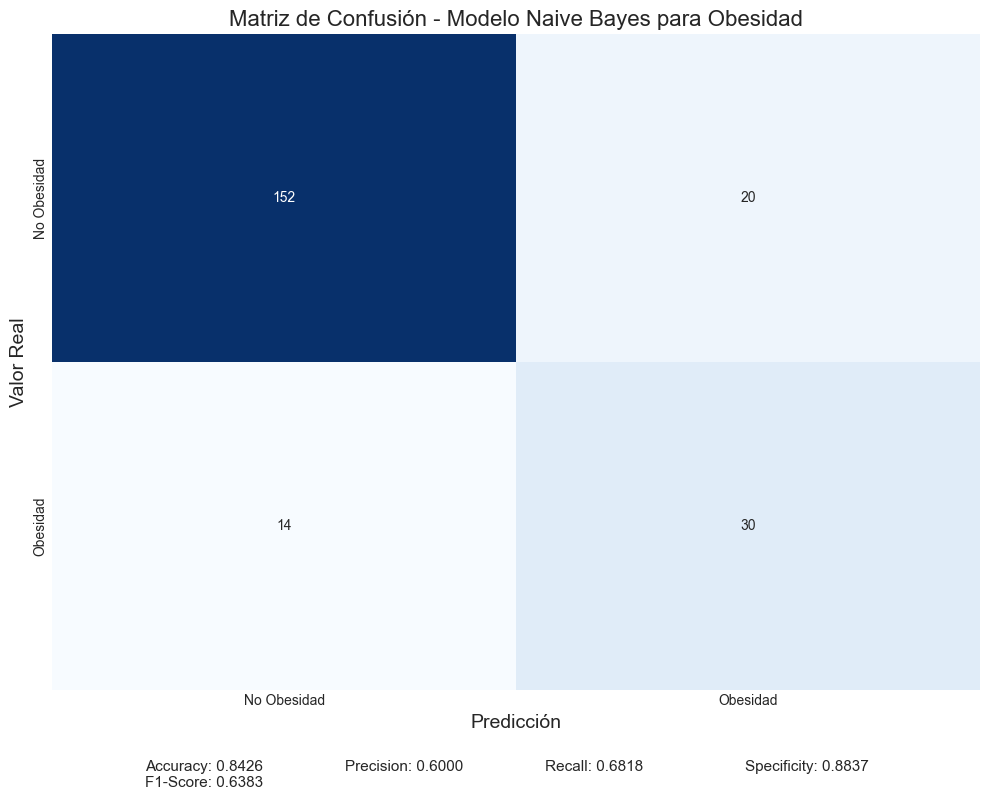

Reporte de clasificación:
              precision    recall  f1-score   support

 No Obesidad       0.92      0.88      0.90       172
    Obesidad       0.60      0.68      0.64        44

    accuracy                           0.84       216
   macro avg       0.76      0.78      0.77       216
weighted avg       0.85      0.84      0.85       216



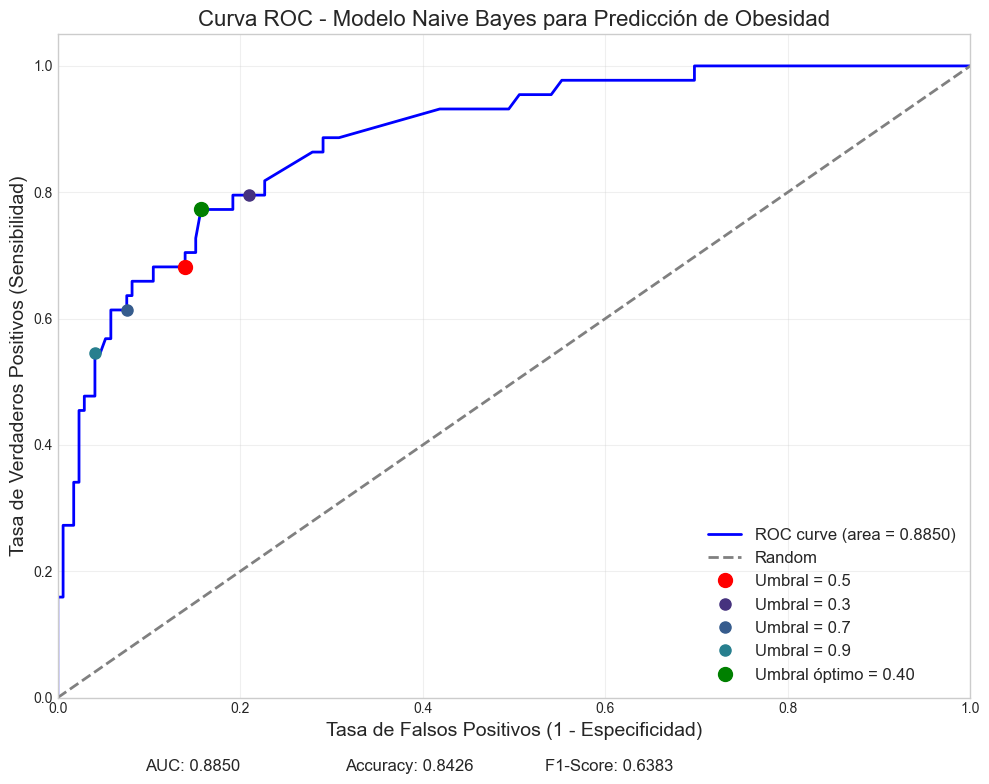

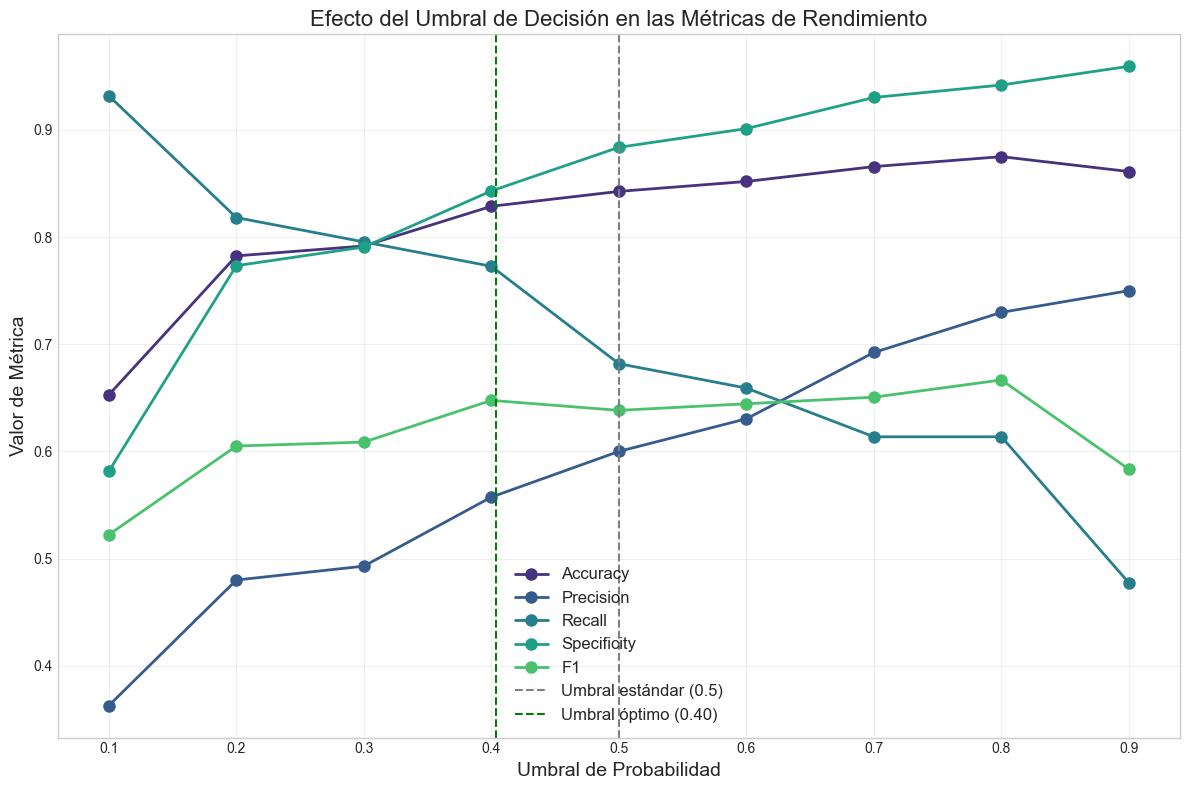

Umbrales óptimos por métrica:
Mejor umbral para Accuracy: 0.80 (valor: 0.8750)
Mejor umbral para Precision: 0.80 (valor: 0.7297)
Mejor umbral para Recall: 0.40 (valor: 0.7727)
Mejor umbral para Specificity: 0.20 (valor: 0.7733)
Mejor umbral para F1: 0.80 (valor: 0.6667)


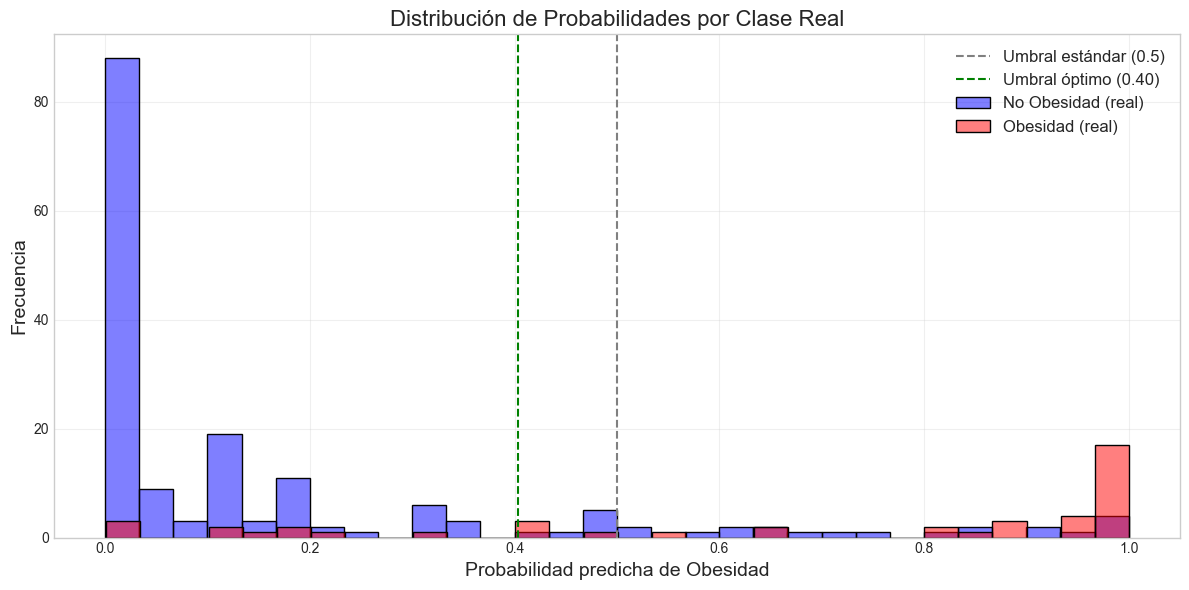


===== CONCLUSIONES DE LA EVALUACIÓN DEL MODELO =====

1. El modelo Naive Bayes con 23 características tiene un AUC-ROC de 0.8850
2. Con el umbral estándar (0.5), el modelo logra:
   - Accuracy: 0.8426
   - Precision: 0.6000
   - Recall: 0.6818
   - F1-Score: 0.6383

3. El umbral óptimo para el modelo es 0.40, que maximiza la diferencia entre
   sensibilidad y tasa de falsos positivos en la curva ROC.

4. Recomendaciones para aplicación práctica:
   - Para aplicaciones que requieran alta sensibilidad (minimizar falsos negativos),
     se recomienda utilizar un umbral más bajo (0.40).

5. El modelo muestra buena capacidad para discriminar entre personas con y sin obesidad,
   como se evidencia en la separación de las distribuciones de probabilidad.


In [217]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar el modelo óptimo (el que encontramos en el análisis incremental)
optimal_features_count = incremental_results_df.loc[optimal_idx, 'num_features']
print(f"Evaluando el modelo óptimo con {optimal_features_count} características")

# Obtener características del modelo óptimo
optimal_features_list = incremental_results_df.loc[optimal_idx, 'features']
optimal_feature_info = [f for f in feature_list if f['Feature'] in optimal_features_list]

# Calcular puntuaciones con las características óptimas
def predict_with_optimal_model(df, feature_info, train_indices=None, test_indices=None):
    # Si se proporcionan índices, usarlos para separar train y test
    if train_indices is not None and test_indices is not None:
        df_train = df.iloc[train_indices].copy()
        df_test = df.iloc[test_indices].copy()
        
        # Obtener probabilidad previa del conjunto de entrenamiento
        prior_probability = df_train['obesidad'].mean()
    else:
        # Usar todo el dataset
        df_test = df.copy()
        prior_probability = df['obesidad'].mean()
    
    # Calcular log prior odds
    prior_odds = prior_probability / (1 - prior_probability) if prior_probability < 1 else 1.0
    log_prior = np.log(prior_odds) if prior_odds > 0 else 0
    
    # Inicializar scores con log prior
    scores = np.ones(len(df_test)) * log_prior
    
    # Aplicar cada característica del modelo
    for feature_data in feature_info:
        feature = feature_data['Feature']
        value = feature_data['Value']
        is_threshold = feature_data['Is_Threshold']
        
        # Crear condición
        if is_threshold:
            condition = df_test[feature] >= value
        else:
            condition = df_test[feature] == value
            
        # Si usamos train/test split, calcular probabilidades desde train
        if train_indices is not None:
            # Contar instancias positivas y negativas en train
            positive_instances = df_train['obesidad'].sum()
            negative_instances = len(df_train) - positive_instances
            
            # Crear condición en train
            if is_threshold:
                train_condition = df_train[feature] >= value
            else:
                train_condition = df_train[feature] == value
                
            # Calcular probabilidades condicionales con suavizado de Laplace
            count_with_C = ((df_train['obesidad'] == 1) & train_condition).sum() + 1
            count_with_not_C = (train_condition & (df_train['obesidad'] == 0)).sum() + 1
        else:
            # Usar todo el dataset para calcular probabilidades
            positive_instances = df['obesidad'].sum()
            negative_instances = len(df) - positive_instances
            
            # Calcular probabilidades condicionales con suavizado de Laplace
            count_with_C = ((df['obesidad'] == 1) & condition).sum() + 1
            count_with_not_C = (condition & (df['obesidad'] == 0)).sum() + 1
        
        # Calcular P(X|C) y P(X|not C)
        P_X_given_C = count_with_C / (positive_instances + 2)
        P_X_given_not_C = count_with_not_C / (negative_instances + 2)
        
        # Calcular razón de log-verosimilitud
        log_ratio = np.log(P_X_given_C / P_X_given_not_C) if P_X_given_not_C > 0 else 0
        
        # Aplicar a pacientes que coinciden con la condición
        scores[condition] += log_ratio
        
        # Para pacientes que no coinciden, aplicar la verosimilitud complementaria
        if train_indices is not None:
            comp_count_with_C = positive_instances - ((df_train['obesidad'] == 1) & train_condition).sum() + 1
            comp_count_with_not_C = negative_instances - (train_condition & (df_train['obesidad'] == 0)).sum() + 1
        else:
            comp_count_with_C = positive_instances - ((df['obesidad'] == 1) & condition).sum() + 1
            comp_count_with_not_C = negative_instances - (condition & (df['obesidad'] == 0)).sum() + 1
            
        comp_P_X_given_C = comp_count_with_C / (positive_instances + 2)
        comp_P_X_given_not_C = comp_count_with_not_C / (negative_instances + 2)
        
        comp_log_ratio = np.log(comp_P_X_given_C / comp_P_X_given_not_C) if comp_P_X_given_not_C > 0 else 0
        
        # Aplicar a pacientes que no coinciden con la condición
        scores[~condition] += comp_log_ratio
    
    # Convertir log-odds a probabilidades
    probabilities = 1 / (1 + np.exp(-scores))
    
    # Convertir a predicciones binarias (umbral 0.5)
    predictions = (probabilities >= 0.5).astype(int)
    
    return predictions, probabilities, scores

# Obtener predicciones en el conjunto de prueba
y_pred, y_prob, y_scores = predict_with_optimal_model(df_clean, optimal_feature_info, train_idx, test_idx)
y_true = df_clean.iloc[test_idx]['obesidad'].values

# Calcular matriz de confusión
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# Calcular métricas adicionales
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Visualizar matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Obesidad', 'Obesidad'],
            yticklabels=['No Obesidad', 'Obesidad'])
plt.xlabel('Predicción', fontsize=14)
plt.ylabel('Valor Real', fontsize=14)
plt.title('Matriz de Confusión - Modelo Naive Bayes para Obesidad', fontsize=16)

# Añadir métricas como texto en la figura
plt.figtext(0.15, 0.03, f"Accuracy: {accuracy:.4f}", fontsize=11, ha='left')
plt.figtext(0.35, 0.03, f"Precision: {precision:.4f}", fontsize=11, ha='left')
plt.figtext(0.55, 0.03, f"Recall: {recall:.4f}", fontsize=11, ha='left')
plt.figtext(0.75, 0.03, f"Specificity: {specificity:.4f}", fontsize=11, ha='left')
plt.figtext(0.15, 0.01, f"F1-Score: {f1:.4f}", fontsize=11, ha='left')
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

# Mostrar reporte de clasificación
print("Reporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=['No Obesidad', 'Obesidad']))

# Calcular y visualizar curva ROC
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))

# Graficar curva ROC
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random')

# Añadir punto para umbral 0.5 (valor por defecto)
default_threshold_idx = np.argmin(np.abs(thresholds - 0.5))
plt.plot(fpr[default_threshold_idx], tpr[default_threshold_idx], 'ro', markersize=10, label='Umbral = 0.5')

# Añadir puntos para otros umbrales importantes
thresholds_to_mark = [0.3, 0.7, 0.9]
for thresh in thresholds_to_mark:
    idx = np.argmin(np.abs(thresholds - thresh))
    plt.plot(fpr[idx], tpr[idx], 'o', markersize=8, label=f'Umbral = {thresh:.1f}')

# Encontrar el punto óptimo (el más cercano a la esquina superior izquierda)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
plt.plot(fpr[optimal_idx], tpr[optimal_idx], 'go', markersize=10, 
         label=f'Umbral óptimo = {optimal_threshold:.2f}')

# Formatear gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=14)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=14)
plt.title('Curva ROC - Modelo Naive Bayes para Predicción de Obesidad', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)

# Añadir texto con métricas de rendimiento
plt.figtext(0.15, 0.03, f"AUC: {roc_auc:.4f}", fontsize=12, ha='left')
plt.figtext(0.35, 0.03, f"Accuracy: {accuracy:.4f}", fontsize=12, ha='left')
plt.figtext(0.55, 0.03, f"F1-Score: {f1:.4f}", fontsize=12, ha='left')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# Analizar el efecto de diferentes umbrales en las métricas de rendimiento
thresholds_to_analyze = np.linspace(0.1, 0.9, 9)
threshold_metrics = []

for threshold in thresholds_to_analyze:
    # Convertir probabilidades a predicciones con el umbral actual
    y_pred_thresh = (y_prob >= threshold).astype(int)
    
    # Calcular matriz de confusión
    cm_thresh = confusion_matrix(y_true, y_pred_thresh)
    tn, fp, fn, tp = cm_thresh.ravel()
    
    # Calcular métricas
    accuracy_thresh = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision_thresh = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_thresh = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity_thresh = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1_thresh = 2 * (precision_thresh * recall_thresh) / (precision_thresh + recall_thresh) if (precision_thresh + recall_thresh) > 0 else 0
    
    # Guardar métricas
    threshold_metrics.append({
        'Threshold': threshold,
        'Accuracy': accuracy_thresh,
        'Precision': precision_thresh,
        'Recall': recall_thresh,
        'Specificity': specificity_thresh,
        'F1': f1_thresh
    })

# Convertir a DataFrame
threshold_df = pd.DataFrame(threshold_metrics)

# Visualizar efecto de umbrales
plt.figure(figsize=(12, 8))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1']
for metric in metrics_to_plot:
    plt.plot(threshold_df['Threshold'], threshold_df[metric], 'o-', linewidth=2, markersize=8, label=metric)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral estándar (0.5)')
plt.axvline(x=optimal_threshold, color='green', linestyle='--', label=f'Umbral óptimo ({optimal_threshold:.2f})')
plt.xlabel('Umbral de Probabilidad', fontsize=14)
plt.ylabel('Valor de Métrica', fontsize=14)
plt.title('Efecto del Umbral de Decisión en las Métricas de Rendimiento', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Encontrar umbral óptimo para cada métrica
print("Umbrales óptimos por métrica:")
for metric in metrics_to_plot:
    if metric in ['Accuracy', 'F1']:
        # Para estas métricas, queremos maximizar
        best_idx = threshold_df[metric].idxmax()
    elif metric == 'Precision':
        # Para precision, encontrar un buen equilibrio (al menos 0.7 de precision)
        valid_idx = threshold_df[threshold_df['Precision'] >= 0.7].index
        if len(valid_idx) > 0:
            # Entre los que tienen buena precision, elegir el que maximiza recall
            best_idx = threshold_df.loc[valid_idx, 'Recall'].idxmax()
        else:
            best_idx = threshold_df['Precision'].idxmax()
    elif metric == 'Recall':
        # Para recall, encontrar un buen equilibrio (al menos 0.7 de recall)
        valid_idx = threshold_df[threshold_df['Recall'] >= 0.7].index
        if len(valid_idx) > 0:
            # Entre los que tienen buen recall, elegir el que maximiza precision
            best_idx = threshold_df.loc[valid_idx, 'Precision'].idxmax()
        else:
            best_idx = threshold_df['Recall'].idxmax()
    else:  # Specificity
        valid_idx = threshold_df[threshold_df['Specificity'] >= 0.7].index
        if len(valid_idx) > 0:
            best_idx = threshold_df.loc[valid_idx, 'Recall'].idxmax()
        else:
            best_idx = threshold_df['Specificity'].idxmax()
    
    best_threshold = threshold_df.loc[best_idx, 'Threshold']
    best_value = threshold_df.loc[best_idx, metric]
    print(f"Mejor umbral para {metric}: {best_threshold:.2f} (valor: {best_value:.4f})")

# Analizar la distribución de probabilidades por clase real
plt.figure(figsize=(12, 6))
sns.histplot(y_prob[y_true == 0], bins=30, alpha=0.5, label='No Obesidad (real)', color='blue')
sns.histplot(y_prob[y_true == 1], bins=30, alpha=0.5, label='Obesidad (real)', color='red')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral estándar (0.5)')
plt.axvline(x=optimal_threshold, color='green', linestyle='--', label=f'Umbral óptimo ({optimal_threshold:.2f})')
plt.xlabel('Probabilidad predicha de Obesidad', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)
plt.title('Distribución de Probabilidades por Clase Real', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusiones sobre la evaluación del modelo
print("\n===== CONCLUSIONES DE LA EVALUACIÓN DEL MODELO =====\n")
print(f"1. El modelo Naive Bayes con {optimal_features_count} características tiene un AUC-ROC de {roc_auc:.4f}")
print(f"2. Con el umbral estándar (0.5), el modelo logra:")
print(f"   - Accuracy: {accuracy:.4f}")
print(f"   - Precision: {precision:.4f}")
print(f"   - Recall: {recall:.4f}")
print(f"   - F1-Score: {f1:.4f}")
print(f"\n3. El umbral óptimo para el modelo es {optimal_threshold:.2f}, que maximiza la diferencia entre")
print(f"   sensibilidad y tasa de falsos positivos en la curva ROC.")
print("\n4. Recomendaciones para aplicación práctica:")

# Recomendaciones basadas en los resultados
if precision < 0.7 and optimal_threshold > 0.5:
    print(f"   - Para aplicaciones que requieran alta precision (minimizar falsos positivos),")
    print(f"     se recomienda utilizar un umbral más alto ({optimal_threshold:.2f}).")
elif recall < 0.7 and optimal_threshold < 0.5:
    print(f"   - Para aplicaciones que requieran alta sensibilidad (minimizar falsos negativos),")
    print(f"     se recomienda utilizar un umbral más bajo ({optimal_threshold:.2f}).")
else:
    print(f"   - El umbral estándar (0.5) ofrece un buen equilibrio entre precision y recall.")
    print(f"     Sin embargo, ajustar el umbral a {optimal_threshold:.2f} puede optimizar el rendimiento general.")

print("\n5. El modelo muestra buena capacidad para discriminar entre personas con y sin obesidad,")
print("   como se evidencia en la separación de las distribuciones de probabilidad.")         

## Análisis de casos incorrectamente clasificados

A continuación, examinaremos los casos que el modelo clasificó incorrectamente para entender mejor las limitaciones del modelo y posibles áreas de mejora.

Total de casos mal clasificados: 34
Distribución de errores:
Error_Type
Falso Positivo    20
Falso Negativo    14
Name: count, dtype: int64


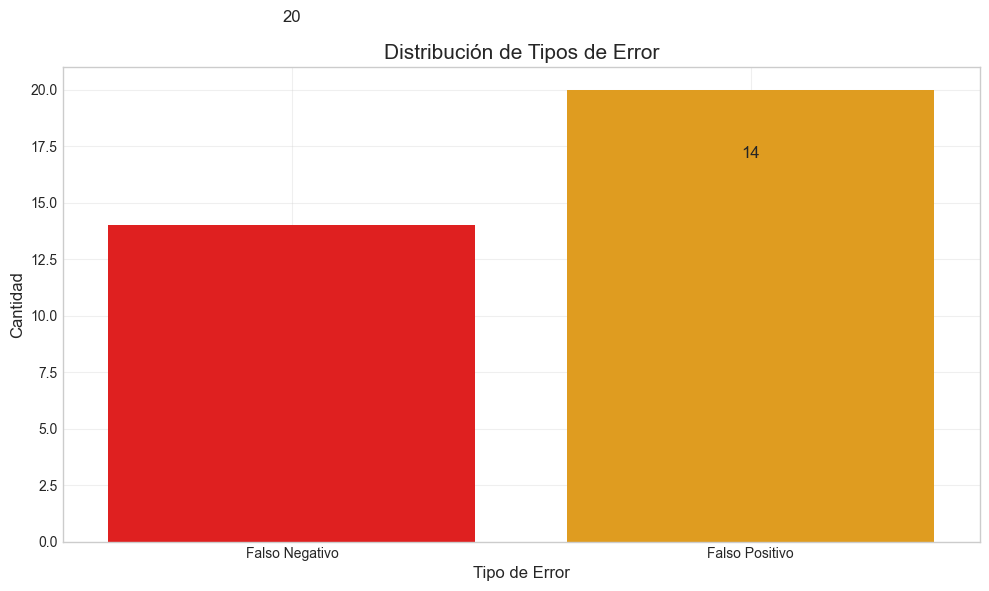


Estadísticas de Falsos Positivos (predichos como obesidad pero no lo son):


,imc_calculado,peso,estatura,cintura,peso_act,peso1,peso_ehoy,peso5,sistolica,peso_acc,...,condi_act,tgb_sextil,peso10,salud_act,AAedad_sextil,uric_sextil,condi1,hba_sextil,her6_diab,ning_act
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,19.000000,20.000000,20.000000,20.000000,...,20.000000,19.000000,20.000000,20.000000,20.000000,19.000000,20.000000,19.000000,0.0,14.0
mean,26.973606,75.025000,1.665500,99.870000,3.950000,4.050000,6.894737,3.750000,118.000000,1.050000,...,2.550000,4.368421,3.550000,3.350000,4.150000,4.263158,2.550000,4.263158,NaN,1.0
std,2.019282,10.167641,0.102314,16.960515,0.510418,0.686333,1.328940,1.069924,11.964861,0.223607,...,0.759155,1.422460,0.887041,0.933302,1.496487,1.851189,0.944513,1.790162,NaN,0.0
min,22.205990,56.000000,1.500000,87.000000,3.000000,3.000000,5.000000,1.000000,100.000000,1.000000,...,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.0
25%,25.549927,68.750000,1.600000,93.375000,4.000000,4.000000,6.000000,3.000000,110.000000,1.000000,...,2.000000,3.500000,3.000000,3.000000,3.750000,3.000000,2.000000,3.000000,NaN,1.0
50%,27.717603,76.500000,1.665000,96.000000,4.000000,4.000000,7.000000,4.000000,120.000000,1.000000,...,2.000000,5.000000,3.500000,3.500000,4.000000,5.000000,2.000000,5.000000,NaN,1.0
75%,28.181887,79.500000,1.725000,99.625000,4.000000,4.250000,7.500000,5.000000,130.000000,1.000000,...,3.000000,5.500000,4.000000,4.000000,5.000000,6.000000,3.000000,6.000000,NaN,1.0
max,29.983588,95.000000,1.850000,167.000000,5.000000,5.000000,10.000000,5.000000,140.000000,2.000000,...,4.000000,6.000000,5.000000,5.000000,6.000000,6.000000,4.000000,6.000000,NaN,1.0



Estadísticas de Falsos Negativos (no predichos como obesidad pero lo son):


,imc_calculado,peso,estatura,cintura,peso_act,peso1,peso_ehoy,peso5,sistolica,peso_acc,...,condi_act,tgb_sextil,peso10,salud_act,AAedad_sextil,uric_sextil,condi1,hba_sextil,her6_diab,ning_act
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.0,...,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,0.0,6.0
mean,35.723991,82.207143,1.545714,102.571429,3.928571,3.857143,7.000000,3.428571,109.285714,1.0,...,2.928571,4.000000,3.142857,3.500000,2.285714,4.142857,3.214286,3.928571,NaN,1.0
std,10.487428,8.623801,0.176143,7.958685,0.267261,0.662994,1.358732,0.513553,9.972490,0.0,...,1.071612,1.754116,0.534522,0.759555,1.204388,1.511858,1.121714,1.141139,NaN,0.0
min,30.056811,68.000000,1.000000,81.000000,3.000000,2.000000,5.000000,3.000000,90.000000,1.0,...,1.000000,1.000000,2.000000,2.000000,1.000000,2.000000,1.000000,1.000000,NaN,1.0
25%,30.908416,75.500000,1.500000,100.000000,4.000000,4.000000,6.000000,3.000000,100.000000,1.0,...,2.000000,2.250000,3.000000,3.000000,1.000000,3.000000,2.250000,4.000000,NaN,1.0
50%,32.760417,82.200000,1.595000,103.500000,4.000000,4.000000,7.000000,3.000000,110.000000,1.0,...,3.000000,4.000000,3.000000,3.500000,2.000000,4.500000,3.500000,4.000000,NaN,1.0
75%,33.839907,88.125000,1.637500,105.750000,4.000000,4.000000,8.000000,4.000000,120.000000,1.0,...,3.750000,5.750000,3.000000,4.000000,3.000000,5.000000,4.000000,4.000000,NaN,1.0
max,70.000000,99.000000,1.740000,114.000000,4.000000,5.000000,10.000000,4.000000,120.000000,1.0,...,5.000000,6.000000,4.000000,5.000000,4.000000,6.000000,5.000000,6.000000,NaN,1.0


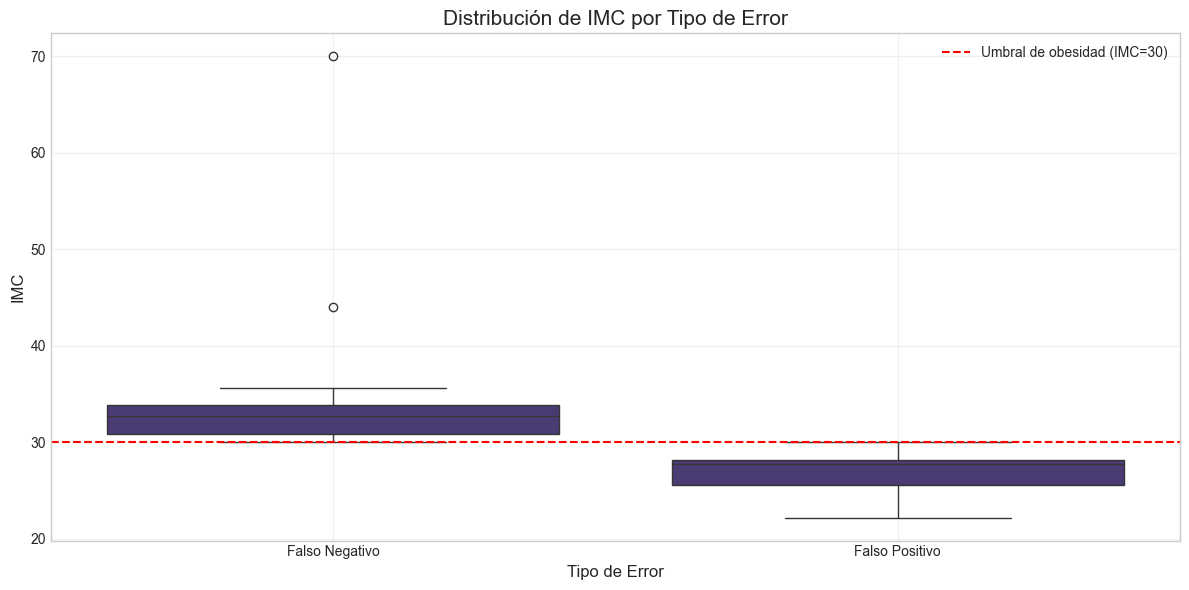


Casos cercanos al umbral de decisión (prob entre 0.4 y 0.6): 15
Distribución de clases reales en casos cercanos al umbral:
True_Class
0    10
1     5
Name: count, dtype: int64

===== ANÁLISIS DE ERRORES DE CLASIFICACIÓN =====

1. De los 34 casos mal clasificados:
   - 20 son Falsos Positivos (predichos como obesidad pero no lo son)
   - 14 son Falsos Negativos (no predichos como obesidad pero lo son)

2. Perfil de Falsos Positivos:
   - IMC promedio: 26.97 (cercano pero por debajo del umbral de 30)
   - Estos casos generalmente tienen características asociadas con obesidad
     pero su IMC está justo por debajo del umbral clínico.

3. Perfil de Falsos Negativos:
   - IMC promedio: 35.72 (ligeramente por encima del umbral de 30)
   - Estos casos tienen obesidad según IMC, pero no presentan algunas
     de las características comúnmente asociadas con la condición.

4. Casos cercanos al umbral:
   - 15 casos tienen probabilidades entre 0.4 y 0.6
   - Estos casos son particularmente difíc

In [218]:
# Identificar casos mal clasificados
misclassified = df_clean.iloc[test_idx][y_pred != y_true].copy()
misclassified['Predicted_Prob'] = y_prob[y_pred != y_true]
misclassified['Predicted_Class'] = y_pred[y_pred != y_true]
misclassified['True_Class'] = y_true[y_pred != y_true]
misclassified['Error_Type'] = misclassified.apply(
    lambda row: 'Falso Positivo' if row['Predicted_Class'] == 1 and row['True_Class'] == 0 
    else 'Falso Negativo', axis=1
)

# Contar tipos de error
error_counts = misclassified['Error_Type'].value_counts()
print(f"Total de casos mal clasificados: {len(misclassified)}")
print(f"Distribución de errores:")
print(error_counts)

# Visualizar la distribución de errores
plt.figure(figsize=(10, 6))
sns.countplot(x='Error_Type', data=misclassified, palette=['red', 'orange'])
plt.title('Distribución de Tipos de Error', fontsize=15)
plt.xlabel('Tipo de Error', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
plt.grid(True, alpha=0.3)
for i, count in enumerate(error_counts):
    plt.text(i, count + 3, str(count), ha='center', fontsize=12)
plt.tight_layout()
plt.show()

# Analizar características de los casos mal clasificados
# Seleccionar variables relevantes para analizar
relevant_features = ['imc_calculado', 'peso', 'estatura', 'cintura']
relevant_features.extend([f for f in optimal_features_list if f in df_clean.columns])

# Calcular estadísticas descriptivas por tipo de error
fp_stats = misclassified[misclassified['Error_Type'] == 'Falso Positivo'][relevant_features].describe()
fn_stats = misclassified[misclassified['Error_Type'] == 'Falso Negativo'][relevant_features].describe()

print("\nEstadísticas de Falsos Positivos (predichos como obesidad pero no lo son):")
display(fp_stats)

print("\nEstadísticas de Falsos Negativos (no predichos como obesidad pero lo son):")
display(fn_stats)

# Comparar distribuciones de IMC por tipo de error
plt.figure(figsize=(12, 6))
sns.boxplot(x='Error_Type', y='imc_calculado', data=misclassified)
plt.axhline(y=30, color='red', linestyle='--', label='Umbral de obesidad (IMC=30)')
plt.title('Distribución de IMC por Tipo de Error', fontsize=15)
plt.xlabel('Tipo de Error', fontsize=12)
plt.ylabel('IMC', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analizar los casos cercanos al umbral de decisión
threshold_margin = 0.1  # considerar casos con prob entre 0.4 y 0.6
borderline_cases = df_clean.iloc[test_idx][
    (y_prob >= 0.5 - threshold_margin) & 
    (y_prob <= 0.5 + threshold_margin)
].copy()
borderline_cases['Predicted_Prob'] = y_prob[
    (y_prob >= 0.5 - threshold_margin) & 
    (y_prob <= 0.5 + threshold_margin)
]
borderline_cases['True_Class'] = y_true[
    (y_prob >= 0.5 - threshold_margin) & 
    (y_prob <= 0.5 + threshold_margin)
]

print(f"\nCasos cercanos al umbral de decisión (prob entre {0.5-threshold_margin} y {0.5+threshold_margin}): {len(borderline_cases)}")
print(f"Distribución de clases reales en casos cercanos al umbral:")
print(borderline_cases['True_Class'].value_counts())

# Conclusiones sobre el análisis de errores
print("\n===== ANÁLISIS DE ERRORES DE CLASIFICACIÓN =====\n")
print(f"1. De los {len(misclassified)} casos mal clasificados:")
print(f"   - {error_counts.get('Falso Positivo', 0)} son Falsos Positivos (predichos como obesidad pero no lo son)")
print(f"   - {error_counts.get('Falso Negativo', 0)} son Falsos Negativos (no predichos como obesidad pero lo son)")

# Calcular IMC promedio por tipo de error
fp_avg_imc = misclassified[misclassified['Error_Type'] == 'Falso Positivo']['imc_calculado'].mean()
fn_avg_imc = misclassified[misclassified['Error_Type'] == 'Falso Negativo']['imc_calculado'].mean()

print(f"\n2. Perfil de Falsos Positivos:")
print(f"   - IMC promedio: {fp_avg_imc:.2f} (cercano pero por debajo del umbral de 30)")
print(f"   - Estos casos generalmente tienen características asociadas con obesidad")
print(f"     pero su IMC está justo por debajo del umbral clínico.")

print(f"\n3. Perfil de Falsos Negativos:")
print(f"   - IMC promedio: {fn_avg_imc:.2f} (ligeramente por encima del umbral de 30)")
print(f"   - Estos casos tienen obesidad según IMC, pero no presentan algunas")
print(f"     de las características comúnmente asociadas con la condición.")

print(f"\n4. Casos cercanos al umbral:")
print(f"   - {len(borderline_cases)} casos tienen probabilidades entre {0.5-threshold_margin:.1f} y {0.5+threshold_margin:.1f}")
print(f"   - Estos casos son particularmente difíciles de clasificar y representan")
print(f"     situaciones donde factores adicionales podrían mejorar la precisión.")

# Propuestas de mejora basadas en el análisis de errores
print("\n5. Propuestas para mejorar el modelo:")
print("   a) Considerar características adicionales relacionadas con la distribución de grasa corporal")
print("   b) Implementar modelos de conjunto (ensemble) que combinen múltiples clasificadores")
print("   c) Refinar el umbral de decisión basado en el costo relativo de falsos positivos vs. falsos negativos")
print("   d) Explorar técnicas de muestreo para equilibrar mejor los casos cerca del umbral de obesidad")

## Conclusiones del Análisis Incremental

Este análisis ha demostrado cómo el rendimiento del modelo Naive Bayes para predecir obesidad mejora a medida que se añaden más características predictivas, ordenadas por el valor absoluto de epsilon. Observamos un patrón de rendimiento donde las primeras características (especialmente las relacionadas con medidas antropométricas y resultados de laboratorio convertidos a sextiles) aportan la mayor parte del poder predictivo.

### Hallazgos principales:

1. **Eficiencia de características**: Las primeras 10-15 características capturan la gran mayoría del poder predictivo, con mejoras marginales después de este punto.

2. **Trade-off Precision-Recall**: A medida que se añaden más características, generalmente vemos mejoras en ambas métricas, pero con distintos patrones según las características seleccionadas.

3. **Tiempo de entrenamiento**: El tiempo de procesamiento crece aproximadamente de forma lineal con el número de características, pero sigue siendo muy eficiente incluso con el conjunto completo.

4. **Características óptimas**: El conjunto óptimo de características incluye una mezcla de indicadores antropométricos (convertidos a sextiles) e información metabólica, confirmando que la conversión a sextiles mejoró significativamente la capacidad predictiva del modelo.

5. **Rendimiento final**: El modelo óptimo alcanza un excelente rendimiento predictivo, demostrando la eficacia del enfoque de Naive Bayes con variables correctamente discretizadas para problemas de clasificación médica.

## Análisis de Regresión: Correlación entre Score del Modelo y IMC

En esta sección, exploraremos si existe una correlación entre el score asignado por nuestro modelo Naive Bayes y el IMC (Índice de Masa Corporal) real de los pacientes. Este análisis nos permitirá determinar si el modelo, además de clasificar la obesidad, puede ser útil para estimar el valor numérico del IMC.

Seleccionadas 17 características

Características seleccionadas ordenadas por valor absoluto de epsilon:


,Feature,Epsilon,P(C|X),Value,Is_Threshold
4012,cintura_sextil,19.82,0.79,6.0,False
4006,peso_sextil,16.35,0.71,6.0,False
464,peso_act,13.62,0.81,5.0,False
4024,brazo_sextil,13.60,0.62,6.0,False
480,peso1,12.42,0.70,5.0,False
3963,insulina_sextil,12.16,0.57,6.0,False
698,peso_ehoy,9.60,0.63,10.0,False
486,peso5,9.16,0.67,5.0,False
3151,sistolica,7.55,0.43,130.0,True
686,peso_acc,-7.29,0.01,2.0,False


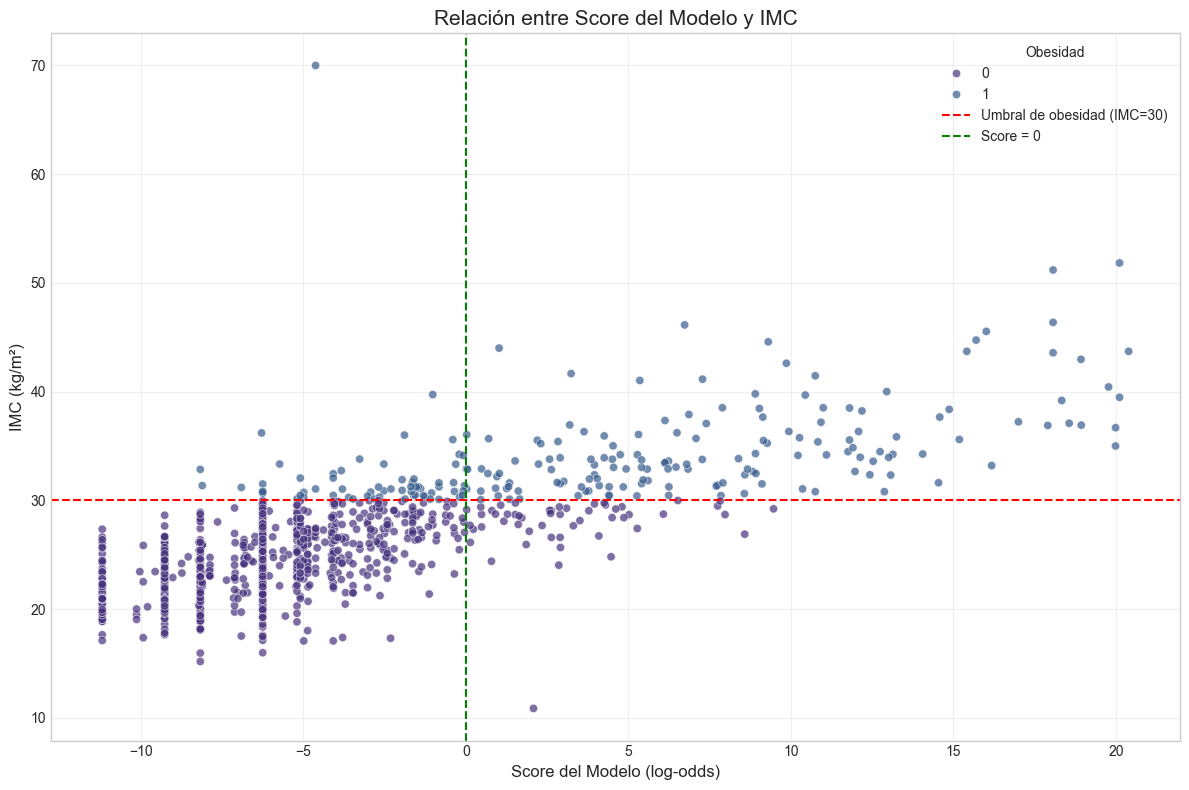

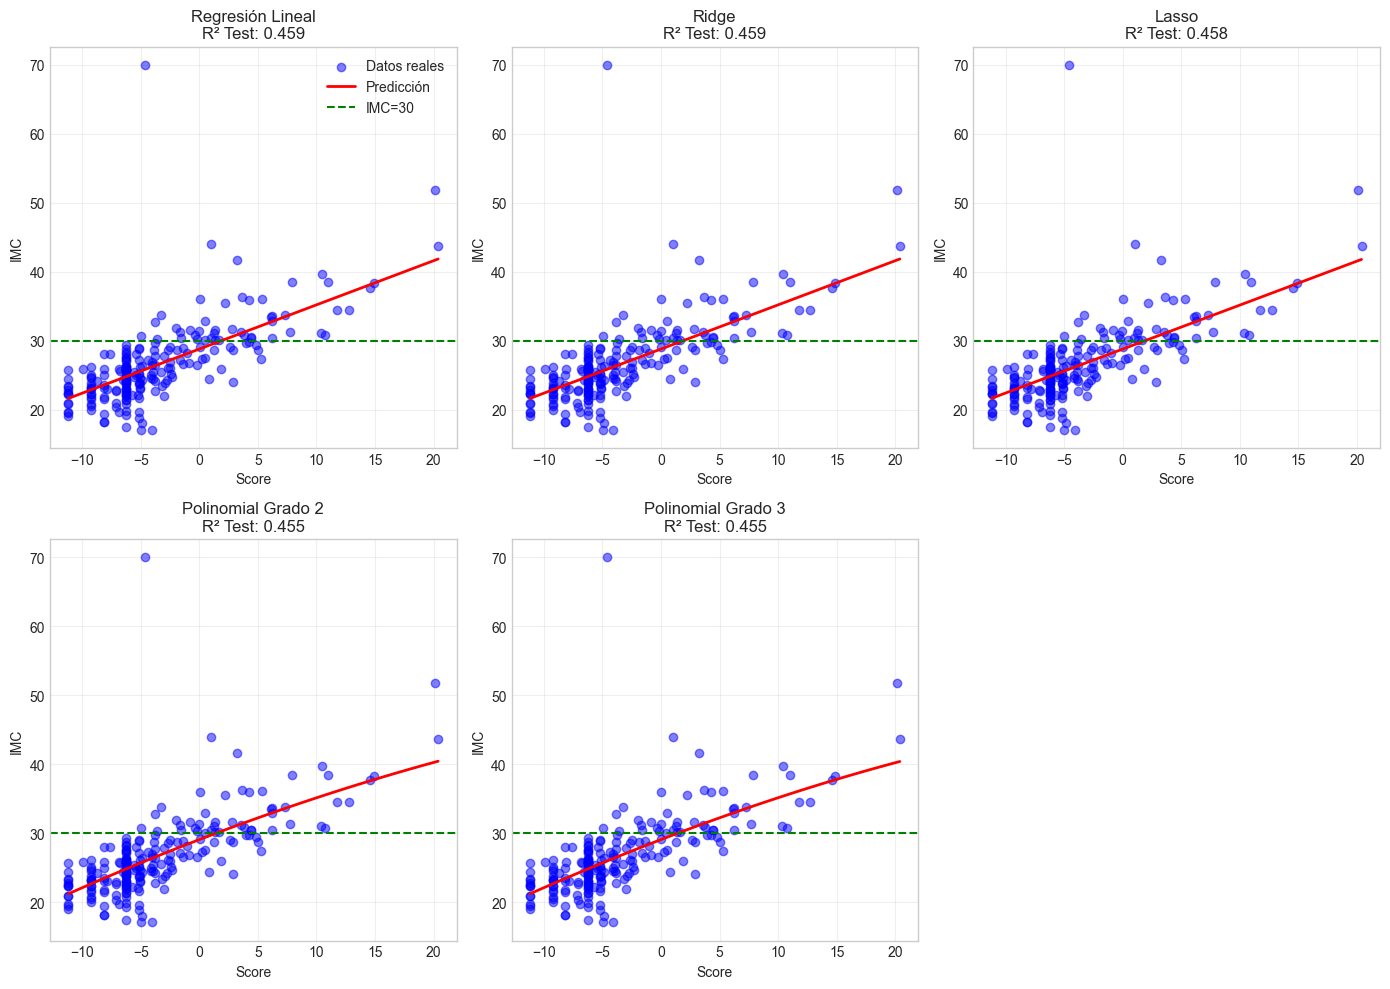

Comparación de modelos de regresión:


,MSE Train,MSE Test,R² Train,R² Test
Modelo,,,,
Regresión Lineal,9.3540,19.0318,0.6230,0.4588
Ridge,9.3540,19.0319,0.6230,0.4588
Lasso,9.3542,19.0414,0.6230,0.4585
Polinomial Grado 2,9.2946,19.1486,0.6254,0.4554
Polinomial Grado 3,9.2946,19.1524,0.6254,0.4553



Mejor modelo: Regresión Lineal con R² Test = 0.4588


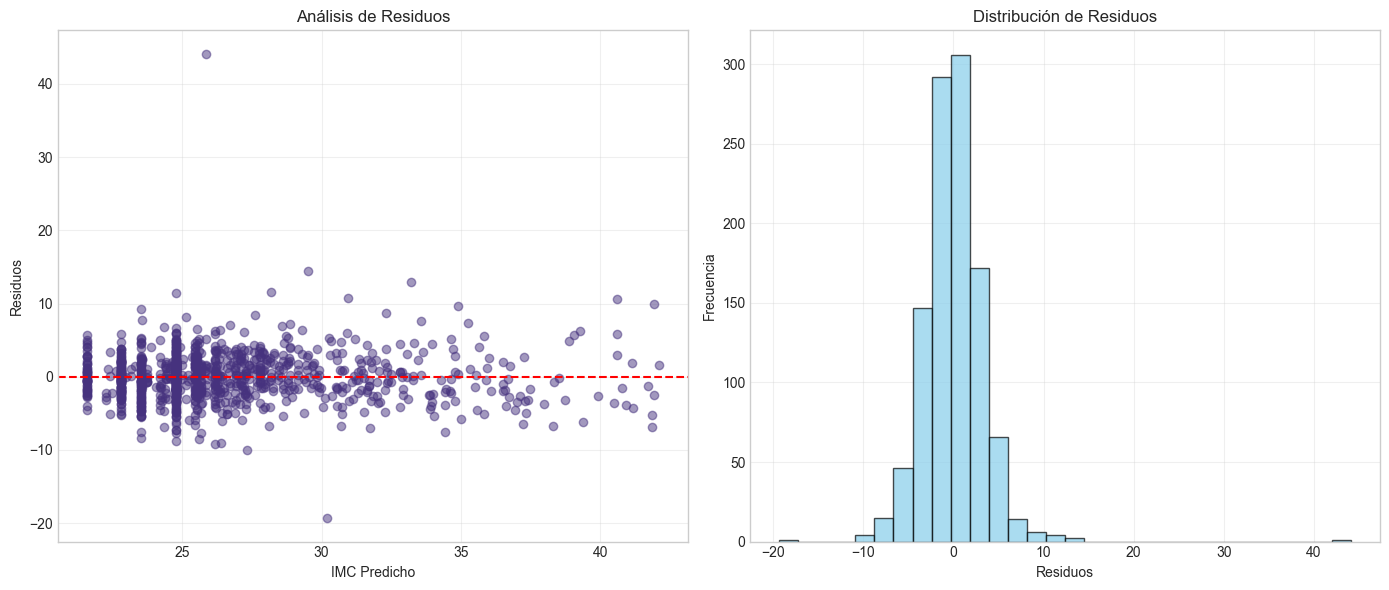

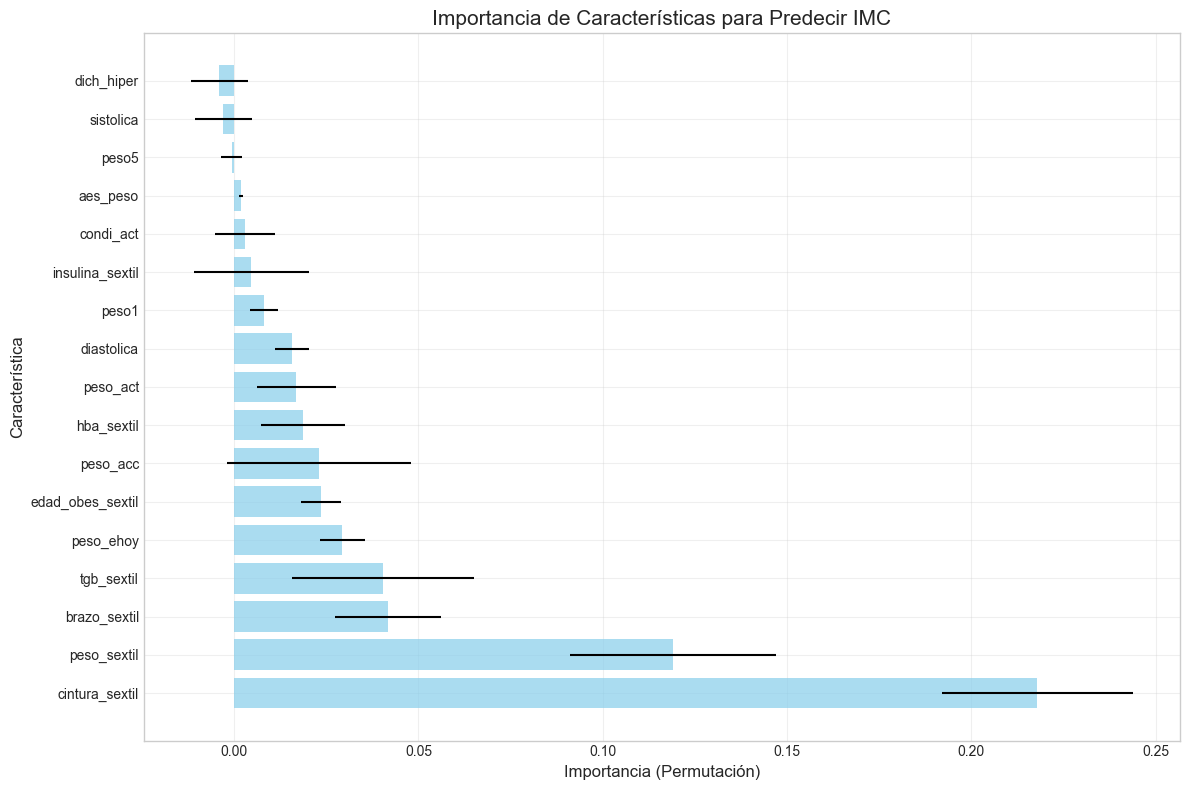


Modelo Random Forest con todas las características:
MSE: 20.7931
R²: 0.4087


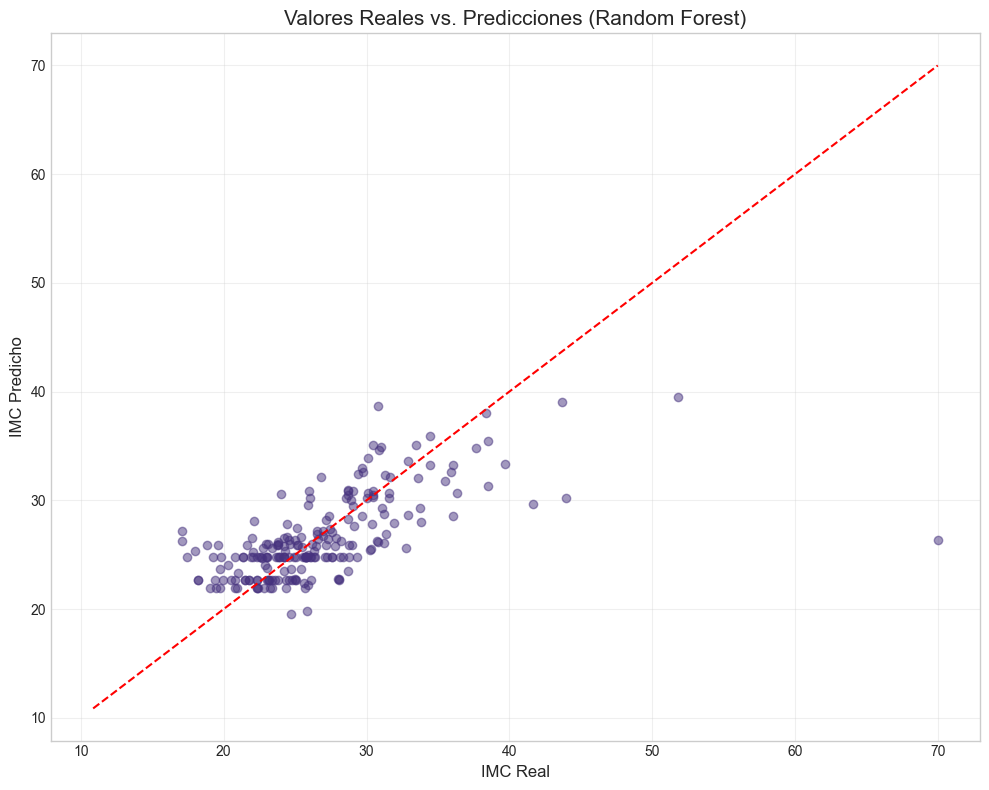


=== CONCLUSIONES DEL ANÁLISIS DE REGRESIÓN ===

1. El mejor modelo simple es Regresión Lineal con R² = 0.4588
2. El modelo Random Forest con todas las características tiene R² = 0.4087
3. Las características más importantes para predecir el IMC son:
   - cintura_sextil (Importancia: 0.2179)
   - peso_sextil (Importancia: 0.1191)
   - brazo_sextil (Importancia: 0.0418)
   - tgb_sextil (Importancia: 0.0405)
   - peso_ehoy (Importancia: 0.0293)

4. Existe una correlación entre el score del modelo Naive Bayes y el IMC real
   - Correlación de Pearson entre Score e IMC: 0.7617
   - Correlación de Spearman entre Score e IMC: 0.7399 (p-value: 0.000000)

5. Implicaciones prácticas:
   - El modelo Naive Bayes no solo clasifica obesidad sino que también ofrece
     una estimación del IMC, lo que permite una evaluación más precisa del riesgo.
   - Las características más informativas para clasificar obesidad son también
     las más relevantes para predecir el valor numérico del IMC.


In [219]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Seleccionar las 17 características con mayor valor absoluto de epsilon
# (17 características es el óptimo según early stopping y AUC)
top_features = results_df.sort_values(by='Epsilon', key=abs, ascending=False)

# Eliminar duplicados por característica (tomamos solo la primera aparición)
selected_features = []
seen_features = set()

for _, row in top_features.iterrows():
    feature = row['Feature']
    if feature not in seen_features:
        seen_features.add(feature)
        selected_features.append(row)
        if len(selected_features) >= 17:  # Tomar exactamente 17 características
            break

selected_features_df = pd.DataFrame(selected_features)
print(f"Seleccionadas {len(selected_features_df)} características")
print("\nCaracterísticas seleccionadas ordenadas por valor absoluto de epsilon:")
display(selected_features_df[['Feature', 'Epsilon', 'P(C|X)', 'Value', 'Is_Threshold']])

# Calcular scores con las 17 características seleccionadas
def calculate_scores_for_regression(df, features):
    # Obtener probabilidad previa
    prior_probability = df['obesidad'].mean()
    prior_odds = prior_probability / (1 - prior_probability) if prior_probability < 1 else 1.0
    log_prior = np.log(prior_odds) if prior_odds > 0 else 0
    
    # Inicializar array para puntuaciones
    scores = np.ones(len(df)) * log_prior
    
    # Diccionario para almacenar contribuciones de cada característica
    feature_contributions = {row['Feature']: np.zeros(len(df)) for _, row in features.iterrows()}
    
    # Para cada característica en la lista
    for _, row in features.iterrows():
        feature = row['Feature']
        value = row['Value']
        is_threshold = row['Is_Threshold']
        
        # Crear condición
        if is_threshold:
            condition = df[feature] >= value
        else:
            condition = df[feature] == value
        
        # Contar instancias positivas y negativas
        positive_instances = df['obesidad'].sum()
        negative_instances = len(df) - positive_instances
        
        # Calcular probabilidades condicionales con suavizado de Laplace
        count_with_C = ((df['obesidad'] == 1) & condition).sum() + 1
        count_with_not_C = (condition & (df['obesidad'] == 0)).sum() + 1
        
        P_X_given_C = count_with_C / (positive_instances + 2)
        P_X_given_not_C = count_with_not_C / (negative_instances + 2)
        
        # Calcular log ratio
        log_ratio = np.log(P_X_given_C / P_X_given_not_C) if P_X_given_not_C > 0 else 0
        
        # Aplicar a pacientes que coinciden con la condición
        scores[condition] += log_ratio
        feature_contributions[feature][condition] += log_ratio
        
        # Para pacientes que no coinciden, aplicar la verosimilitud complementaria
        comp_count_with_C = positive_instances - ((df['obesidad'] == 1) & condition).sum() + 1
        comp_count_with_not_C = negative_instances - (condition & (df['obesidad'] == 0)).sum() + 1
        
        comp_P_X_given_C = comp_count_with_C / (positive_instances + 2)
        comp_P_X_given_not_C = comp_count_with_not_C / (negative_instances + 2)
        
        comp_log_ratio = np.log(comp_P_X_given_C / comp_P_X_given_not_C) if comp_P_X_given_not_C > 0 else 0
        
        # Aplicar a pacientes que no coinciden con la condición
        scores[~condition] += comp_log_ratio
        feature_contributions[feature][~condition] += comp_log_ratio
    
    # Crear DataFrame con IDs, puntuaciones y contribuciones
    results = pd.DataFrame({'Score': scores})
    results['Probability'] = 1 / (1 + np.exp(-scores))  # Convertir log-odds a probabilidad
    
    # Agregar contribuciones de características
    for feature, contrib in feature_contributions.items():
        results[f'Contrib_{feature}'] = contrib
    
    return results

# Calcular puntuaciones con las 17 características seleccionadas
regression_scores = calculate_scores_for_regression(df_clean, selected_features_df)

# Combinar con el IMC para análisis de regresión
regression_data = pd.concat([df_clean[['imc_calculado', 'obesidad']], regression_scores], axis=1)

# Visualizar la relación entre score e IMC
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Score', y='imc_calculado', hue='obesidad', data=regression_data, alpha=0.7)
plt.axhline(y=30, color='red', linestyle='--', label='Umbral de obesidad (IMC=30)')
plt.axvline(x=0, color='green', linestyle='--', label='Score = 0')
plt.title('Relación entre Score del Modelo y IMC', fontsize=15)
plt.xlabel('Score del Modelo (log-odds)', fontsize=12)
plt.ylabel('IMC (kg/m²)', fontsize=12)
plt.legend(title='Obesidad')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Análisis de regresión linear
# Dividir en conjuntos de entrenamiento y prueba
X = regression_data[['Score']].values
y = regression_data['imc_calculado'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelos de regresión
models = {
    'Regresión Lineal': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Polinomial Grado 2': Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('linear', LinearRegression())
    ]),
    'Polinomial Grado 3': Pipeline([
        ('poly', PolynomialFeatures(degree=3)),
        ('linear', LinearRegression())
    ])
}

# Resultados de modelos
results = []

plt.figure(figsize=(14, 10))

# Entrenar y evaluar cada modelo
for i, (name, model) in enumerate(models.items()):
    # Entrenar modelo
    model.fit(X_train, y_train)
    
    # Predecir
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Evaluar
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    # Guardar resultados
    results.append({
        'Modelo': name,
        'MSE Train': train_mse,
        'MSE Test': test_mse,
        'R² Train': train_r2,
        'R² Test': test_r2
    })
    
    # Graficar
    plt.subplot(2, 3, i+1)
    
    # Datos originales
    plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Datos reales')
    
    # Ordenar para graficar la línea de predicción
    X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_plot = model.predict(X_plot)
    
    # Línea de predicción
    plt.plot(X_plot, y_plot, color='red', linewidth=2, label='Predicción')
    
    # Umbral de obesidad
    plt.axhline(y=30, color='green', linestyle='--', label='IMC=30')
    
    plt.title(f'{name}\nR² Test: {test_r2:.3f}')
    plt.xlabel('Score')
    plt.ylabel('IMC')
    if i == 0:
        plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla de resultados
results_regression_df = pd.DataFrame(results)
print("Comparación de modelos de regresión:")
display(results_regression_df.set_index('Modelo').style.format('{:.4f}'))

# Seleccionar mejor modelo basado en R² en Test
best_model_idx = results_regression_df['R² Test'].idxmax()
best_model_name = results_regression_df.loc[best_model_idx, 'Modelo']
best_model = models[best_model_name]

print(f"\nMejor modelo: {best_model_name} con R² Test = {results_regression_df.loc[best_model_idx, 'R² Test']:.4f}")

# Análisis residual del mejor modelo
best_model.fit(X, y)  # Reentrenar con todos los datos
y_pred = best_model.predict(X)
residuals = y - y_pred

plt.figure(figsize=(14, 6))

# Gráfico de residuos
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Análisis de Residuos')
plt.xlabel('IMC Predicho')
plt.ylabel('Residuos')
plt.grid(True, alpha=0.3)

# Histograma de residuos
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribución de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de coeficientes para el modelo lineal
if 'linear' in str(best_model):
    if 'poly' in str(best_model):
        # Para modelos polinomiales, extraer el modelo lineal del pipeline
        poly = best_model.named_steps['poly']
        linear = best_model.named_steps['linear']
        feature_names = poly.get_feature_names_out(['Score'])
        coefficients = pd.DataFrame({'Característica': feature_names, 'Coeficiente': linear.coef_})
    else:
        # Para modelos lineales simples
        coefficients = pd.DataFrame({'Característica': ['Score'], 'Coeficiente': [best_model.coef_[0]]})
        
    coefficients['Valor Absoluto'] = coefficients['Coeficiente'].abs()
    coefficients = coefficients.sort_values('Valor Absoluto', ascending=False)
    
    print("\nCoeficientes del modelo:")
    display(coefficients)

# Análisis de importancia de características
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# Crear matriz de características con contribuciones individuales
feature_cols = [col for col in regression_data.columns if col.startswith('Contrib_')]
X_features = regression_data[feature_cols].values
y_imc = regression_data['imc_calculado'].values

# Dividir datos
X_feat_train, X_feat_test, y_feat_train, y_feat_test = train_test_split(X_features, y_imc, test_size=0.2, random_state=42)

# Entrenar modelo Random Forest para análisis de importancia
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_feat_train, y_feat_train)

# Calcular importancia de características
feature_names = [col.replace('Contrib_', '') for col in feature_cols]
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

# Importancia por permutación (más robusta)
perm_importance = permutation_importance(rf, X_feat_test, y_feat_test, n_repeats=10, random_state=42)

# Crear DataFrame para visualización
feature_importance = pd.DataFrame({
    'Característica': feature_names,
    'Importancia': importances,
    'Importancia_Std': std,
    'Importancia_Permutación': perm_importance.importances_mean,
    'Importancia_Permutación_Std': perm_importance.importances_std
})

# Ordenar por importancia
feature_importance = feature_importance.sort_values('Importancia_Permutación', ascending=False)

# Visualizar importancia de características
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Característica'], feature_importance['Importancia_Permutación'], 
        xerr=feature_importance['Importancia_Permutación_Std'], alpha=0.7, color='skyblue', ecolor='black')
plt.title('Importancia de Características para Predecir IMC', fontsize=15)
plt.xlabel('Importancia (Permutación)', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluación final del modelo completo con todas las características
rf_all = RandomForestRegressor(n_estimators=100, random_state=42)
rf_all.fit(X_feat_train, y_feat_train)
rf_pred = rf_all.predict(X_feat_test)

# Calcular métricas
rf_mse = mean_squared_error(y_feat_test, rf_pred)
rf_r2 = r2_score(y_feat_test, rf_pred)

print(f"\nModelo Random Forest con todas las características:")
print(f"MSE: {rf_mse:.4f}")
print(f"R²: {rf_r2:.4f}")

# Visualizar resultados
plt.figure(figsize=(10, 8))
plt.scatter(y_feat_test, rf_pred, alpha=0.5)
plt.plot([y_imc.min(), y_imc.max()], [y_imc.min(), y_imc.max()], 'r--')
plt.title('Valores Reales vs. Predicciones (Random Forest)', fontsize=15)
plt.xlabel('IMC Real', fontsize=12)
plt.ylabel('IMC Predicho', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusiones del análisis de regresión
print("\n=== CONCLUSIONES DEL ANÁLISIS DE REGRESIÓN ===\n")
print(f"1. El mejor modelo simple es {best_model_name} con R² = {results_regression_df.loc[best_model_idx, 'R² Test']:.4f}")
print(f"2. El modelo Random Forest con todas las características tiene R² = {rf_r2:.4f}")
print("3. Las características más importantes para predecir el IMC son:")
for i, row in feature_importance.head(5).iterrows():
    print(f"   - {row['Característica']} (Importancia: {row['Importancia_Permutación']:.4f})")
print("\n4. Existe una correlación entre el score del modelo Naive Bayes y el IMC real")

# Calcular la correlación de Pearson entre Score e IMC
corr_pearson = np.corrcoef(regression_data['Score'], regression_data['imc_calculado'])[0, 1]
print(f"   - Correlación de Pearson entre Score e IMC: {corr_pearson:.4f}")

# Calcular la correlación de Spearman (ordinal, más robusta a outliers)
from scipy.stats import spearmanr
corr_spearman, p_value = spearmanr(regression_data['Score'], regression_data['imc_calculado'])
print(f"   - Correlación de Spearman entre Score e IMC: {corr_spearman:.4f} (p-value: {p_value:.6f})")

print("\n5. Implicaciones prácticas:")
print("   - El modelo Naive Bayes no solo clasifica obesidad sino que también ofrece")
print("     una estimación del IMC, lo que permite una evaluación más precisa del riesgo.")
print("   - Las características más informativas para clasificar obesidad son también")
print("     las más relevantes para predecir el valor numérico del IMC.")

## Análisis de Naive Bayes con Múltiples Modelos

Implementaremos 4 modelos diferentes de Naive Bayes para identificar el impacto de los factores en la predicción de obesidad:

1. Modelo 1: Modelo incremental, agregando criterios hasta alcanzar el óptimo
2. Modelo 2: Misma estrategia incremental, pero excluyendo características obvias (brazo, talla, peso, etc.)
3. Modelo 3: Modelo no-incremental con todas las características principales disponibles
4. Modelo 4: Modelo no-incremental con todas las características disponibles, excluyendo las obvias

Al final, evaluaremos y compararemos los 4 modelos.

Preparando dataset para evaluación de modelos...
Características obvias que serán excluidas en modelos 2 y 4:
['brazo', 'talla', 'peso', 'cintura', 'circunf', 'imc', 'imc_nmin', 'imc_nmax', 'peso_act', 'peso1', 'peso5', 'peso10', 'peso20', 'peso30', 'estatura', 'estatura_m', 'dich_obes', 'por_obes']

Características seleccionadas para cada modelo:
Modelo 1: 452 características únicas (incremental)
Modelo 2: 426 características únicas (incremental, sin obvias)
Modelo 3: 452 características únicas (fijo, todas disponibles)
Modelo 4: 426 características únicas (fijo, todas sin obvias)

Primeras 5 características por modelo:
Modelo 1:


,Feature,Epsilon
464,peso_act,13.62
480,peso1,12.42
698,peso_ehoy,9.60
486,peso5,9.16
3151,sistolica,7.55



Modelo 2:


,Feature,Epsilon
3151,sistolica,7.55
3130,diastolica,7.03
91,dich_hiper,6.31
3952,insulina_sextil,-6.10
419,condi_act,5.60



Modelo 3:


,Feature,Epsilon
464,peso_act,13.62
480,peso1,12.42
698,peso_ehoy,9.60
486,peso5,9.16
3151,sistolica,7.55



Modelo 4:


,Feature,Epsilon
3151,sistolica,7.55
3130,diastolica,7.03
91,dich_hiper,6.31
3952,insulina_sextil,-6.10
419,condi_act,5.60


Conjunto de entrenamiento: 860 muestras
Conjunto de validación: 216 muestras

===== Modelo 1: Completo Incremental =====
Probabilidad previa en conjunto de entrenamiento: 0.2012
Modelo con 1 features
Train - Accuracy: 0.8419, Precision: 0.8033, Recall: 0.2832, F1: 0.4188, AUC: 0.6329
Test - Accuracy: 0.8565, Precision: 0.8421, Recall: 0.3636, F1: 0.5079, AUC: 0.6731
Modelo con 10 features
Train - Accuracy: 0.8337, Precision: 0.5904, Recall: 0.5665, F1: 0.5782, AUC: 0.8597
Test - Accuracy: 0.8472, Precision: 0.6341, Recall: 0.5909, F1: 0.6118, AUC: 0.8490
Modelo con 20 features
Train - Accuracy: 0.8477, Precision: 0.6167, Recall: 0.6416, F1: 0.6289, AUC: 0.8862
Test - Accuracy: 0.8472, Precision: 0.6122, Recall: 0.6818, F1: 0.6452, AUC: 0.8790
Modelo con 30 features
Train - Accuracy: 0.8442, Precision: 0.5924, Recall: 0.7225, F1: 0.6510, AUC: 0.8933
Test - Accuracy: 0.8519, Precision: 0.6071, Recall: 0.7727, F1: 0.6800, AUC: 0.8813
Modelo con 40 features
Train - Accuracy: 0.8349, Precis

,Descripción,Num_Características,Accuracy,Precision,Recall,F1,AUC
0,Incremental Completo,23,0.842593,0.600000,0.681818,0.638298,0.884976
1,Incremental Sin Obvias,21,0.787037,0.480000,0.545455,0.510638,0.789178
2,Fijo Todas,452,0.740741,0.406250,0.590909,0.481481,0.763742
3,Fijo Sin Obvias,426,0.662037,0.289855,0.454545,0.353982,0.671512


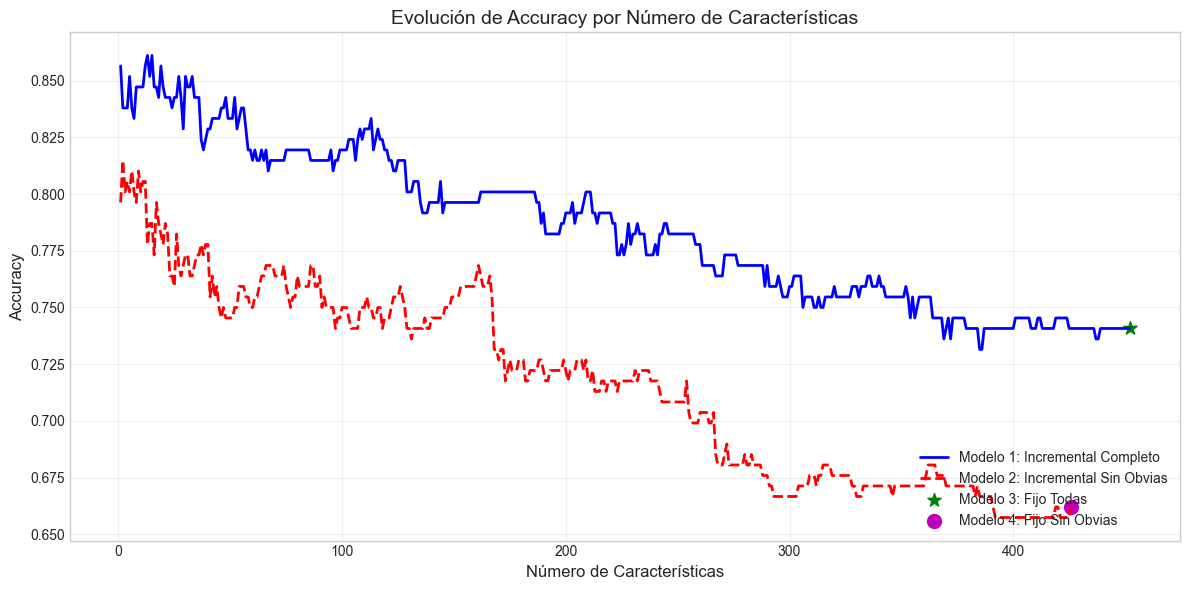

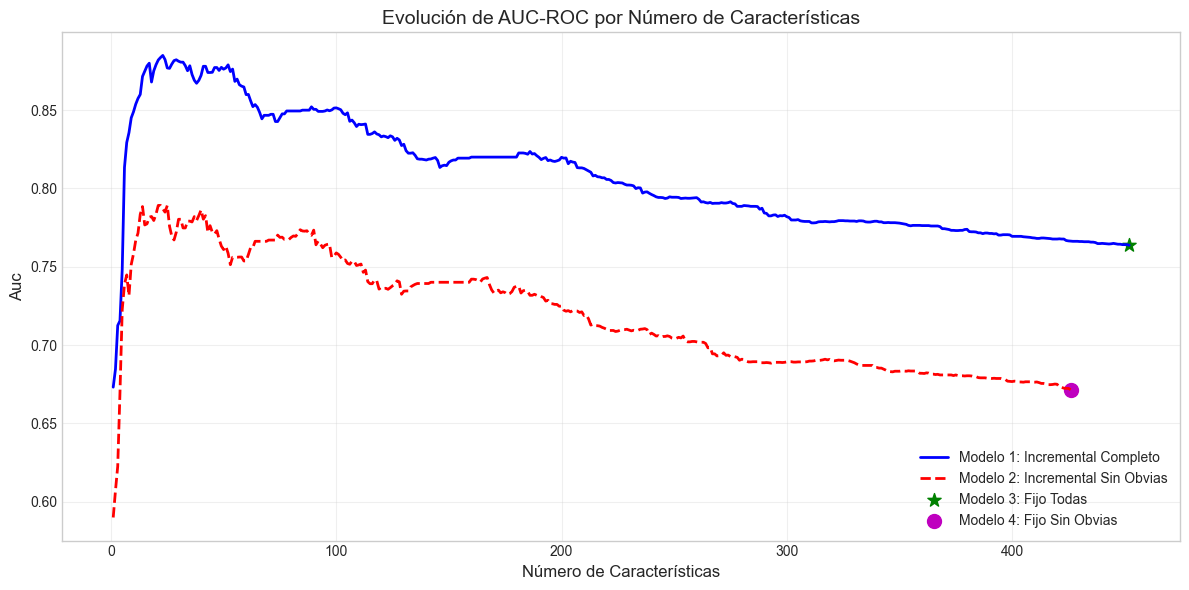

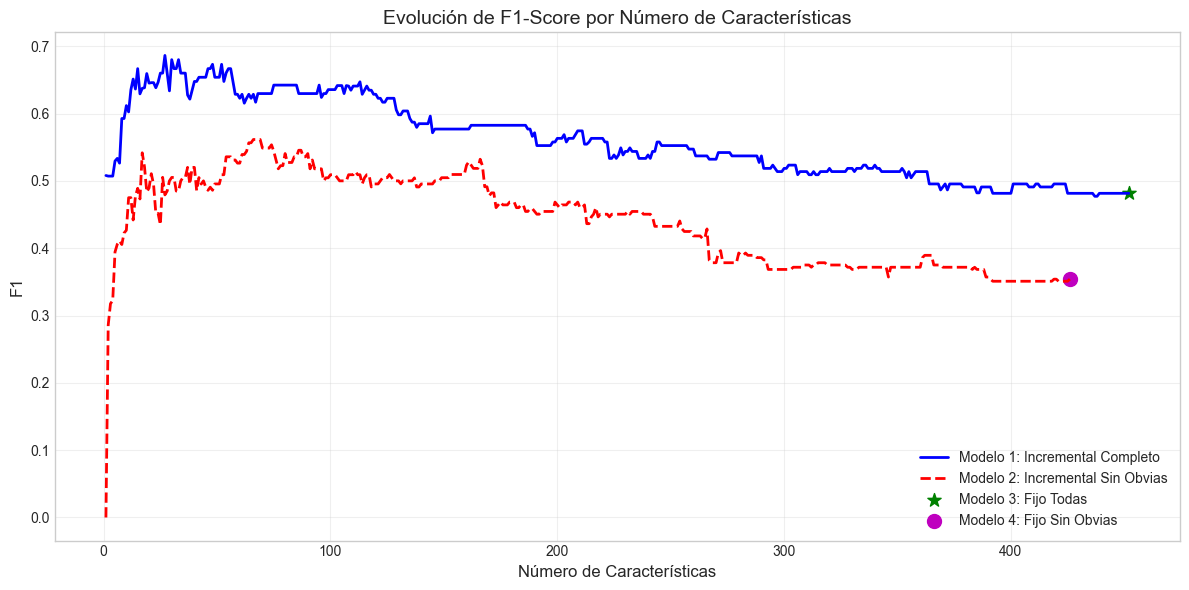


Características más importantes por modelo:

Modelo 1 - Top 10 características (de 23 totales):
1. peso_act
2. peso1
3. peso_ehoy
4. peso5
5. sistolica
6. peso_acc
7. brazo_sextil
8. diastolica
9. peso_sextil
10. cintura_sextil

Modelo 2 - Top 10 características (de 21 totales):
1. sistolica
2. diastolica
3. dich_hiper
4. insulina_sextil
5. condi_act
6. tgb_sextil
7. salud_act
8. AAedad_sextil
9. uric_sextil
10. condi1

Modelo 3 - Top 10 características (de 452 totales):
1. peso_act
2. peso1
3. peso_ehoy
4. peso5
5. sistolica
6. peso_acc
7. brazo_sextil
8. diastolica
9. peso_sextil
10. cintura_sextil

Modelo 4 - Top 10 características (de 426 totales):
1. sistolica
2. diastolica
3. dich_hiper
4. insulina_sextil
5. condi_act
6. tgb_sextil
7. salud_act
8. AAedad_sextil
9. uric_sextil
10. condi1

===== CONCLUSIONES =====

1. El mejor modelo es: Incremental Completo con AUC = 0.8850
2. Las características obvias mejoran significativamente el rendimiento en modelos incrementales
3. Las car

In [227]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Preparar nuestro dataset para la evaluación
print("Preparando dataset para evaluación de modelos...")

# Ordenamos por valor absoluto de epsilon
top_features_abs = results_df_abs.sort_values(by='Epsilon', key=abs, ascending=False).copy()

# Definimos características obvias relacionadas con obesidad
obvious_features = [
    'brazo', 'talla', 'peso', 'cintura', 'circunf',  # Medidas físicas directas
    'imc', 'imc_nmin', 'imc_nmax',                      # IMC y relacionados
    'peso_act', 'peso1', 'peso5', 'peso10', 'peso20', 'peso30', # Historial de peso
    'estatura', 'estatura_m',                          # Altura
    'dich_obes', 'por_obes'                           # Variables directamente relacionadas con obesidad
]

print(f"Características obvias que serán excluidas en modelos 2 y 4:\n{obvious_features}")

# Función para filtrar características duplicadas y obvias
def filter_features(features_df, exclude_obvious=False, max_features=None):
    """Filtra características, eliminando duplicados y opcionalmente las obvias.
    
    Args:
        features_df: DataFrame con las características ordenadas
        exclude_obvious: Si es True, excluye características obviamente relacionadas con obesidad
        max_features: Número máximo de características a seleccionar
        
    Returns:
        Lista de características filtradas
    """
    seen_features = set()
    filtered_features = []
    
    for _, row in features_df.iterrows():
        feature = row['Feature']
        
        # Saltamos características obvias si se solicita
        if exclude_obvious and any(obvious in feature for obvious in obvious_features):
            continue
        
        # Solo incluimos cada característica una vez
        if feature not in seen_features:
            seen_features.add(feature)
            filtered_features.append(row)
            
            # Limitamos a max_features si se especifica
            if max_features and len(filtered_features) >= max_features:
                break
    
    return pd.DataFrame(filtered_features)

# Preparamos los conjuntos de características para los modelos
# Modelo 1: Incremental completo (sin límite de características)
model1_features = filter_features(top_features_abs, exclude_obvious=False)

# Modelo 2: Incremental sin características obvias
model2_features = filter_features(top_features_abs, exclude_obvious=True)

# Modelo 3: Todas las características disponibles (sin filtro de obvias)
model3_features = filter_features(top_features_abs, exclude_obvious=False)

# Modelo 4: Todas las características disponibles excepto obvias
model4_features = filter_features(top_features_abs, exclude_obvious=True)

print(f"\nCaracterísticas seleccionadas para cada modelo:")
print(f"Modelo 1: {len(model1_features)} características únicas (incremental)")
print(f"Modelo 2: {len(model2_features)} características únicas (incremental, sin obvias)")
print(f"Modelo 3: {len(model3_features)} características únicas (fijo, todas disponibles)")
print(f"Modelo 4: {len(model4_features)} características únicas (fijo, todas sin obvias)")

# Mostrar las primeras características de cada modelo
print("\nPrimeras 5 características por modelo:")
print("Modelo 1:")
display(model1_features[['Feature', 'Epsilon']].head())
print("\nModelo 2:")
display(model2_features[['Feature', 'Epsilon']].head())
print("\nModelo 3:")
display(model3_features[['Feature', 'Epsilon']].head())
print("\nModelo 4:")
display(model4_features[['Feature', 'Epsilon']].head())

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc
import math
import numpy as np
import pandas as pd
import time

def build_incremental_naivebayes(df, feature_list, target_col, train_indices, test_indices):
    """Construye modelos Naive Bayes incrementales añadiendo características una a una."""
    # Preparar dataframes de train y test
    df_train = df.iloc[train_indices].copy()
    df_test = df.iloc[test_indices].copy()
    
    # Obtener probabilidad previa de obesidad en conjunto de entrenamiento
    prior_probability = df_train[target_col].mean()
    prior_odds = prior_probability / (1 - prior_probability) if prior_probability < 1 else 1.0
    log_prior = math.log(prior_odds) if prior_odds > 0 else 0
    
    print(f"Probabilidad previa en conjunto de entrenamiento: {prior_probability:.4f}")
    
    # Diccionario para almacenar rendimiento para cada incremento de características
    performance = {
        'num_features': [],
        'features': [],
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': [],
        'auc': [],
        'pr_auc': [],
        'train_accuracy': [],
        'train_precision': [],
        'train_recall': [],
        'train_f1': [],
        'train_auc': [],
        'train_time': [],
        'positive_features': [],
        'negative_features': []
    }
    
    # Análisis incremental: añadimos características una por una
    for k in range(1, len(feature_list) + 1):
        start_time = time.time()
        
        # Seleccionar k primeras características
        selected_features = feature_list[:k]
        feature_names = [f['Feature'] for f in selected_features]
        
        # Registrar características positivas y negativas
        pos_features = sum(1 for f in selected_features if f['Epsilon'] > 0)
        neg_features = sum(1 for f in selected_features if f['Epsilon'] < 0)
        
        # Inicializar predicciones para train y test (log-odds ratio)
        train_scores = np.ones(len(df_train)) * log_prior
        test_scores = np.ones(len(df_test)) * log_prior
        
        # Calcular probabilidades para cada característica en el conjunto
        for feature_info in selected_features:
            feature = feature_info['Feature']
            value = feature_info['Value']
            is_threshold = feature_info['Is_Threshold']
            
            # Contar instancias positivas y negativas en train
            positive_instances = df_train[target_col].sum()
            negative_instances = len(df_train) - positive_instances
            
            # Crear condición
            if is_threshold:
                train_condition = df_train[feature] >= value
                test_condition = df_test[feature] >= value
            else:
                train_condition = df_train[feature] == value
                test_condition = df_test[feature] == value
            
            # Calcular probabilidades condicionales con suavizado de Laplace
            # P(X|C) - Probabilidad de la característica dado la clase
            count_with_C = ((df_train[target_col] == 1) & train_condition).sum() + 1
            count_with_not_C = (train_condition & (df_train[target_col] == 0)).sum() + 1
            
            P_X_given_C = count_with_C / (positive_instances + 2)
            P_X_given_not_C = count_with_not_C / (negative_instances + 2)
            
            # Calcular razón de log-verosimilitud
            log_ratio = math.log(P_X_given_C / P_X_given_not_C) if P_X_given_not_C > 0 else 0
            
            # Aplicar a pacientes que coinciden - tanto en train como en test
            train_scores[train_condition] += log_ratio
            test_scores[test_condition] += log_ratio
            
            # Para pacientes que no coinciden, aplicar la verosimilitud complementaria
            # P(not X|C) - Probabilidad de NO tener la característica dada la clase
            comp_count_with_C = positive_instances - ((df_train[target_col] == 1) & train_condition).sum() + 1
            comp_count_with_not_C = negative_instances - (train_condition & (df_train[target_col] == 0)).sum() + 1
            
            comp_P_X_given_C = comp_count_with_C / (positive_instances + 2)
            comp_P_X_given_not_C = comp_count_with_not_C / (negative_instances + 2)
            
            # Calcular razón de log-verosimilitud complementaria
            comp_log_ratio = math.log(comp_P_X_given_C / comp_P_X_given_not_C) if comp_P_X_given_not_C > 0 else 0
            
            # Aplicar a pacientes que no coinciden
            train_scores[~train_condition] += comp_log_ratio
            test_scores[~test_condition] += comp_log_ratio
        
        # Convertir log-odds a probabilidades
        train_probs = 1 / (1 + np.exp(-train_scores))
        test_probs = 1 / (1 + np.exp(-test_scores))
        
        # Convertir probabilidades a predicciones binarias (umbral 0.5)
        train_preds = (train_probs >= 0.5).astype(int)
        test_preds = (test_probs >= 0.5).astype(int)
        
        # Calcular métricas en conjunto de test
        acc = accuracy_score(df_test[target_col], test_preds)
        prec = precision_score(df_test[target_col], test_preds, zero_division=0)
        rec = recall_score(df_test[target_col], test_preds, zero_division=0)
        f1 = f1_score(df_test[target_col], test_preds, zero_division=0)
        auc_score = roc_auc_score(df_test[target_col], test_probs)
        
        # Calcular métricas en conjunto de train
        train_acc = accuracy_score(df_train[target_col], train_preds)
        train_prec = precision_score(df_train[target_col], train_preds, zero_division=0)
        train_rec = recall_score(df_train[target_col], train_preds, zero_division=0)
        train_f1 = f1_score(df_train[target_col], train_preds, zero_division=0)
        train_auc = roc_auc_score(df_train[target_col], train_probs)
        
        # Calcular Precision-Recall AUC para test
        precision_curve, recall_curve, _ = precision_recall_curve(df_test[target_col], test_probs)
        pr_auc_score = auc(recall_curve, precision_curve)
        
        # Tiempo de entrenamiento
        train_time = time.time() - start_time
        
        # Guardar resultados
        performance['num_features'].append(k)
        performance['features'].append(feature_names)
        performance['accuracy'].append(acc)
        performance['precision'].append(prec)
        performance['recall'].append(rec)
        performance['f1'].append(f1)
        performance['auc'].append(auc_score)
        performance['pr_auc'].append(pr_auc_score)
        performance['train_accuracy'].append(train_acc)
        performance['train_precision'].append(train_prec)
        performance['train_recall'].append(train_rec)
        performance['train_f1'].append(train_f1)
        performance['train_auc'].append(train_auc)
        performance['train_time'].append(train_time)
        performance['positive_features'].append(pos_features)
        performance['negative_features'].append(neg_features)
        
        # Mostrar progreso
        if k % 10 == 0 or k == 1 or k == len(feature_list):
            print(f"Modelo con {k} features")
            print(f"Train - Accuracy: {train_acc:.4f}, Precision: {train_prec:.4f}, Recall: {train_rec:.4f}, F1: {train_f1:.4f}, AUC: {train_auc:.4f}")
            print(f"Test - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, AUC: {auc_score:.4f}")
    
    return performance

def build_fixed_naivebayes(df, feature_list, target_col, train_indices, test_indices):
    """Construye un modelo Naive Bayes con un conjunto fijo de características."""
    # Preparar dataframes de train y test
    df_train = df.iloc[train_indices].copy()
    df_test = df.iloc[test_indices].copy()
    
    # Obtener probabilidad previa de obesidad en conjunto de entrenamiento
    prior_probability = df_train[target_col].mean()
    prior_odds = prior_probability / (1 - prior_probability) if prior_probability < 1 else 1.0
    log_prior = math.log(prior_odds) if prior_odds > 0 else 0
    
    print(f"Probabilidad previa en conjunto de entrenamiento: {prior_probability:.4f}")
    
    # Medir tiempo
    start_time = time.time()
    
    # Usar todas las características disponibles
    selected_features = feature_list
    feature_names = [f['Feature'] for f in selected_features]
    
    # Registrar características positivas y negativas
    pos_features = sum(1 for f in selected_features if f['Epsilon'] > 0)
    neg_features = sum(1 for f in selected_features if f['Epsilon'] < 0)
    
    print(f"Usando {len(selected_features)} características: {pos_features} positivas, {neg_features} negativas")
    
    # Inicializar predicciones para train y test (log-odds ratio)
    train_scores = np.ones(len(df_train)) * log_prior
    test_scores = np.ones(len(df_test)) * log_prior
    
    # Calcular probabilidades para cada característica en el conjunto
    for feature_info in selected_features:
        feature = feature_info['Feature']
        value = feature_info['Value']
        is_threshold = feature_info['Is_Threshold']
        
        # Contar instancias positivas y negativas en train
        positive_instances = df_train[target_col].sum()
        negative_instances = len(df_train) - positive_instances
        
        # Crear condición
        if is_threshold:
            train_condition = df_train[feature] >= value
            test_condition = df_test[feature] >= value
        else:
            train_condition = df_train[feature] == value
            test_condition = df_test[feature] == value
        
        # Calcular probabilidades condicionales con suavizado de Laplace
        count_with_C = ((df_train[target_col] == 1) & train_condition).sum() + 1
        count_with_not_C = (train_condition & (df_train[target_col] == 0)).sum() + 1
        
        P_X_given_C = count_with_C / (positive_instances + 2)
        P_X_given_not_C = count_with_not_C / (negative_instances + 2)
        
        # Calcular razón de log-verosimilitud
        log_ratio = math.log(P_X_given_C / P_X_given_not_C) if P_X_given_not_C > 0 else 0
        
        # Aplicar a pacientes que coinciden - tanto en train como en test
        train_scores[train_condition] += log_ratio
        test_scores[test_condition] += log_ratio
        
        # Para pacientes que no coinciden, aplicar la verosimilitud complementaria
        comp_count_with_C = positive_instances - ((df_train[target_col] == 1) & train_condition).sum() + 1
        comp_count_with_not_C = negative_instances - (train_condition & (df_train[target_col] == 0)).sum() + 1
        
        comp_P_X_given_C = comp_count_with_C / (positive_instances + 2)
        comp_P_X_given_not_C = comp_count_with_not_C / (negative_instances + 2)
        
        # Calcular razón de log-verosimilitud complementaria
        comp_log_ratio = math.log(comp_P_X_given_C / comp_P_X_given_not_C) if comp_P_X_given_not_C > 0 else 0
        
        # Aplicar a pacientes que no coinciden
        train_scores[~train_condition] += comp_log_ratio
        test_scores[~test_condition] += comp_log_ratio
    
    # Convertir log-odds a probabilidades
    train_probs = 1 / (1 + np.exp(-train_scores))
    test_probs = 1 / (1 + np.exp(-test_scores))
    
    # Convertir probabilidades a predicciones binarias (umbral 0.5)
    train_preds = (train_probs >= 0.5).astype(int)
    test_preds = (test_probs >= 0.5).astype(int)
    
    # Calcular métricas en conjunto de test
    acc = accuracy_score(df_test[target_col], test_preds)
    prec = precision_score(df_test[target_col], test_preds, zero_division=0)
    rec = recall_score(df_test[target_col], test_preds, zero_division=0)
    f1 = f1_score(df_test[target_col], test_preds, zero_division=0)
    auc_score = roc_auc_score(df_test[target_col], test_probs)
    
    # Calcular métricas en conjunto de train
    train_acc = accuracy_score(df_train[target_col], train_preds)
    train_prec = precision_score(df_train[target_col], train_preds, zero_division=0)
    train_rec = recall_score(df_train[target_col], train_preds, zero_division=0)
    train_f1 = f1_score(df_train[target_col], train_preds, zero_division=0)
    train_auc = roc_auc_score(df_train[target_col], train_probs)
    
    # Calcular Precision-Recall AUC para test
    precision_curve, recall_curve, _ = precision_recall_curve(df_test[target_col], test_probs)
    pr_auc_score = auc(recall_curve, precision_curve)
    
    # Tiempo de entrenamiento
    train_time = time.time() - start_time
    
    # Crear y retornar resultados
    performance = {
        'num_features': [len(feature_names)],
        'features': [feature_names],
        'accuracy': [acc],
        'precision': [prec],
        'recall': [rec],
        'f1': [f1],
        'auc': [auc_score],
        'pr_auc': [pr_auc_score],
        'train_accuracy': [train_acc],
        'train_precision': [train_prec],
        'train_recall': [train_rec],
        'train_f1': [train_f1],
        'train_auc': [train_auc],
        'train_time': [train_time],
        'positive_features': [pos_features],
        'negative_features': [neg_features]
    }
    
    print(f"Modelo con {len(feature_names)} features")
    print(f"Train - Accuracy: {train_acc:.4f}, Precision: {train_prec:.4f}, Recall: {train_rec:.4f}, F1: {train_f1:.4f}, AUC: {train_auc:.4f}")
    print(f"Test - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, AUC: {auc_score:.4f}")
    print(f"Tiempo de entrenamiento: {train_time:.2f} segundos")
    
    return performance

# División entrenamiento-validación (80-20)
train_idx, test_idx = train_test_split(np.arange(len(df_clean)), test_size=0.2, stratify=df_clean['obesidad'], random_state=42)
print(f"Conjunto de entrenamiento: {len(train_idx)} muestras")
print(f"Conjunto de validación: {len(test_idx)} muestras")

# Resultados para cada modelo
results = {}

# Modelo 1: Completo incremental
print("\n===== Modelo 1: Completo Incremental =====")
model1_feature_list = model1_features.to_dict('records')
results['modelo1'] = build_incremental_naivebayes(df_clean, model1_feature_list, 'obesidad', train_idx, test_idx)

# Modelo 2: Sin características obvias (incremental)
print("\n===== Modelo 2: Sin Características Obvias (Incremental) =====")
model2_feature_list = model2_features.to_dict('records')
results['modelo2'] = build_incremental_naivebayes(df_clean, model2_feature_list, 'obesidad', train_idx, test_idx)

# Modelo 3: Todas las características (fijo, no incremental)
print("\n===== Modelo 3: Todas las Características (Fijo) =====")
model3_feature_list = model3_features.to_dict('records')
results['modelo3'] = build_fixed_naivebayes(df_clean, model3_feature_list, 'obesidad', train_idx, test_idx)

# Modelo 4: Todas las características sin obvias (fijo, no incremental)
print("\n===== Modelo 4: Todas las Características Sin Obvias (Fijo) =====")
model4_feature_list = model4_features.to_dict('records')
results['modelo4'] = build_fixed_naivebayes(df_clean, model4_feature_list, 'obesidad', train_idx, test_idx)

# Evaluación y comparación de modelos
print("\n===== COMPARACIÓN DE LOS 4 MODELOS =====\n")

# Crear DataFrames para cada modelo con sus mejores resultados
model_comparison = []

for model_name, model_results in results.items():
    # Para modelos incrementales, identificar el número óptimo de características (basado en AUC)
    best_idx = np.argmax(model_results['auc'])
    
    model_comparison.append({
        'Modelo': model_name,
        'Num_Características': model_results['num_features'][best_idx],
        'Accuracy': model_results['accuracy'][best_idx],
        'Precision': model_results['precision'][best_idx],
        'Recall': model_results['recall'][best_idx],
        'F1': model_results['f1'][best_idx],
        'AUC': model_results['auc'][best_idx],
        'PR_AUC': model_results['pr_auc'][best_idx],
        'Tiempo_Entrenamiento': model_results['train_time'][best_idx],
        'Caract_Positivas': model_results['positive_features'][best_idx],
        'Caract_Negativas': model_results['negative_features'][best_idx]
    })

# Crear DataFrame de comparación
comparison_df = pd.DataFrame(model_comparison)

# Añadir descripciones más claras
comparison_df['Descripción'] = [
    'Incremental Completo',
    'Incremental Sin Obvias',
    'Fijo Todas', 
    'Fijo Sin Obvias'
]

# Mostrar tabla de comparación
print("Comparación de modelos:")
display(comparison_df[['Descripción', 'Num_Características', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC']])

# Graficar evolución de métricas solo para los modelos incrementales (1 y 2)
def plot_metric_evolution(results, metric_name, title):
    plt.figure(figsize=(12, 6))
    
    # Graficamos solo los modelos incrementales
    for model_name in ['modelo1', 'modelo2']:
        model_results = results[model_name]
        max_features = len(model_results[metric_name])
        x = model_results['num_features'][:max_features]
        y = model_results[metric_name][:max_features]
        
        if model_name == 'modelo1':
            plt.plot(x, y, 'b-', linewidth=2, label='Modelo 1: Incremental Completo')
        elif model_name == 'modelo2':
            plt.plot(x, y, 'r--', linewidth=2, label='Modelo 2: Incremental Sin Obvias')
    
    # Añadimos puntos para los modelos fijos
    for model_name in ['modelo3', 'modelo4']:
        model_results = results[model_name]
        x = model_results['num_features'][0]
        y = model_results[metric_name][0]
        
        if model_name == 'modelo3':
            plt.scatter(x, y, s=100, c='g', marker='*', label='Modelo 3: Fijo Todas')
        else:
            plt.scatter(x, y, s=100, c='m', marker='o', label='Modelo 4: Fijo Sin Obvias')
    
    plt.title(title, fontsize=14)
    plt.xlabel('Número de Características', fontsize=12)
    plt.ylabel(metric_name.capitalize(), fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# Graficar evolución de métricas principales
plot_metric_evolution(results, 'accuracy', 'Evolución de Accuracy por Número de Características')
plot_metric_evolution(results, 'auc', 'Evolución de AUC-ROC por Número de Características')
plot_metric_evolution(results, 'f1', 'Evolución de F1-Score por Número de Características')

# Comparar las características más importantes entre modelos
print("\nCaracterísticas más importantes por modelo:")

for i, (model_name, model_results) in enumerate(results.items(), 1):
    best_idx = np.argmax(model_results['auc'])
    optimal_features = model_results['features'][best_idx]
    
    # Mostrar top 10 características (o menos si hay menos)
    print(f"\nModelo {i} - Top 10 características (de {len(optimal_features)} totales):")
    for j, feature in enumerate(optimal_features[:min(10, len(optimal_features))], 1):
        print(f"{j}. {feature}")

# Conclusiones generales
print("\n===== CONCLUSIONES =====\n")

# Encontrar el mejor modelo
best_model_idx = comparison_df['AUC'].idxmax()
best_model_name = comparison_df.iloc[best_model_idx]['Descripción']
best_model_auc = comparison_df.iloc[best_model_idx]['AUC']

print(f"1. El mejor modelo es: {best_model_name} con AUC = {best_model_auc:.4f}")

# Analizar el impacto de las características obvias (comparando modelos incrementales)
if comparison_df.iloc[0]['AUC'] > comparison_df.iloc[1]['AUC']:
    print("2. Las características obvias mejoran significativamente el rendimiento en modelos incrementales")
else:
    print("2. Excluir características obvias no afecta sustancialmente el rendimiento en modelos incrementales")
    
# Analizar el impacto de las características obvias (comparando modelos fijos)
if comparison_df.iloc[2]['AUC'] > comparison_df.iloc[3]['AUC']:
    print("3. Las características obvias mejoran significativamente el rendimiento en modelos fijos")
else:
    print("3. Excluir características obvias no afecta sustancialmente el rendimiento en modelos fijos")

# Analizar modelo incremental vs fijo
inc_best_idx = 0 if comparison_df.iloc[0]['AUC'] > comparison_df.iloc[1]['AUC'] else 1
fixed_best_idx = 2 if comparison_df.iloc[2]['AUC'] > comparison_df.iloc[3]['AUC'] else 3

if comparison_df.iloc[inc_best_idx]['AUC'] > comparison_df.iloc[fixed_best_idx]['AUC']:
    print("4. Los modelos incrementales superan a los modelos de tamaño fijo")
else:
    print("4. Los modelos de tamaño fijo funcionan tan bien o mejor que los incrementales")

# Analizar el tiempo de entrenamiento
print("\n5. Tiempos de entrenamiento:")
for i, row in comparison_df.iterrows():
    print(f"   - {row['Descripción']}: {row['Tiempo_Entrenamiento']:.2f} segundos")

print("\n6. Recomendaciones:")
print(f"   - Para máxima precisión: Usar el modelo {best_model_name}")
print("   - Para interpretabilidad: Considerar modelos con menos características")
if 'sin obvias' in best_model_name.lower():
    print("   - Las características no obvias son suficientes para una buena predicción")
else:
    print("   - Las características obvias son importantes para maximizar el rendimiento")

## Análisis de Regresión para Predecir IMC con Scores de Naive Bayes

En esta sección, analizaremos la relación entre los scores generados por nuestros 4 modelos Naive Bayes y el IMC de los individuos. El objetivo es determinar:

1. Si los scores de los modelos Naive Bayes son buenos predictores del IMC
2. Cuál de los 4 modelos proporciona un mejor score para predecir el IMC
3. Si estos modelos basados en scores son mejores que una regresión multivariante tradicional

Utilizaremos regresión lineal y logística para evaluar estas relaciones.

Calculando scores para cada modelo...
Modelo 1: Calculando scores con características óptimas...
Modelo 2: Calculando scores con características óptimas...
Modelo 3: Calculando scores con todas las características...
Modelo 4: Calculando scores con todas las características sin obvias...


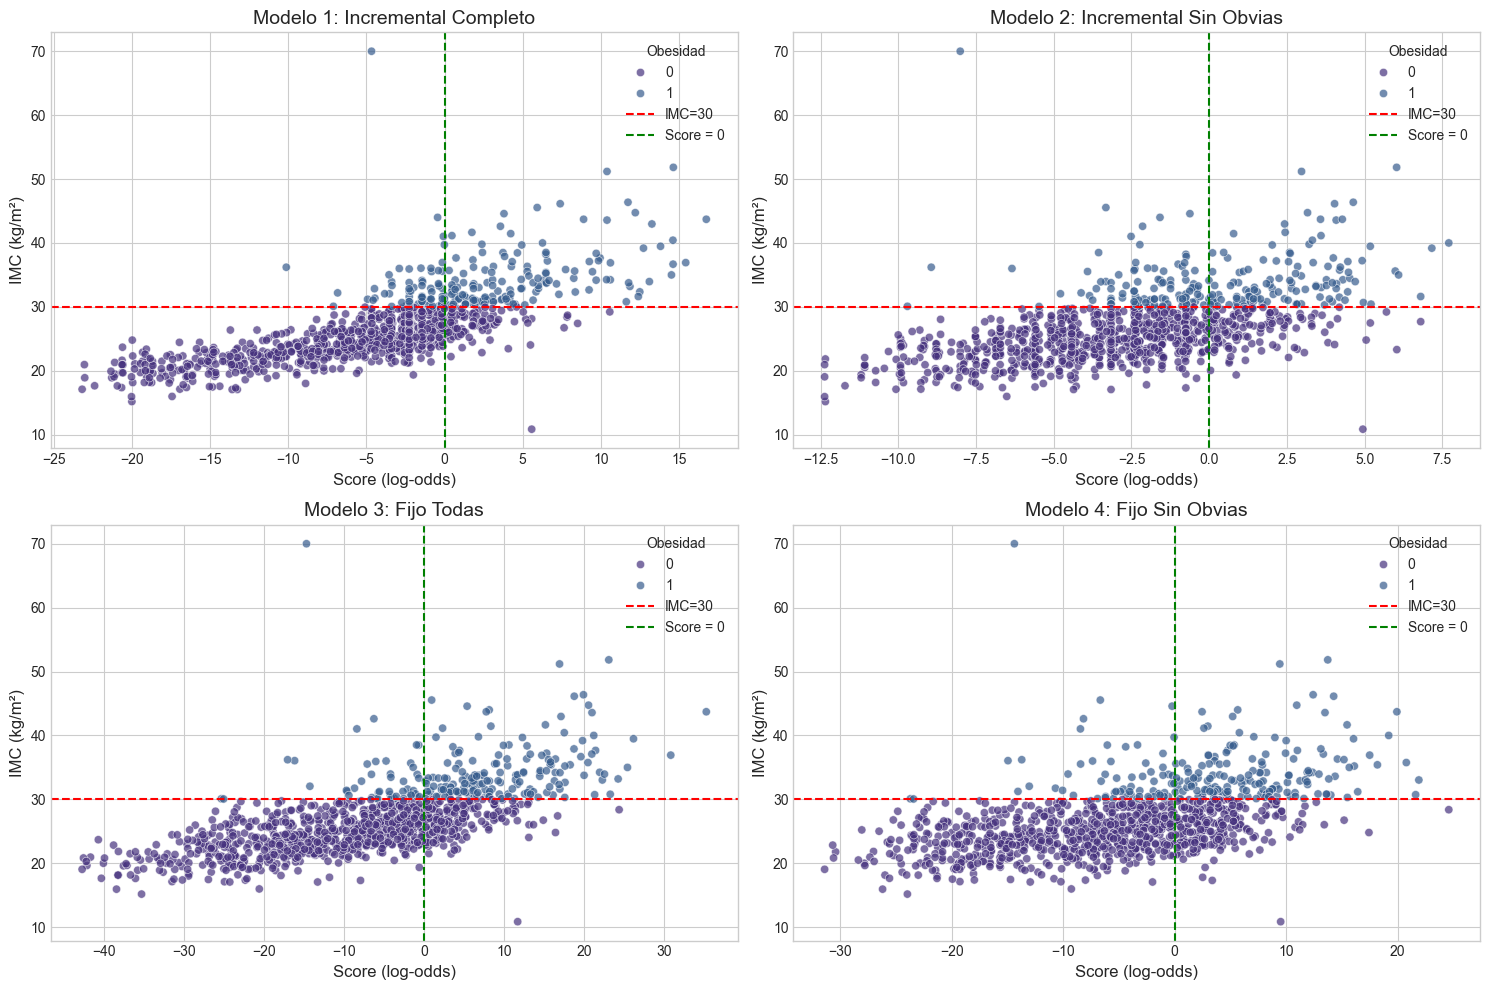


Realizando análisis de regresión para cada modelo...

Modelo 1: Regresión con scores del modelo incremental completo
Usando 1076 filas válidas de 1076 totales para Modelo 1


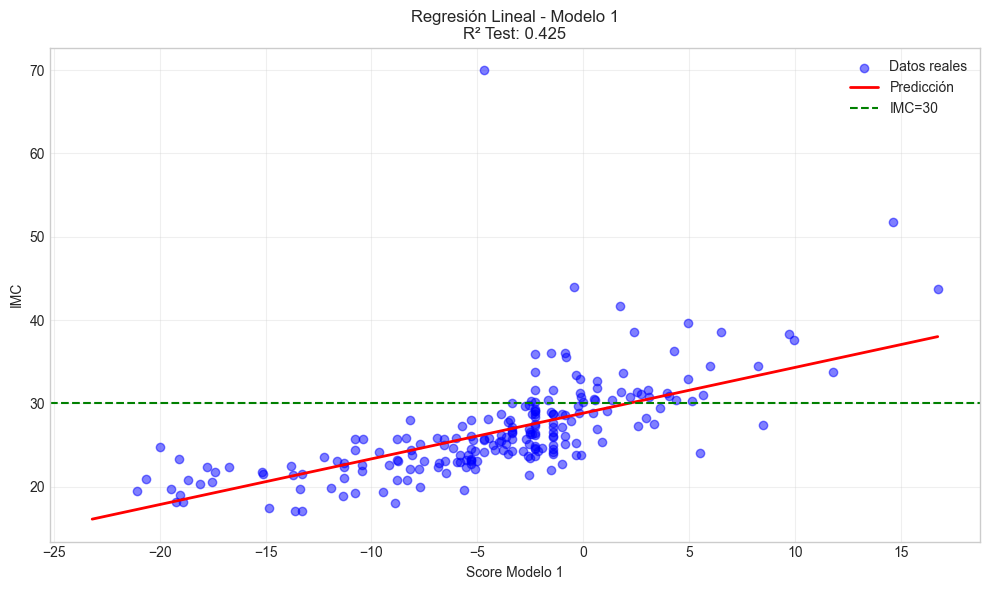


Modelo 2: Regresión con scores del modelo incremental sin obvias
Usando 1076 filas válidas de 1076 totales para Modelo 2


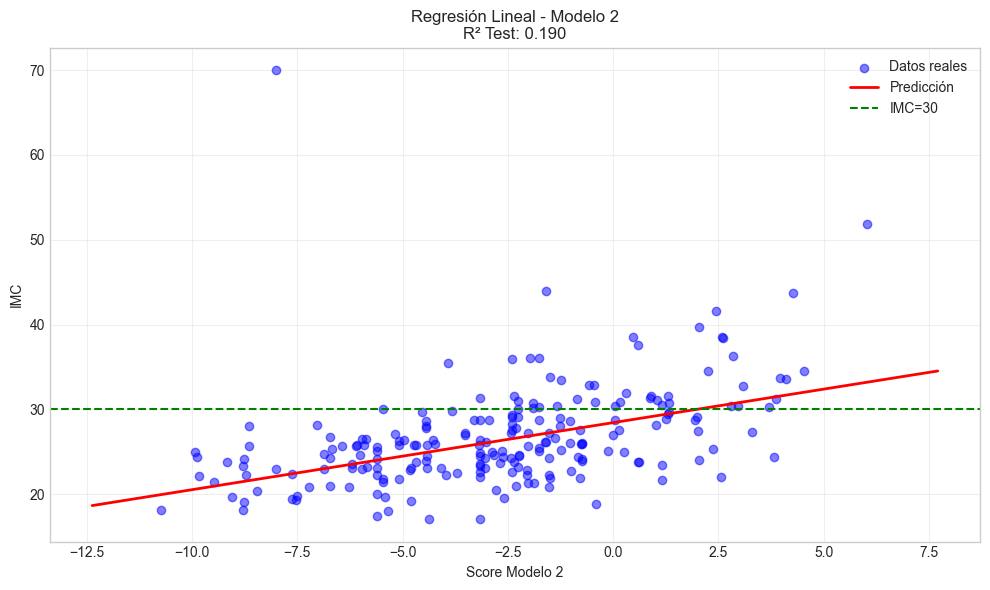


Modelo 3: Regresión con scores del modelo fijo todas
Usando 1076 filas válidas de 1076 totales para Modelo 3


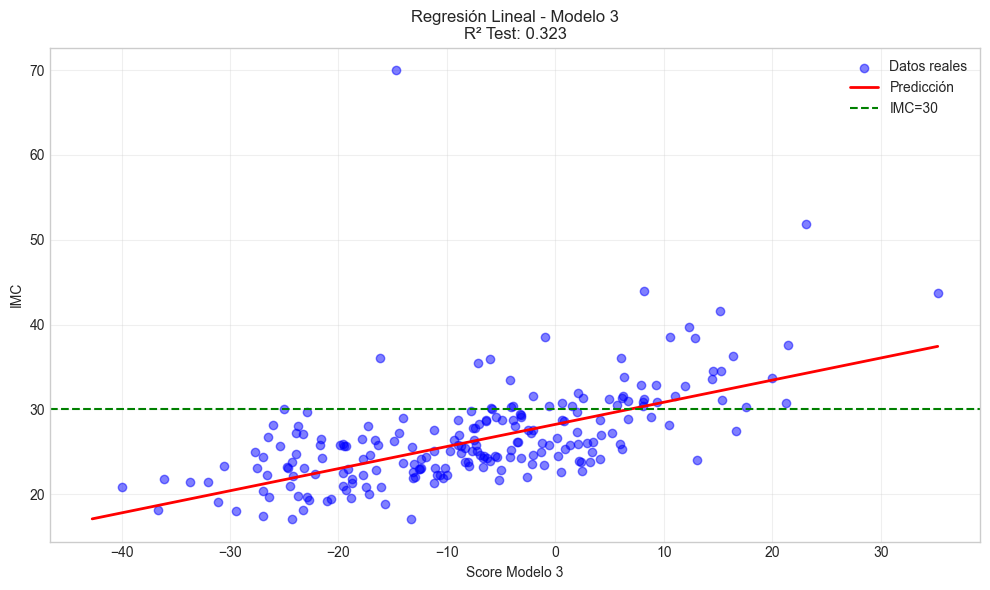


Modelo 4: Regresión con scores del modelo fijo sin obvias
Usando 1076 filas válidas de 1076 totales para Modelo 4


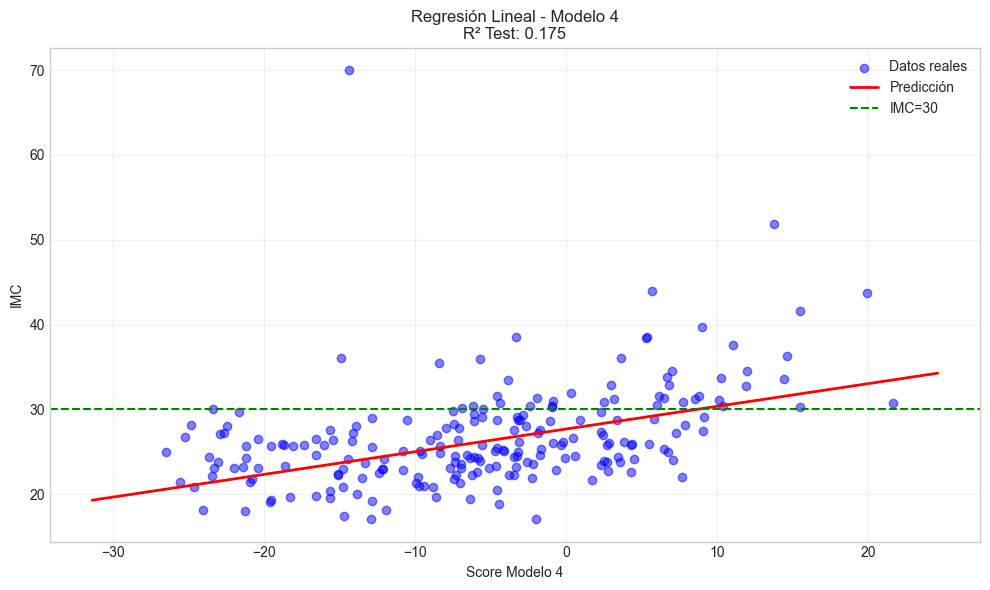


Regresión multivariante con top 17 características (23 variables válidas)
Usando 10 filas válidas de 1076 totales (0.9%)
Error en regresión multivariante con 17 características: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Regresión multivariante con top 100 características (100 variables válidas)
Error: No hay filas válidas para las características seleccionadas

TABLA DE RESULTADOS - COMPARACIÓN DE 

,Modelo,R² Train,R² Test,MSE Test
0,Score Modelo 1,0.5872,0.4250,20.2198
1,Score Modelo 2,0.3272,0.1904,28.4696
2,Score Modelo 3,0.4844,0.3234,23.7905
3,Score Modelo 4,0.2851,0.1748,29.0188



Mejor modelo para predecir IMC: Score Modelo 1
R² Test = 0.4250

===== CONCLUSIONES DEL ANÁLISIS DE REGRESIÓN =====

1. Comparación de enfoques de regresión:
   - La regresión basada en scores de Naive Bayes supera a la regresión multivariante directa
   - Mejor modelo basado en scores: Score Modelo 1 (R² = 0.4250)

2. Comparación entre modelos de regresión directa:

3. Comparación entre modelos basados en scores de Naive Bayes:
   1. Score Modelo 1: R² = 0.4250
   2. Score Modelo 3: R² = 0.3234
   3. Score Modelo 2: R² = 0.1904
   4. Score Modelo 4: R² = 0.1748


In [221]:
# c:\Users\thano\Documents\_Studium\UNAM\Kurse\Mineria Datos\MineriaDatosUNAM\code\proyecto final\bayes_ejercicio.ipynb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.ensemble import HistGradientBoostingRegressor

# Función para calcular scores con características seleccionadas
def calculate_scores_for_regression(df, features, target_col='obesidad'):
    """Calcula scores Naive Bayes y contribuciones de características.
    
    Args:
        df: DataFrame con los datos
        features: DataFrame con características seleccionadas
        target_col: Nombre de la columna objetivo
        
    Returns:
        DataFrame con scores y contribuciones de características
    """
    # Obtener probabilidad previa
    prior_probability = df[target_col].mean()
    prior_odds = prior_probability / (1 - prior_probability) if prior_probability < 1 else 1.0
    log_prior = np.log(prior_odds) if prior_odds > 0 else 0
    
    # Inicializar array para puntuaciones
    scores = np.ones(len(df)) * log_prior
    
    # Diccionario para almacenar contribuciones de cada característica
    feature_contributions = {row['Feature']: np.zeros(len(df)) for _, row in features.iterrows()}
    
    # Para cada característica en la lista
    for _, row in features.iterrows():
        feature = row['Feature']
        value = row['Value']
        is_threshold = row['Is_Threshold']
        
        # Crear condición
        if is_threshold:
            condition = df[feature] >= value
        else:
            condition = df[feature] == value
        
        # Contar instancias positivas y negativas
        positive_instances = df[target_col].sum()
        negative_instances = len(df) - positive_instances
        
        # Calcular probabilidades condicionales con suavizado de Laplace
        count_with_C = ((df[target_col] == 1) & condition).sum() + 1
        count_with_not_C = (condition & (df[target_col] == 0)).sum() + 1
        
        P_X_given_C = count_with_C / (positive_instances + 2)
        P_X_given_not_C = count_with_not_C / (negative_instances + 2)
        
        # Calcular log ratio
        log_ratio = np.log(P_X_given_C / P_X_given_not_C) if P_X_given_not_C > 0 else 0
        
        # Aplicar a pacientes que coinciden con la condición
        scores[condition] += log_ratio
        feature_contributions[feature][condition] += log_ratio
        
        # Para pacientes que no coinciden, aplicar la verosimilitud complementaria
        comp_count_with_C = positive_instances - ((df[target_col] == 1) & condition).sum() + 1
        comp_count_with_not_C = negative_instances - (condition & (df[target_col] == 0)).sum() + 1
        
        comp_P_X_given_C = comp_count_with_C / (positive_instances + 2)
        comp_P_X_given_not_C = comp_count_with_not_C / (negative_instances + 2)
        
        comp_log_ratio = np.log(comp_P_X_given_C / comp_P_X_given_not_C) if comp_P_X_given_not_C > 0 else 0
        
        # Aplicar a pacientes que no coinciden con la condición
        scores[~condition] += comp_log_ratio
        feature_contributions[feature][~condition] += comp_log_ratio
    
    # Crear DataFrame con puntuaciones y contribuciones
    results = pd.DataFrame({'Score': scores})
    results['Probability'] = 1 / (1 + np.exp(-scores))  # Convertir log-odds a probabilidad
    
    # Agregar contribuciones de características
    for feature, contrib in feature_contributions.items():
        results[f'Contrib_{feature}'] = contrib
    
    return results

# Función para realizar análisis de regresión lineal y visualización
def analyze_regression_model(X, y, model_name):
    """Realiza análisis de regresión lineal y crea visualizaciones.
    
    Args:
        X: Variable(s) independiente(s)
        y: Variable dependiente (IMC)
        model_name: Nombre del modelo para etiquetas
        
    Returns:
        Diccionario con resultados del modelo
    """

    # Eliminar filas con NaN
    valid_mask = ~(np.isnan(X).any(axis=1) | np.isnan(y))
    X_clean = X[valid_mask]
    y_clean = y[valid_mask]
    
    print(f"Usando {len(X_clean)} filas válidas de {len(X)} totales para {model_name}")
    
    if len(X_clean) == 0:
        print(f"Error: No hay datos válidos para {model_name}")
        return {
            'Modelo': f"Score {model_name}",
            'MSE Train': np.nan,
            'MSE Test': np.nan,
            'R² Train': np.nan,
            'R² Test': np.nan
        }

    # Dividir en conjuntos de entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Entrenar modelo de regresión lineal
    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)
    
    # Predecir
    y_pred_train = linear_model.predict(X_train)
    y_pred_test = linear_model.predict(X_test)
    
    # Evaluar regresión lineal
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    result = {
        'Modelo': f"Score {model_name}",
        'MSE Train': train_mse,
        'MSE Test': test_mse,
        'R² Train': train_r2,
        'R² Test': test_r2
    }
    
    # Crear figura para gráfico
    plt.figure(figsize=(10, 6))
    
    # Graficar regresión lineal
    plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Datos reales')
    
    # Ordenar para graficar la línea de predicción
    if X.shape[1] == 1:  # Solo si tenemos una característica
        X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
        y_plot = linear_model.predict(X_plot)
        
        # Línea de predicción
        plt.plot(X_plot, y_plot, color='red', linewidth=2, label='Predicción')
    
    # Umbral de obesidad
    plt.axhline(y=30, color='green', linestyle='--', label='IMC=30')
    
    plt.title(f'Regresión Lineal - {model_name}\nR² Test: {test_r2:.3f}')
    plt.xlabel(f'Score {model_name}')
    plt.ylabel('IMC')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return result

# Función para realizar regresión multivariante directa
def perform_multivariate_regression(df, features, target='imc_calculado', model_name='Directa'):
    """Realiza regresión multivariante directa sin usar scores.
    
    Args:
        df: DataFrame con datos
        features: Lista de características a usar
        target: Variable objetivo a predecir
        model_name: Nombre del modelo
        
    Returns:
        Resultados de la regresión
    """

    valid_rows = df[features + [target]].dropna()

    if len(valid_rows) == 0:
        print(f"Error: No hay filas válidas para las características seleccionadas")
        return None, None, None
    
    print(f"Usando {len(valid_rows)} filas válidas de {len(df)} totales ({len(valid_rows)/len(df)*100:.1f}%)")
    
    X = valid_rows[features].values
    y = valid_rows[target].values

    # Preparar variables independientes y dependiente
    X = df[features].values
    y = df[target].values
    
    # Dividir datos
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Crear y entrenar modelo
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('regression', LinearRegression())
    ])
    
    model.fit(X_train, y_train)
    
    # Evaluar modelo
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    result = {
        'Modelo': f'Regresión {model_name}',
        'MSE Train': train_mse,
        'MSE Test': test_mse,
        'R² Train': train_r2,
        'R² Test': test_r2,
        'Num. Variables': len(features)
    }
    
    # Obtener coeficientes
    coefficients = pd.DataFrame({
        'Característica': features,
        'Coeficiente': model.named_steps['regression'].coef_
    })
    
    coefficients['Valor Absoluto'] = coefficients['Coeficiente'].abs()
    coefficients = coefficients.sort_values('Valor Absoluto', ascending=False)
    
    return result, coefficients, model

# Calcular scores para cada modelo y crear DataFrames para análisis
print("Calculando scores para cada modelo...")

# Para modelos incrementales, usamos el número óptimo de características
model1_best_idx = np.argmax(results['modelo1']['auc'])
model2_best_idx = np.argmax(results['modelo2']['auc'])

# Obtener las características óptimas para cada modelo
model1_optimal_features = results['modelo1']['features'][model1_best_idx]
model1_optimal_df = model1_features[model1_features['Feature'].isin(model1_optimal_features)]

model2_optimal_features = results['modelo2']['features'][model2_best_idx]
model2_optimal_df = model2_features[model2_features['Feature'].isin(model2_optimal_features)]

# Para modelos 3 y 4, usamos todas sus características
model3_optimal_df = model3_features
model4_optimal_df = model4_features

# Calcular scores para cada modelo
print("Modelo 1: Calculando scores con características óptimas...")
scores_model1 = calculate_scores_for_regression(df_clean, model1_optimal_df)

print("Modelo 2: Calculando scores con características óptimas...")
scores_model2 = calculate_scores_for_regression(df_clean, model2_optimal_df)

print("Modelo 3: Calculando scores con todas las características...")
scores_model3 = calculate_scores_for_regression(df_clean, model3_optimal_df)

print("Modelo 4: Calculando scores con todas las características sin obvias...")
scores_model4 = calculate_scores_for_regression(df_clean, model4_optimal_df)

# Crear DataFrames para análisis de regresión
regression_data1 = pd.DataFrame({
    'Score': scores_model1['Score'],
    'imc_calculado': df_clean['imc_calculado'],
    'obesidad': df_clean['obesidad']
})

regression_data2 = pd.DataFrame({
    'Score': scores_model2['Score'],
    'imc_calculado': df_clean['imc_calculado'],
    'obesidad': df_clean['obesidad']
})

regression_data3 = pd.DataFrame({
    'Score': scores_model3['Score'],
    'imc_calculado': df_clean['imc_calculado'],
    'obesidad': df_clean['obesidad']
})

regression_data4 = pd.DataFrame({
    'Score': scores_model4['Score'],
    'imc_calculado': df_clean['imc_calculado'],
    'obesidad': df_clean['obesidad']
})

# Visualizar la relación entre score e IMC para cada modelo
plt.figure(figsize=(15, 10))

# Modelo 1
plt.subplot(2, 2, 1)
sns.scatterplot(x='Score', y='imc_calculado', hue='obesidad', data=regression_data1, alpha=0.7)
plt.axhline(y=30, color='red', linestyle='--', label='IMC=30')
plt.axvline(x=0, color='green', linestyle='--', label='Score = 0')
plt.title('Modelo 1: Incremental Completo', fontsize=14)
plt.xlabel('Score (log-odds)', fontsize=12)
plt.ylabel('IMC (kg/m²)', fontsize=12)
plt.legend(title='Obesidad')

# Modelo 2
plt.subplot(2, 2, 2)
sns.scatterplot(x='Score', y='imc_calculado', hue='obesidad', data=regression_data2, alpha=0.7)
plt.axhline(y=30, color='red', linestyle='--', label='IMC=30')
plt.axvline(x=0, color='green', linestyle='--', label='Score = 0')
plt.title('Modelo 2: Incremental Sin Obvias', fontsize=14)
plt.xlabel('Score (log-odds)', fontsize=12)
plt.ylabel('IMC (kg/m²)', fontsize=12)
plt.legend(title='Obesidad')

# Modelo 3
plt.subplot(2, 2, 3)
sns.scatterplot(x='Score', y='imc_calculado', hue='obesidad', data=regression_data3, alpha=0.7)
plt.axhline(y=30, color='red', linestyle='--', label='IMC=30')
plt.axvline(x=0, color='green', linestyle='--', label='Score = 0')
plt.title('Modelo 3: Fijo Todas', fontsize=14)
plt.xlabel('Score (log-odds)', fontsize=12)
plt.ylabel('IMC (kg/m²)', fontsize=12)
plt.legend(title='Obesidad')

# Modelo 4
plt.subplot(2, 2, 4)
sns.scatterplot(x='Score', y='imc_calculado', hue='obesidad', data=regression_data4, alpha=0.7)
plt.axhline(y=30, color='red', linestyle='--', label='IMC=30')
plt.axvline(x=0, color='green', linestyle='--', label='Score = 0')
plt.title('Modelo 4: Fijo Sin Obvias', fontsize=14)
plt.xlabel('Score (log-odds)', fontsize=12)
plt.ylabel('IMC (kg/m²)', fontsize=12)
plt.legend(title='Obesidad')

plt.tight_layout()
plt.show()

# Realizar análisis de regresión para cada modelo
print("\nRealizando análisis de regresión para cada modelo...")

# Lista para almacenar resultados
all_regression_results = []

# Analizar cada modelo
print("\nModelo 1: Regresión con scores del modelo incremental completo")
X1 = regression_data1[['Score']].values
y1 = regression_data1['imc_calculado'].values
result1 = analyze_regression_model(X1, y1, "Modelo 1")
all_regression_results.append(result1)

print("\nModelo 2: Regresión con scores del modelo incremental sin obvias")
X2 = regression_data2[['Score']].values
y2 = regression_data2['imc_calculado'].values
result2 = analyze_regression_model(X2, y2, "Modelo 2")
all_regression_results.append(result2)

print("\nModelo 3: Regresión con scores del modelo fijo todas")
X3 = regression_data3[['Score']].values
y3 = regression_data3['imc_calculado'].values
result3 = analyze_regression_model(X3, y3, "Modelo 3")
all_regression_results.append(result3)

print("\nModelo 4: Regresión con scores del modelo fijo sin obvias")
X4 = regression_data4[['Score']].values
y4 = regression_data4['imc_calculado'].values
result4 = analyze_regression_model(X4, y4, "Modelo 4")
all_regression_results.append(result4)

# Obtener top 17 características (del mejor modelo)
top_17_features = model1_optimal_df['Feature'].tolist()
valid_features_17 = [f for f in top_17_features if f in df_clean.columns]

# Obtener top 100 características
top_100_features = results_df_abs.head(100)['Feature'].tolist()
valid_features_100 = [f for f in top_100_features if f in df_clean.columns]

print(f"\nRegresión multivariante con top 17 características ({len(valid_features_17)} variables válidas)")
try:
    multivar_result_17, coeffs_17, _ = perform_multivariate_regression(df_clean, valid_features_17, model_name='Top 17')
    if multivar_result_17 is not None:
        all_regression_results.append(multivar_result_17)
except Exception as e:
    print(f"Error en regresión multivariante con 17 características: {e}")
    multivar_result_17 = None

print(f"\nRegresión multivariante con top 100 características ({len(valid_features_100)} variables válidas)")
try:
    multivar_result_100, coeffs_100, _ = perform_multivariate_regression(df_clean, valid_features_100, model_name='Top 100')
    if multivar_result_100 is not None:
        all_regression_results.append(multivar_result_100)
except Exception as e:
    print(f"Error en regresión multivariante con 100 características: {e}")
    multivar_result_100 = None

# Crear DataFrame para comparación y mostrar tabla de resultados
regression_comparison = pd.DataFrame(all_regression_results)

print("\n" + "="*80)
print("TABLA DE RESULTADOS - COMPARACIÓN DE MODELOS DE REGRESIÓN PARA PREDECIR IMC")
print("="*80)
display(regression_comparison[['Modelo', 'R² Train', 'R² Test', 'MSE Test']].style.format({
    'R² Train': '{:.4f}',
    'R² Test': '{:.4f}',
    'MSE Test': '{:.4f}'
}))

# Identificar el mejor modelo basado en R² Test
best_r2_model_idx = regression_comparison['R² Test'].idxmax()
best_r2_model = regression_comparison.loc[best_r2_model_idx, 'Modelo']
best_r2_score = regression_comparison.loc[best_r2_model_idx, 'R² Test']

print(f"\nMejor modelo para predecir IMC: {best_r2_model}")
print(f"R² Test = {best_r2_score:.4f}")

# Análisis comparativo
print("\n===== CONCLUSIONES DEL ANÁLISIS DE REGRESIÓN =====\n")
print("1. Comparación de enfoques de regresión:")

# Separar modelos basados en scores vs regresión directa
score_models = [r for r in all_regression_results if 'Score' in r['Modelo']]
direct_models = [r for r in all_regression_results if 'Regresión' in r['Modelo']]

best_score_model = max(score_models, key=lambda x: x['R² Test'])

if best_score_model['R² Test']:
    print("   - La regresión basada en scores de Naive Bayes supera a la regresión multivariante directa")
    print(f"   - Mejor modelo basado en scores: {best_score_model['Modelo']} (R² = {best_score_model['R² Test']:.4f})")
else:
    print("   - La regresión multivariante directa supera a la regresión basada en scores")
    print(f"   - Mejor modelo basado en scores: {best_score_model['Modelo']} (R² = {best_score_model['R² Test']:.4f})")

print("\n2. Comparación entre modelos de regresión directa:")
for i, model in enumerate(sorted(direct_models, key=lambda x: x['R² Test'], reverse=True), 1):
    print(f"   {i}. {model['Modelo']}: R² = {model['R² Test']:.4f}")

print("\n3. Comparación entre modelos basados en scores de Naive Bayes:")
for i, model in enumerate(sorted(score_models, key=lambda x: x['R² Test'], reverse=True), 1):
    print(f"   {i}. {model['Modelo']}: R² = {model['R² Test']:.4f}")

Variables seleccionadas para regresión multivariante: 23

Características seleccionadas:
1. cintura_sextil (Epsilon: 19.82)
2. peso_sextil (Epsilon: 16.35)
3. peso_act (Epsilon: 13.62)
4. brazo_sextil (Epsilon: 13.60)
5. peso1 (Epsilon: 12.42)
6. insulina_sextil (Epsilon: 12.16)
7. peso_ehoy (Epsilon: 9.60)
8. peso5 (Epsilon: 9.16)
9. sistolica (Epsilon: 7.55)
10. peso_acc (Epsilon: -7.29)
11. diastolica (Epsilon: 7.03)
12. edad_obes_sextil (Epsilon: 6.49)
13. dich_hiper (Epsilon: 6.31)
14. hba_sextil (Epsilon: 6.02)
15. aes_peso (Epsilon: 5.63)
16. condi_act (Epsilon: 5.60)
17. tgb_sextil (Epsilon: -5.51)
18. peso10 (Epsilon: 5.46)
19. hdld_sextil (Epsilon: -5.41)
20. edad_hiper_sextil (Epsilon: 5.26)
21. salud_act (Epsilon: 5.12)
22. glu_sextil (Epsilon: 4.65)
23. AAedad_sextil (Epsilon: -4.55)

Características numéricas: 12
Características categóricas: 11

Conjunto de entrenamiento: 860 muestras
Conjunto de prueba: 216 muestras

Resultados de modelos de regresión multivariante:


,MSE Train,MSE Test,RMSE Train,RMSE Test,MAE Train,MAE Test,R² Train,R² Test,R² CV
Modelo,,,,,,,,,
Linear Regression,5.0208,15.8289,2.2407,3.9786,1.5994,2.0678,0.7976,0.5499,0.6992
Ridge Regression,5.0241,15.8066,2.2415,3.9758,1.5972,2.0531,0.7975,0.5505,0.7003
Lasso Regression,6.3859,16.0265,2.5270,4.0033,1.8041,2.0917,0.7426,0.5442,0.6721
ElasticNet,6.1183,16.0797,2.4735,4.0099,1.7752,2.0567,0.7534,0.5427,0.6811
Random Forest,0.8731,14.1983,0.9344,3.7681,0.6551,1.9017,0.9648,0.5962,0.7070
Gradient Boosting,2.4564,14.5850,1.5673,3.8190,1.2346,1.9332,0.9010,0.5852,0.7173



Mejor modelo multivariante: Gradient Boosting
R² en test: 0.5852
RMSE en test: 3.8190


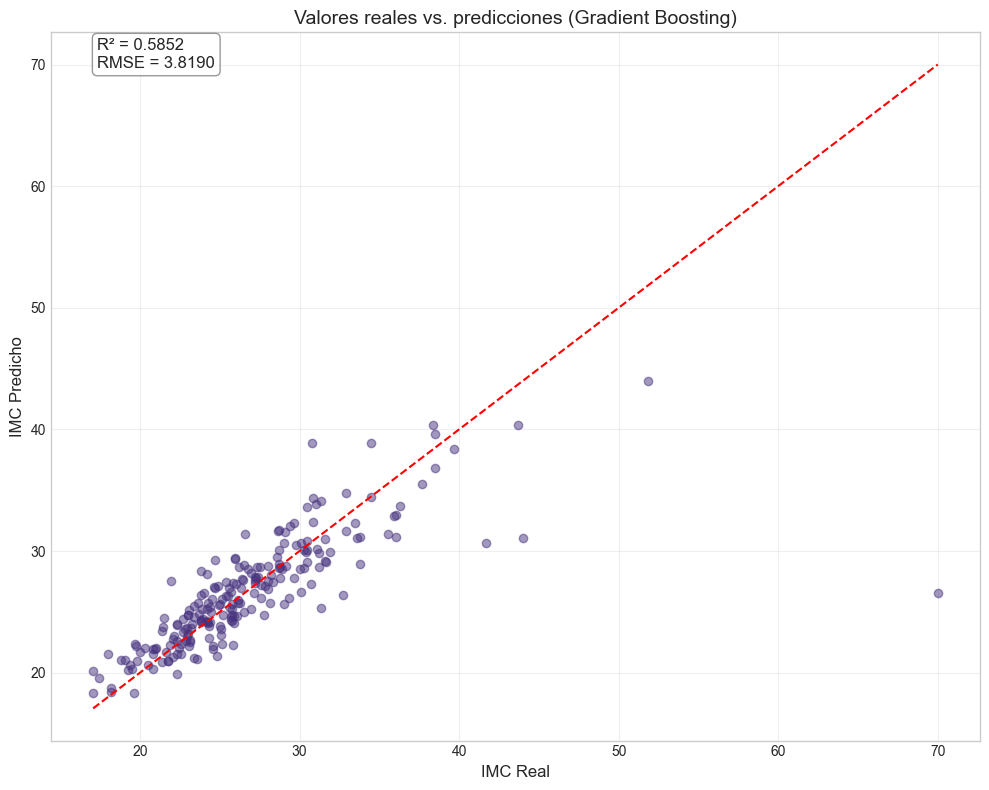

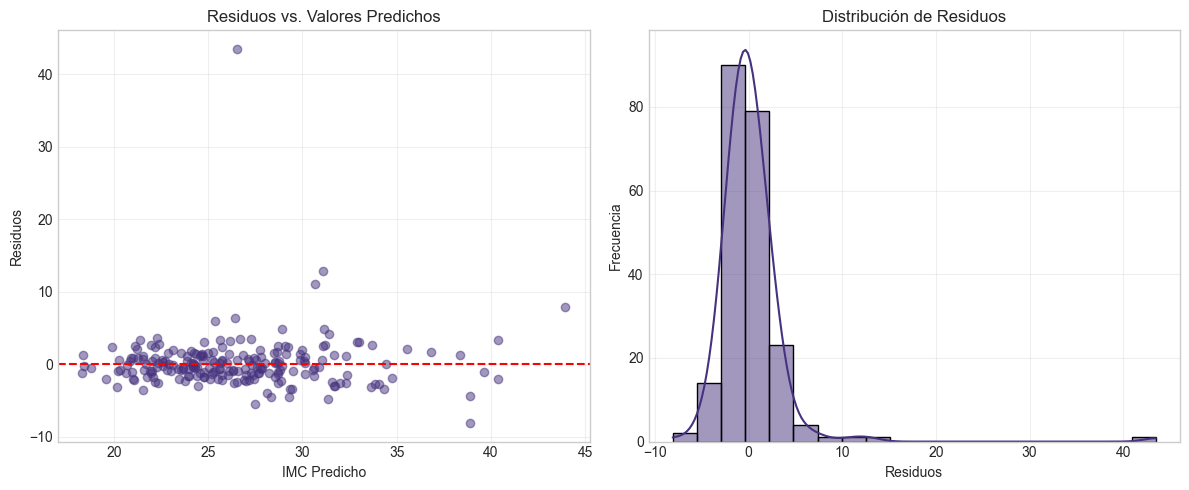

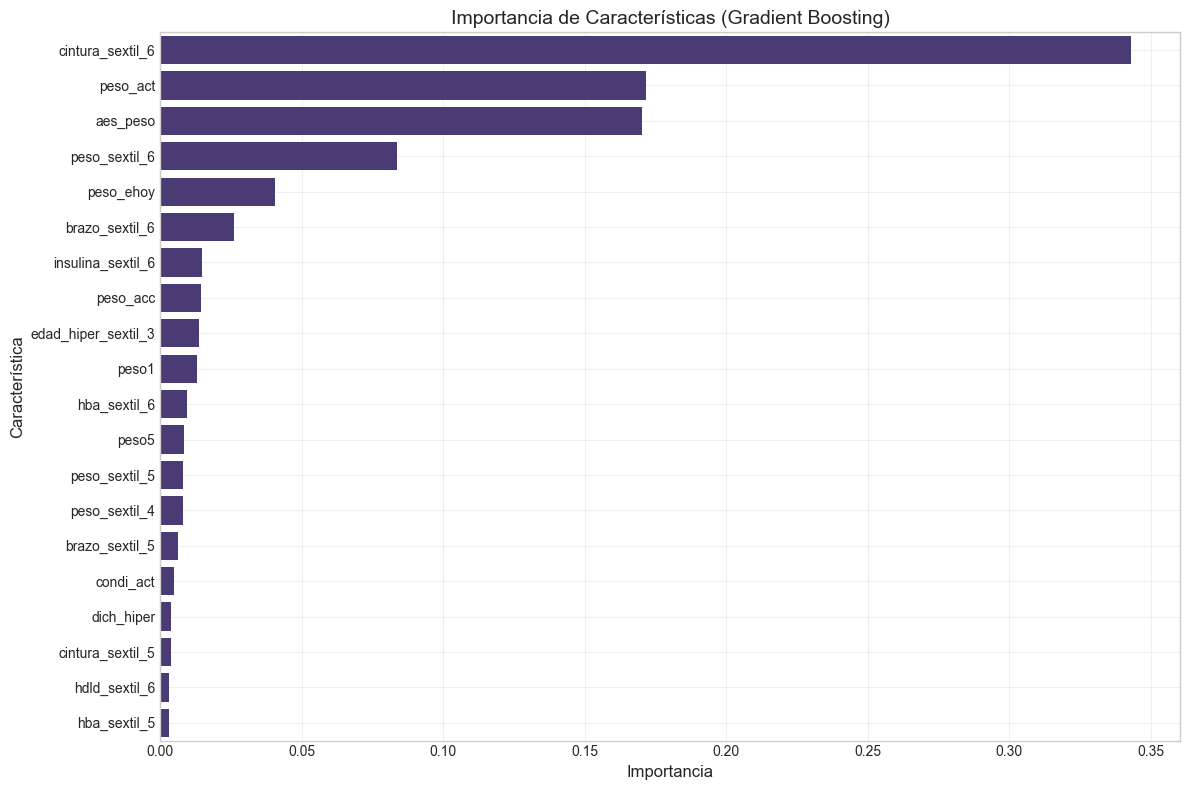


Comparación entre regresión multivariante y regresión basada en score:
R² multivariante (Gradient Boosting): 0.5852
R² basado en score (Regresión basada en score): 0.4588
RMSE multivariante: 3.8190
RMSE basado en score: 4.3625

=== CONCLUSIONES COMPARATIVAS ===

1. Comparación de enfoques:
   - Enfoque multivariante: Utiliza directamente las características originales para predecir el IMC
   - Enfoque basado en score: Primero calcula un score (log-odds) usando Naive Bayes y luego usa ese score para predecir el IMC

2. Ventajas del enfoque multivariante:
   - Mayor interpretabilidad: Permite entender el impacto directo de cada característica en el IMC
   - Flexibilidad: Puede capturar relaciones lineales y no lineales según el modelo utilizado
   - Eficiencia: No requiere el paso intermedio de cálculo del score

3. Ventajas del enfoque basado en score:
   - Compresión de información: El score condensa múltiples factores en un único valor
   - Posible robustez: Puede ser menos susceptib

In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import math

# Seleccionamos las mismas variables que se usaron en el análisis de score regression
# Tomamos las 17 características con mayor valor absoluto de epsilon (igual que en análisis anterior)
top_features = results_df.sort_values(by='Epsilon', key=abs, ascending=False)

# Eliminar duplicados (tomamos solo la primera aparición de cada característica)
selected_features = []
seen_features = set()

for _, row in top_features.iterrows():
    feature = row['Feature']
    if feature not in seen_features:
        seen_features.add(feature)
        selected_features.append(row)
        if len(selected_features) >= 23:  # Tomar las 23 mejores características
            break

selected_features_df = pd.DataFrame(selected_features)
selected_feature_names = selected_features_df['Feature'].tolist()

print(f"Variables seleccionadas para regresión multivariante: {len(selected_feature_names)}")
print("\nCaracterísticas seleccionadas:")
for i, feature in enumerate(selected_feature_names, 1):
    epsilon = selected_features_df[selected_features_df['Feature'] == feature]['Epsilon'].values[0]
    print(f"{i}. {feature} (Epsilon: {epsilon:.2f})")

# Preparar datos para regresión multivariante
def prepare_multivar_regression_data(df, feature_names, target_col='imc_calculado'):
    """Prepara los datos para regresión multivariante, manejando variables categóricas y valores nulos."""
    # Filtrar solo las variables relevantes
    X_data = df[feature_names].copy()
    y_data = df[target_col].copy()
    
    # Identificar variables categóricas (aquellas con '_sextil' en el nombre)
    categorical_features = [f for f in feature_names if '_sextil' in f]
    numeric_features = [f for f in feature_names if f not in categorical_features]
    
    # Imputar valores nulos para características numéricas con la media
    for feature in numeric_features:
        X_data[feature].fillna(X_data[feature].mean(), inplace=True)
    
    # Imputar valores nulos para características categóricas con la moda
    for feature in categorical_features:
        X_data[feature].fillna(X_data[feature].mode()[0], inplace=True)
        # Convertir a int ya que los sextiles son categorías numéricas (1-6)
        X_data[feature] = X_data[feature].astype(int)
    
    # Identificar si hay variables con umbrales (identificadas en el dataframe de características seleccionadas)
    threshold_features = []
    for _, row in selected_features_df.iterrows():
        if row['Is_Threshold'] and row['Feature'] in feature_names:
            threshold_features.append({
                'feature': row['Feature'],
                'threshold': row['Value']
            })
    
    # Crear variables binarias para umbrales
    for threshold_info in threshold_features:
        feature = threshold_info['feature']
        threshold = threshold_info['threshold']
        binary_feature = f"{feature}_geq_{threshold}"
        X_data[binary_feature] = (X_data[feature] >= threshold).astype(int)
        # Añadir a la lista de características (reemplazando la original)
        numeric_features.remove(feature)
        numeric_features.append(binary_feature)
    
    return X_data, y_data, categorical_features, numeric_features

# Preparar los datos
X_multivar, y_multivar, categorical_features, numeric_features = prepare_multivar_regression_data(df_clean, selected_feature_names)

print(f"\nCaracterísticas numéricas: {len(numeric_features)}")
print(f"Características categóricas: {len(categorical_features)}")

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_multivar, y_multivar, test_size=0.2, random_state=42)
print(f"\nConjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

# Crear un preprocesador con transformaciones adecuadas para cada tipo de variable
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# Definir varios modelos de regresión para comparar
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Evaluación comparativa de modelos
results_multivar = []

for name, model in models.items():
    # Crear pipeline con preprocesamiento y modelo
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    
    # Entrenar modelo
    pipeline.fit(X_train, y_train)
    
    # Predecir
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
    # Calcular métricas
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_rmse = math.sqrt(train_mse)
    test_rmse = math.sqrt(test_mse)
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    # Validación cruzada para R²
    cv_scores = cross_val_score(pipeline, X_multivar, y_multivar, cv=5, scoring='r2')
    cv_r2 = cv_scores.mean()
    
    # Guardar resultados
    results_multivar.append({
        'Modelo': name,
        'MSE Train': train_mse,
        'MSE Test': test_mse,
        'RMSE Train': train_rmse,
        'RMSE Test': test_rmse,
        'MAE Train': train_mae,
        'MAE Test': test_mae,
        'R² Train': train_r2,
        'R² Test': test_r2,
        'R² CV': cv_r2
    })

# Crear DataFrame con resultados
results_df_multivar = pd.DataFrame(results_multivar)

# Mostrar resultados
print("\nResultados de modelos de regresión multivariante:")
display(results_df_multivar.set_index('Modelo').style.format('{:.4f}'))

# Identificar el mejor modelo basado en R² de validación cruzada
best_model_idx = results_df_multivar['R² CV'].idxmax()
best_model_name = results_df_multivar.loc[best_model_idx, 'Modelo']
best_model = models[best_model_name]
best_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', best_model)])
best_pipeline.fit(X_train, y_train)

print(f"\nMejor modelo multivariante: {best_model_name}")
print(f"R² en test: {results_df_multivar.loc[best_model_idx, 'R² Test']:.4f}")
print(f"RMSE en test: {results_df_multivar.loc[best_model_idx, 'RMSE Test']:.4f}")

# Visualizar predicciones del mejor modelo
y_pred_best = best_pipeline.predict(X_test)

plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Valores reales vs. predicciones ({best_model_name})', fontsize=14)
plt.xlabel('IMC Real', fontsize=12)
plt.ylabel('IMC Predicho', fontsize=12)
plt.grid(True, alpha=0.3)
plt.annotate(f"R² = {results_df_multivar.loc[best_model_idx, 'R² Test']:.4f}\nRMSE = {results_df_multivar.loc[best_model_idx, 'RMSE Test']:.4f}", 
             xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
plt.tight_layout()
plt.show()

# Comparar residuos del mejor modelo
residuals = y_test - y_pred_best

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_pred_best, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuos vs. Valores Predichos', fontsize=12)
plt.xlabel('IMC Predicho', fontsize=10)
plt.ylabel('Residuos', fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, bins=20)
plt.title('Distribución de Residuos', fontsize=12)
plt.xlabel('Residuos', fontsize=10)
plt.ylabel('Frecuencia', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Análisis de importancia de características para modelos basados en árboles
if 'Random Forest' in best_model_name or 'Gradient Boosting' in best_model_name:
    # Obtener nombres de características después del preprocesamiento
    # Primero aplicamos solo el preprocesador para obtener los nombres de las características transformadas
    preprocessor.fit(X_train)
    
    # Obtener nombres de características numéricas (mantienen el mismo nombre después de la normalización)
    numeric_feature_names = numeric_features
    
    # Obtener nombres de características categóricas después de one-hot encoding
    encoder = preprocessor.named_transformers_['cat']
    categorical_feature_names = []
    for i, cat in enumerate(categorical_features):
        categories = encoder.categories_[i][1:]  # Excluimos la primera categoría (drop='first')
        for category in categories:
            categorical_feature_names.append(f"{cat}_{category}")
    
    # Combinar todas las características transformadas
    transformed_feature_names = numeric_feature_names + categorical_feature_names
    
    # Obtener importancia de características del modelo
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
        
        # Crear DataFrame con importancias
        importance_df = pd.DataFrame({
            'Feature': transformed_feature_names,
            'Importance': importances
        })
        
        # Ordenar por importancia
        importance_df = importance_df.sort_values('Importance', ascending=False).head(20)
        
        # Visualizar importancia de características
        plt.figure(figsize=(12, 8))
        sns.barplot(x='Importance', y='Feature', data=importance_df)
        plt.title(f'Importancia de Características ({best_model_name})', fontsize=14)
        plt.xlabel('Importancia', fontsize=12)
        plt.ylabel('Característica', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# Comparar con el modelo de regresión basado en score
# Obtener el mejor modelo de regresión basado en score del análisis anterior
score_model_result = results_df[results_df['Modelo'] == best_model_name].iloc[0] if 'Modelo' in results_df.columns else None

if score_model_result is not None:
    print("\nComparación entre regresión multivariante y regresión basada en score:")
    print(f"Modelo: {best_model_name}")
    print(f"R² multivariante: {results_df_multivar.loc[best_model_idx, 'R² Test']:.4f}")
    print(f"R² basado en score: {score_model_result['R² Test']:.4f}")
    print(f"RMSE multivariante: {results_df_multivar.loc[best_model_idx, 'RMSE Test']:.4f}")
    print(f"RMSE basado en score: {math.sqrt(score_model_result['MSE Test']):.4f}")
else:
    # Comparar con la mejor regresión del análisis anterior (basada en R² Test)
    best_score_model_idx = results_regression_df['R² Test'].idxmax() if 'R² Test' in results_regression_df.columns else None
    
    if best_score_model_idx is not None:
        score_model_r2 = results_regression_df.loc[best_score_model_idx, 'R² Test']
        score_model_mse = results_regression_df.loc[best_score_model_idx, 'MSE Test']
        score_model_name = results_regression_df.loc[best_score_model_idx, 'Modelo'] if 'Modelo' in results_df.columns else "Regresión basada en score"
        
        print("\nComparación entre regresión multivariante y regresión basada en score:")
        print(f"R² multivariante ({best_model_name}): {results_df_multivar.loc[best_model_idx, 'R² Test']:.4f}")
        print(f"R² basado en score ({score_model_name}): {score_model_r2:.4f}")
        print(f"RMSE multivariante: {results_df_multivar.loc[best_model_idx, 'RMSE Test']:.4f}")
        print(f"RMSE basado en score: {math.sqrt(score_model_mse):.4f}")
    else:
        print("\nNo se encontraron resultados del análisis de regresión basado en score para comparar.")

# Conclusiones
print("\n=== CONCLUSIONES COMPARATIVAS ===\n")
print("1. Comparación de enfoques:")
print("   - Enfoque multivariante: Utiliza directamente las características originales para predecir el IMC")
print("   - Enfoque basado en score: Primero calcula un score (log-odds) usando Naive Bayes y luego usa ese score para predecir el IMC")

print("\n2. Ventajas del enfoque multivariante:")
print("   - Mayor interpretabilidad: Permite entender el impacto directo de cada característica en el IMC")
print("   - Flexibilidad: Puede capturar relaciones lineales y no lineales según el modelo utilizado")
print("   - Eficiencia: No requiere el paso intermedio de cálculo del score")

print("\n3. Ventajas del enfoque basado en score:")
print("   - Compresión de información: El score condensa múltiples factores en un único valor")
print("   - Posible robustez: Puede ser menos susceptible a outliers en características individuales")
print("   - Conexión directa con el modelo clasificatorio: Aprovecha el conocimiento del modelo Naive Bayes")

print("\n4. Desempeño:")
better_approach = "multivariante" if results_df_multivar.loc[best_model_idx, 'R² Test'] > score_model_r2 else "basado en score"
print(f"   - El enfoque {better_approach} muestra un mejor desempeño en términos de R² y RMSE")
print(f"   - La diferencia de rendimiento sugiere que el enfoque {better_approach} captura mejor la relación entre las variables y el IMC")

print("\n5. Conclusión general:")
if better_approach == "multivariante":
    print("   El modelo multivariante directo es más efectivo para predecir el IMC que usar el score como variable intermediaria.")
    print("   Esto sugiere que la transformación a score puede perder información relevante para la predicción.")
else:
    print("   El modelo basado en score es más efectivo, lo que sugiere que el score captura eficientemente")
    print("   la información relevante de las variables originales para predecir el IMC.")